# Student Submission

Fill in your IDs before submitting.

| | ID |
|---|----|
| Tal Hibner | 026548446 |
| Gilad Ticher | 318770039 |

# Deep RL in MiniGrid — Final Project (2026 B)

## Overview
Train **deep RL agents from scratch** — one from each of the value-based, policy-based, and actor-critic families —
on two image-based MiniGrid environments. The agent sees only the
**raw rendered RGB image** of the grid and must learn to act from pixels. No external RL libraries for the core
algorithms — use PyTorch / TensorFlow only for the neural networks.

**Read the accompanying PDF first.** This notebook defines the environment APIs and the editable points; the PDF
defines what to deliver. The **report** is the primary deliverable and must be fully
self-contained: every graph, table, number, and discussion point lives there.

## Learning objectives
- Implement one algorithm from each family — **value-based** (e.g. DQN), **policy-based** (e.g. REINFORCE), and
  **actor-critic** (e.g. A2C) — from scratch, and compare them.
- Design observation preprocessing and reward shaping as composable wrappers.
- Choose hyperparameters and an exploration strategy deliberately, and justify them.
- Evaluate with clear metrics and plots, and communicate results in a concise report.

## The two environments
| Environment | Description | Win condition |
|---|---|---|
| **`SimpleRoomEnv`** | Empty 10×10 room (sanity check) | Step onto the green goal |
| **`ComplexEnv`** | Two rooms: key → locked door → water → lava → goal | Ferry water to extinguish the lava ring, then reach the goal |

Both expose the standard MiniGrid `Discrete(7)` action space and a **raw full-grid RGB observation** (`uint8`,
`H·tile × W·tile × 3`).

## What you build — and where
- **Observation preprocessing** — a `gym.ObservationWrapper` (e.g. grayscale, resize, channel-first, frame-stack).
- **Reward shaping** — a `gym.Wrapper` / `gym.RewardWrapper` that adds shaping on top of the sparse reward.
- **The agents** — for each family, the network(s), update rule, training loop, and evaluation (e.g. replay buffer
  + target net for DQN; a policy network for REINFORCE; actor + critic for A2C).

Do all of this **outside** the environments. Provided **example wrappers** and an **environment explorer** come first;
write your own wrappers and agents below the **"Your Code Below"** divider near the end. **The environment classes are
fixed**; see the full edit policy in the *Environments* section below.

## Reproducibility & integrity
- Seed Python, NumPy, and your DL framework, and document every hyperparameter.
- Submit (1) this notebook with all training/inference outputs and (2) the report PDF — a reader should understand your
  full methodology and results from the report alone.
- Discuss ideas freely, but code and write-up must be your own; cite any external resources (blog posts, papers, code).

# Setup

## Installs

In [1]:
# =========================================================
# Mount Google Drive for persistent artifacts.
# Safe to skip if not running on Colab.
# =========================================================
import os

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    # Not on Colab, or Drive not available — continue without mounting.
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# =========================================================
# Single source of truth for where artifacts are persisted.
# Priority: mounted Google Drive -> Colab session storage -> local folder.
# Nothing later in the notebook redefines STORAGE_ROOT, so a local rerun
# (no /content) writes next to the notebook instead of crashing.
# =========================================================
DRIVE_ROOT = "/content/drive/MyDrive/rl_final_project"
COLAB_ROOT = "/content/rl_final_project"
LOCAL_ROOT = os.path.join(os.path.abspath(os.getcwd()), "rl_final_project")

if os.path.isdir("/content/drive/MyDrive"):
    STORAGE_ROOT = DRIVE_ROOT      # Colab + Drive: survives session end
elif os.path.isdir("/content"):
    STORAGE_ROOT = COLAB_ROOT      # Colab, no Drive: wiped at session end
else:
    STORAGE_ROOT = LOCAL_ROOT      # local Jupyter / grader rerun

os.makedirs(STORAGE_ROOT, exist_ok=True)

# Everything that persists lives under STORAGE_ROOT.
ARTIFACTS = os.path.join(STORAGE_ROOT, "artifacts")
for sub in ("logs", "plots", "checkpoints"):
    os.makedirs(os.path.join(ARTIFACTS, sub), exist_ok=True)

print(f"STORAGE_ROOT: {STORAGE_ROOT}")
print(f"ARTIFACTS:    {ARTIFACTS}")

STORAGE_ROOT: /content/drive/MyDrive/rl_final_project
ARTIFACTS:    /content/drive/MyDrive/rl_final_project/artifacts


In [3]:
# Auto-install any missing dependencies. Idempotent: pip is only invoked for packages
# that aren't already importable, so re-running this cell is safe and cheap on both Colab
# and a local Python / venv kernel.
from __future__ import annotations

import importlib
import subprocess
import sys


def _pip_install(*packages: str) -> None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *packages])


def _ensure(import_name: str, pip_name: str | None = None) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        _pip_install(pip_name or import_name)


_ensure("gymnasium")
_ensure("minigrid")
_ensure("numpy")
_ensure("matplotlib")
_ensure("cv2", "opencv-python")
_ensure("torch")
_ensure("imageio")
_ensure("imageio_ffmpeg", "imageio[ffmpeg]")   # mp4 backend for rollout videos
_ensure("ipywidgets")                          # inline env explorer (buttons)
# pyvirtualdisplay is only useful on a headless Linux host (e.g. Colab).
if "google.colab" in sys.modules or sys.platform.startswith("linux"):
    _ensure("pyvirtualdisplay")

## Imports

In [4]:
from __future__ import annotations

# Standard library
import base64
import json
import os
import random
import sys
import time

# Numerics, plotting, video
import numpy as np
import matplotlib.pyplot as plt
import imageio

# Notebook display helpers
from IPython.display import HTML, Markdown, display

# Gymnasium + MiniGrid
import gymnasium as gym
from gymnasium import spaces
from minigrid.core.grid import Grid
from minigrid.core.mission import MissionSpace
from minigrid.core.world_object import Ball, Door, Goal, Key, Lava, Wall
from minigrid.minigrid_env import MiniGridEnv as BaseMiniGridEnv

# Image preprocessing + deep learning
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F

# On headless Linux (e.g. Colab) MiniGrid's renderer needs a virtual display.
if "google.colab" in sys.modules or sys.platform.startswith("linux"):
    try:
        import pyvirtualdisplay
        pyvirtualdisplay.Display(visible=0, size=(1400, 900)).start()
    except Exception as exc:  # pragma: no cover
        print(f"[display] virtual display not started: {exc}")

%matplotlib inline
plt.rcParams["figure.figsize"] = (6.0, 5.0)

## Display utils
Save a rollout to an `.mp4` and embed it inline. Auto-detects Colab vs local Jupyter — no configuration needed.

In [5]:
# Drive is mounted (if available) in the Installs cell above, and STORAGE_ROOT is
# defined there — this cell only adds the display/video helpers that build on it.


def video_path(name: str, folder_name: str = "videos") -> str:
    """Return a writable absolute path for a video file under ``folder_name/``.

    Videos are placed under STORAGE_ROOT so they survive Colab session end when
    STORAGE_ROOT points to Google Drive, and land in a local folder otherwise.
    """
    folder = os.path.join(STORAGE_ROOT, folder_name)
    os.makedirs(folder, exist_ok=True)
    return os.path.join(folder, name)


print("STORAGE_ROOT:", STORAGE_ROOT)
print("Drive mounted?", os.path.isdir("/content/drive/MyDrive"))
print("ARTIFACTS exists?", os.path.isdir(ARTIFACTS))
print("Sample video path:", video_path("sanity_test.mp4"))


def embed_mp4(filename: str):
    """Embed an mp4 file inline. Works in Colab and local Jupyter alike."""
    with open(filename, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    tag = (
        '<video width="640" height="480" controls>'
        f'<source src="data:video/mp4;base64,{b64}" type="video/mp4">'
        "Your browser does not support the video tag."
        "</video>"
    )
    return HTML(tag)


def random_rollout_video(env, filename, max_steps=100, fps=10, seed=None):
    """Run one random-action episode and save it as mp4. Returns (steps, total_reward)."""
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    env.reset(seed=seed)
    total_reward, steps = 0.0, 0
    with imageio.get_writer(filename, fps=fps) as video:
        video.append_data(env.render())
        for steps in range(1, max_steps + 1):
            action = random.randint(0, env.action_space.n - 1)
            _, reward, terminated, truncated, _ = env.step(action)
            total_reward += float(reward)
            video.append_data(env.render())
            if terminated or truncated:
                break
    return steps, total_reward

STORAGE_ROOT: /content/drive/MyDrive/rl_final_project
Drive mounted? True
ARTIFACTS exists? True
Sample video path: /content/drive/MyDrive/rl_final_project/videos/sanity_test.mp4


# Environments — definition & construction

Two MiniGrid environments are defined below. **Both are fixed** — only `max_steps` may be overridden at
construction. Everything else (preprocessing, reward shaping, action restriction) goes in **wrappers**.

**Action IDs** (standard MiniGrid `Discrete(7)`):

| ID | Name | Effect |
|---|---|---|
| 0 | `left` | turn 90° left (no move) |
| 1 | `right` | turn 90° right (no move) |
| 2 | `forward` | move one cell forward |
| 3 | `pickup` | pick up the object directly in front |
| 4 | `drop` | drop the carried object into the cell in front |
| 5 | `toggle` | activate the object in front (open a door with the matching key; **extinguish a lava tile while carrying water**) |
| 6 | `done` | no-op here |

**Coordinates.** Cells are `(x, y)` with `x` growing **rightward** and `y` **downward**. Facing `agent_dir`:
`0`=right, `1`=down, `2`=left, `3`=up.

## Environment 1 — SimpleRoomEnv (sanity)

**Task.** Navigate from a random start to the green goal in an empty room.

| Property | Value |
|---|---|
| Grid | 10×10 (8×8 walkable) |
| Agent start | random interior cell, random facing |
| Goal | a random corner |
| Actions | `Discrete(7)` (only turn/forward are needed) |
| Reward | sparse: `+1` on the goal, `0` otherwise |
| Observation | raw full-grid RGB `uint8` |

In [6]:
# =============================================================================
# ENVIRONMENT 1: SimpleRoomEnv (empty room, sanity check)   --- FIXED, DO NOT EDIT
# =============================================================================
class SimpleRoomEnv(BaseMiniGridEnv):
    """Empty room: walk onto the green goal. Pass/fail sanity-check env.

    Same observation contract as ``ComplexEnv`` (raw full-grid RGB, uint8 HWC) and
    the standard MiniGrid ``Discrete(7)`` action space. Sparse reward ``+1`` on the
    goal. FIXED — wrap it to add preprocessing; you may only override ``max_steps``.
    """

    def __init__(self, width=10, height=10, max_steps=100, tile_size=32,
                 render_mode="rgb_array", **kwargs):
        assert width >= 4 and height >= 4
        mission_space = MissionSpace(mission_func=self._gen_mission)
        super().__init__(
            mission_space=mission_space, width=width, height=height,
            see_through_walls=True, max_steps=max_steps, render_mode=render_mode,
            highlight=False, **kwargs,
        )
        # --- spaces: Discrete(7) actions, raw full-grid RGB observation ---
        self.action_space = spaces.Discrete(7)
        self._obs_tile_size = int(tile_size)
        self.observation_space = spaces.Box(
            low=0, high=255,
            shape=(height * self._obs_tile_size, width * self._obs_tile_size, 3),
            dtype=np.uint8,
        )
        # --- per-episode layout: set by _gen_grid() ---
        self.goal_pos = None

    @staticmethod
    def _gen_mission():
        return "reach the green goal"

    def _gen_grid(self, width, height):
        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)

        # goal in a random corner
        goal_x = int(self.np_random.choice([1, width - 2]))
        goal_y = int(self.np_random.choice([1, height - 2]))
        self.goal_pos = (goal_x, goal_y)
        self.put_obj(Goal(), goal_x, goal_y)

        # agent starts on any non-goal cell, facing a random direction
        while True:
            ax = int(self.np_random.integers(1, width - 1))
            ay = int(self.np_random.integers(1, height - 1))
            if (ax, ay) != self.goal_pos:
                break
        self.agent_pos = (ax, ay)
        self.agent_dir = int(self.np_random.integers(0, 4))
        self.mission = self._gen_mission()

    def gen_obs(self):
        return self.get_frame(highlight=False, tile_size=self._obs_tile_size)

    def is_on_goal(self) -> bool:
        """True iff the agent is standing on the goal cell right now (a win)."""
        return tuple(self.agent_pos) == tuple(self.goal_pos)

    def step(self, action):
        obs, _, _, truncated, info = super().step(action)
        terminated = self.is_on_goal()
        reward = 1.0 if terminated else 0.0
        return obs, reward, terminated, truncated, info

## Environment 2 — ComplexEnv (the task)

**Task — five stages: key → door → water → lava → goal.**
1. Pick up the **key** in the left room.
2. **Toggle** the locked partition **door** open (drop the key first if needed — only one object can be carried).
3. Pick up a **water ball** in the right room.
4. Face a **lava** tile and **toggle** to extinguish it; the tile clears and the ball is consumed. One ball per
   tile, so water must be **ferried repeatedly**.
5. Step onto the **goal** in the lava-ringed corner. Stepping on un-extinguished lava is **lethal**.

Objects may spawn in your path — the agent must learn to move them out of the way.

| Property | Value |
|---|---|
| Grid | 10×10, two rooms split by a partition wall (`partition_col=3`) |
| Agent start | `(1, 1)`, random facing |
| Key / Door | one key at a random left-room cell; one locked door at a random partition row |
| Water balls | a contiguous cluster in the top or bottom left of the right room (`water_corner`) |
| Lava | rings the goal corner; lethal until extinguished |
| Goal | top or bottom right-room corner (`goal_corner`) |
| Actions | `Discrete(7)` (turn / forward / pickup / drop / toggle all matter) |
| Reward | sparse: `+1` on the goal, `0` otherwise; lava death ends the episode with `0` |
| Observation | raw full-grid RGB `uint8` |

**Helper getters.** The observation is raw RGB, so there is no tabular state to read. `ComplexEnv` exposes
`is_*` / `prev_*` getters (current vs. start-of-step) plus position getters — see the class docstring (next
code cell) for the full list. They exist for wrappers (event detection) and analysis; reward may **not** use
geometry or distance.

**`info` dict** (from `step` / `reset`): `is_success`, `died_on_lava`, `extinguished_lava_count`, `n_lava`,
`extinguished_this_step`.

In [7]:
# =============================================================================
# ENVIRONMENT 2: ComplexEnv (key -> door -> water -> lava -> goal)  --- FIXED, DO NOT EDIT
# =============================================================================
class ComplexEnv(BaseMiniGridEnv):
    """Key -> door -> water -> lava -> goal (image-based, sparse reward).

    The left room holds a single locked-door key; the right room holds the goal in
    a top or bottom right corner ringed by lethal ``Lava`` (the ring mirrors with
    the corner), plus several ``Ball`` "water" objects.
    To win: pick up the key, toggle the locked door open, drop the key (only one
    object can be carried), pick up a water ball, ``toggle`` it while facing a lava
    tile (extinguishes that tile and consumes the ball) -- ferrying water until the
    path is clear -- then step onto the goal. Stepping on un-extinguished lava is lethal.

    Observation: raw full-grid RGB ``(H*tile, W*tile, 3)`` uint8. Reward: sparse
    ``+1`` on the goal, ``0`` otherwise. FIXED -- wrap it to add preprocessing / reward
    shaping; you may only override ``max_steps``.


    Helper getters -- for event-based reward shaping and for evaluation / EDA. (The
    observation is the raw RGB image, so there is no tabular "state" to read here; and
    reward may NOT depend on geometry / distance, so the position getters are for
    analysis, not for shaping.)
      curr (now)            : is_carrying_key / is_carrying_water / is_door_open /
                              is_door_locked / is_on_lava / is_on_goal / is_in_right_room /
                              extinguished_lava_count
      prev (start of step)  : prev_carrying_key / prev_carrying_water / prev_door_open /
                              prev_door_locked / prev_in_right_room / prev_extinguished_lava_count
      positions (eval & EDA): key_position / water_positions / lava_positions
    Detect an event as *curr and not prev*, e.g.
    just picked up water == ``is_carrying_water() and not prev_carrying_water()``.
    Latch a milestone ("ever opened the door") yourself in your wrapper if you want one.
    """

    def __init__(self, max_steps=400, width=10, height=10, tile_size=32,
                 render_mode="rgb_array", partition_col=3,
                 agent_start_pos=(1, 1), goal_corner="random",
                 n_water=3, water_corner="random",
                 key_door_color="purple", water_color="blue", **kwargs):
        assert width >= 8 and height >= 5
        assert 2 <= partition_col < width - 2   # leave >=1 right-room column for the goal
        assert goal_corner in ("top", "bottom", "random")
        assert water_corner in ("top", "bottom", "random")
        mission_space = MissionSpace(mission_func=self._gen_mission)
        super().__init__(
            mission_space=mission_space, width=width, height=height,
            see_through_walls=True, max_steps=max_steps, render_mode=render_mode,
            highlight=False, **kwargs,
        )
        # --- spaces: Discrete(7) actions, raw full-grid RGB observation ----------------
        self.action_space = spaces.Discrete(7)
        self._obs_tile_size = int(tile_size)
        self.observation_space = spaces.Box(
            low=0, high=255,
            shape=(height * self._obs_tile_size, width * self._obs_tile_size, 3),
            dtype=np.uint8,
        )

        # --- task configuration: fixed for the env's lifetime (from constructor args) --
        self.partition_col = partition_col
        self.key_color = key_door_color
        self.door_color = key_door_color
        self.water_color = water_color
        self.n_water = int(n_water)
        self.goal_corner = goal_corner           # "top" / "bottom" / "random" (resolved per episode)
        self.water_corner = water_corner         # "top" / "bottom" / "random" (resolved per episode)
        # agent start: None -> randomized per episode; otherwise reused each episode.
        self.fixed_agent_start_pos = (None if agent_start_pos is None
                                      else tuple(int(v) for v in agent_start_pos))

        # --- per-episode layout: (re)filled by _gen_grid() on every reset ---------------
        self.door_pos = None
        self.goal_pos = None
        self.lava_ring = ()                 # ring around the goal corner (mirrors it)
        self._door = None

        # --- episode progress: count of lava tiles extinguished so far this episode -----
        self._extinguished_lava_count = 0

        # --- previous-step snapshot: each value as of the START of the current step ------
        self._prev_carrying_key = False
        self._prev_carrying_water = False
        self._prev_door_open = False
        self._prev_door_locked = False
        self._prev_in_right_room = False
        self._prev_extinguished_lava_count = 0

    @staticmethod
    def _gen_mission():
        return "get the key, open the door, extinguish the lava with water, then reach the goal"

    def _resolve_corner(self, mode):
        """Resolve a 'top'/'bottom'/'random' corner mode to a concrete 'top'/'bottom'
        for this episode ('random' is re-rolled every episode via the env RNG)."""
        if mode == "random":
            return "top" if int(self.np_random.integers(0, 2)) == 0 else "bottom"
        return mode

    def _gen_grid(self, width, height):
        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)

        # partition wall splitting left (key) from right (goal + lava + water)
        for y in range(height):
            self.grid.set(self.partition_col, y, Wall())

        # locked door at a random partition row
        door_y = int(self.np_random.integers(1, height - 1))
        self.door_pos = (self.partition_col, door_y)
        self._door = Door(self.door_color, is_locked=True)
        self.grid.set(self.partition_col, door_y, self._door)

        # agent start: fixed if provided, else a random left-room cell, facing random
        if self.fixed_agent_start_pos is not None:
            self.agent_pos = self.fixed_agent_start_pos
        else:
            ax = int(self.np_random.integers(1, self.partition_col))
            ay = int(self.np_random.integers(1, height - 1))
            self.agent_pos = (ax, ay)
        self.agent_dir = int(self.np_random.integers(0, 4))

        # the single key on a left-room cell (never UNDER the agent). It MAY land on the
        # door-approach cell -- no clearance is reserved, so it can block the way.
        blocked = {tuple(self.agent_pos)}
        left_cells = [(x, y) for x in range(1, self.partition_col)
                      for y in range(1, height - 1) if (x, y) not in blocked]
        kx, ky = left_cells[int(self.np_random.integers(len(left_cells)))]
        self.grid.set(kx, ky, Key(self.key_color))

        # goal in a right-room corner (top or bottom); the lava ring mirrors with it so
        # it always cups the goal corner. The goal stays in the far-right column (x=width-2).
        goal_corner = self._resolve_corner(self.goal_corner)
        gx = width - 2
        if goal_corner == "bottom":
            self.goal_pos = (gx, height - 2)
            self.lava_ring = ((gx - 1, height - 2), (gx, height - 3), (gx - 1, height - 3))
        else:  # top: vertical mirror of the bottom ring
            self.goal_pos = (gx, 1)
            self.lava_ring = ((gx - 1, 1), (gx, 2), (gx - 1, 2))
        self.put_obj(Goal(), self.goal_pos[0], self.goal_pos[1])

        # lethal lava ringing the goal corner
        for lx, ly in self.lava_ring:
            self.grid.set(lx, ly, Lava())

        # water balls: a contiguous cluster on the top or bottom row (water_corner), starting
        # at the left edge of the right room. Cells overlapping the goal/lava are skipped, so a
        # large n_water relative to the room width may place fewer than n_water balls.
        water_corner = self._resolve_corner(self.water_corner)
        wy = 1 if water_corner == "top" else height - 2
        reserved = {tuple(self.goal_pos)} | set(self.lava_ring)
        placements = []
        for i in range(self.n_water):
            wx = self.partition_col + 1 + i
            if wx > width - 2:
                break
            if (wx, wy) not in reserved:
                placements.append((wx, wy))
        for wx, wy in placements:
            self.grid.set(wx, wy, Ball(self.water_color))

        # reset the per-episode extinguished-lava count (the prev snapshot is taken in
        # reset, once the base class has finished setting up self.carrying etc.)
        self._extinguished_lava_count = 0
        self.mission = self._gen_mission()

    def reset(self, *, seed=None, options=None):
        obs, info = super().reset(seed=seed, options=options)   # calls _gen_grid()
        self._snapshot_prev()                                   # prev == the fresh reset state
        info = dict(info)
        info.update(self._info_snapshot(terminated=False, extinguished_now=0))
        return obs, info

    def gen_obs(self):
        return self.get_frame(highlight=False, tile_size=self._obs_tile_size)

    # ============================ curr: instantaneous state (true only RIGHT NOW) =======
    def is_carrying_key(self) -> bool:
        """True iff a key is in hand right now."""
        return isinstance(self.carrying, Key)

    def is_carrying_water(self) -> bool:
        """True iff a water ball is in hand right now."""
        return isinstance(self.carrying, Ball)

    def is_door_open(self) -> bool:
        """True iff the door is open right now."""
        return bool(self._door is not None and self._door.is_open)

    def is_door_locked(self) -> bool:
        """True iff the door is locked right now (opening it unlocks it for good)."""
        return bool(self._door is not None and self._door.is_locked)

    def is_on_lava(self) -> bool:
        """True iff the agent is standing on a lava tile right now (a lethal lava death)."""
        return isinstance(self.grid.get(int(self.agent_pos[0]), int(self.agent_pos[1])), Lava)

    def is_on_goal(self) -> bool:
        """True iff the agent is standing on the goal cell right now (a win)."""
        return tuple(int(v) for v in self.agent_pos) == tuple(int(v) for v in self.goal_pos)

    def is_in_right_room(self) -> bool:
        """True iff the agent is past the partition wall (right room)."""
        return int(self.agent_pos[0]) > self.partition_col

    def extinguished_lava_count(self) -> int:
        """How many lava tiles have been extinguished so far this episode (only grows)."""
        return self._extinguished_lava_count

    # ============================ prev: same state, as of the START of this step ========
    def prev_carrying_key(self) -> bool: return self._prev_carrying_key
    def prev_carrying_water(self) -> bool: return self._prev_carrying_water
    def prev_door_open(self) -> bool: return self._prev_door_open
    def prev_door_locked(self) -> bool: return self._prev_door_locked
    def prev_in_right_room(self) -> bool: return self._prev_in_right_room
    def prev_extinguished_lava_count(self) -> int: return self._prev_extinguished_lava_count

    # ============================ positions / layout: for evaluation / EDA ==============
    def key_position(self) -> tuple[int, int] | None:
        """The single key's (x, y) while uncarried, else None (its color is ``key_color``)."""
        for x in range(self.width):
            for y in range(self.height):
                if isinstance(self.grid.get(x, y), Key):
                    return (x, y)
        return None

    def water_positions(self) -> list:
        """Remaining (uncarried) water balls on the grid."""
        return [(x, y) for x in range(self.width) for y in range(self.height)
                if isinstance(self.grid.get(x, y), Ball)]

    def lava_positions(self) -> list:
        """Lava tiles still present (not yet extinguished)."""
        return [(x, y) for x in range(self.width) for y in range(self.height)
                if isinstance(self.grid.get(x, y), Lava)]

    # ============================ internal bookkeeping ==================================
    def _snapshot_prev(self):
        """Capture the instantaneous state so the prev_* getters describe the value as
        of the START of the next step (i.e. the last step's value)."""
        self._prev_carrying_key = self.is_carrying_key()
        self._prev_carrying_water = self.is_carrying_water()
        self._prev_door_open = self.is_door_open()
        self._prev_door_locked = self.is_door_locked()
        self._prev_in_right_room = self.is_in_right_room()
        self._prev_extinguished_lava_count = self._extinguished_lava_count

    def _faced_lava_to_extinguish(self, action):
        """Return the (x, y) of the lava tile this action would extinguish -- i.e.
        ``toggle`` while carrying water and facing lava -- or None. (Base MiniGrid has
        no toggle behaviour for lava, so we resolve it ourselves.)"""
        if int(action) != int(self.actions.toggle) or not isinstance(self.carrying, Ball):
            return None
        fx, fy = (int(v) for v in self.front_pos)
        return (fx, fy) if isinstance(self.grid.get(fx, fy), Lava) else None

    def _resolve_goal(self, terminated):
        """Win (+1, terminate) on the goal cell; otherwise keep the base ``terminated``
        so a step onto un-extinguished lava stays lethal (death ends with no reward)."""
        if self.is_on_goal():
            return 1.0, True
        return 0.0, terminated

    def _info_snapshot(self, *, terminated, extinguished_now):
        """Ground-truth signals the env owns, surfaced through ``info`` for logging /
        evaluation."""
        return {
            "extinguished_lava_count": int(self._extinguished_lava_count),
            "n_lava": len(self.lava_ring),
            "extinguished_this_step": int(extinguished_now),
            "is_success": bool(self.is_on_goal()),
            "died_on_lava": bool(terminated and not self.is_on_goal()),
        }

    # ============================ step / reward =========================================
    def step(self, action):
        self._snapshot_prev()   # 'prev' = state as of the start of this step

        extinguish_target = self._faced_lava_to_extinguish(action)
        obs, _, terminated, truncated, info = super().step(action)

        extinguished_now = 0
        if extinguish_target is not None:
            ex, ey = extinguish_target
            self.grid.set(ex, ey, None)     # lava -> empty floor
            self.carrying = None            # the water ball is consumed
            self._extinguished_lava_count += 1
            extinguished_now = 1
            obs = self.gen_obs()            # refresh the image after the change

        reward, terminated = self._resolve_goal(terminated)

        info = dict(info)
        info.update(self._info_snapshot(terminated=terminated, extinguished_now=extinguished_now))
        return obs, reward, terminated, truncated, info

# Environment exploration

Get a feel for both envs before building anything — inspect the API and getters, the initial state, and a
random-action rollout. Nothing here is graded.

=== SimpleRoomEnv ===
obs shape / dtype : (320, 320, 3)  uint8
action space      : Discrete(7)
agent pos / dir   : (6, 4)  dir=1
goal_pos          : (1, 8)
info              : {}

=== ComplexEnv ===
obs shape / dtype : (320, 320, 3)  uint8
action space      : Discrete(7)
agent pos / dir   : (1, 1)  dir=3
door color / pos  : purple  (3, 1)
goal_pos          : (8, 1)
key   position    : (2, 3)  color=purple
water positions   : [(4, 1), (5, 1), (6, 1)]
lava  positions   : [(7, 1), (7, 2), (8, 2)]
-- curr state at reset --
carrying_key=False  carrying_water=False  in_right_room=False
door_open=False  door_locked=True  on_lava=False  on_goal=False
extinguished lava tiles : 0
info keys          : ['died_on_lava', 'extinguished_lava_count', 'extinguished_this_step', 'is_success', 'n_lava']


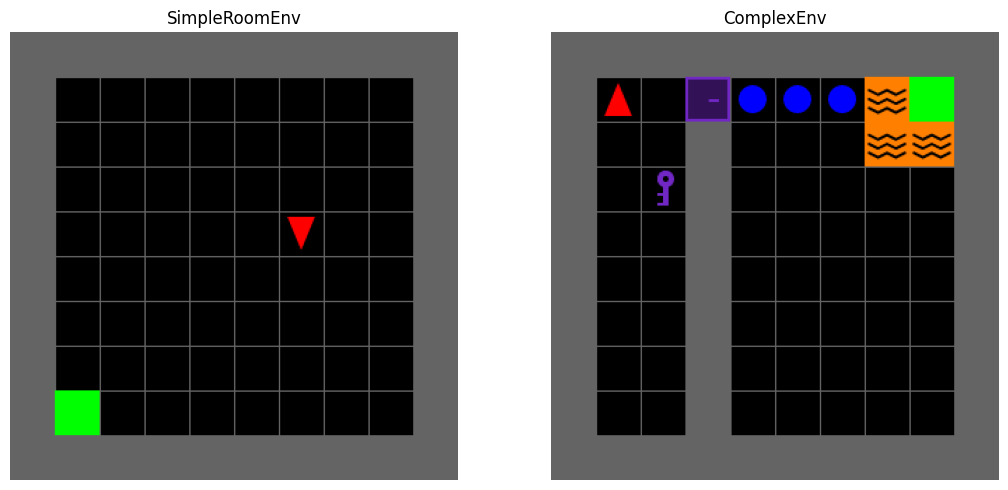

In [8]:
# Environment info + initial-state render for both envs, side by side.
simple_env = SimpleRoomEnv(max_steps=100)
s_obs, s_info = simple_env.reset(seed=42)

env = ComplexEnv(max_steps=400)
c_obs, c_info = env.reset(seed=42)

print("=== SimpleRoomEnv ===")
print(f"obs shape / dtype : {s_obs.shape}  {s_obs.dtype}")
print(f"action space      : {simple_env.action_space}")
print(f"agent pos / dir   : {simple_env.agent_pos}  dir={simple_env.agent_dir}")
print(f"goal_pos          : {simple_env.goal_pos}")
print(f"info              : {s_info}")

print("\n=== ComplexEnv ===")
print(f"obs shape / dtype : {c_obs.shape}  {c_obs.dtype}")
print(f"action space      : {env.action_space}")
print(f"agent pos / dir   : {env.agent_pos}  dir={env.agent_dir}")
print(f"door color / pos  : {env.door_color}  {env.door_pos}")
print(f"goal_pos          : {env.goal_pos}")
print(f"key   position    : {env.key_position()}  color={env.key_color}")
print(f"water positions   : {env.water_positions()}")
print(f"lava  positions   : {env.lava_positions()}")
print("-- curr state at reset --")
print(f"carrying_key={env.is_carrying_key()}  carrying_water={env.is_carrying_water()}  "
      f"in_right_room={env.is_in_right_room()}")
print(f"door_open={env.is_door_open()}  door_locked={env.is_door_locked()}  "
      f"on_lava={env.is_on_lava()}  on_goal={env.is_on_goal()}")
print(f"extinguished lava tiles : {env.extinguished_lava_count()}")
print(f"info keys          : {sorted(c_info)}")

# Initial-state render, both envs side by side.
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, e, title in ((axes[0], simple_env, "SimpleRoomEnv"), (axes[1], env, "ComplexEnv")):
    ax.imshow(e.render())
    ax.set_title(title)
    ax.axis("off")
fig.tight_layout()
plt.show()

In [9]:
# Random-action rollouts for both envs, shown side by side.
# (Random actions rarely make progress on either env -- that's expected.)
simple_video = video_path("SimpleRoomEnv_random.mp4")
s_steps, s_total = random_rollout_video(simple_env, simple_video, max_steps=100, seed=1)
print(f"SimpleRoomEnv random rollout: steps={s_steps}, total_reward={s_total:.2f}")

complex_video = video_path("ComplexEnv_random.mp4")
c_steps, c_total = random_rollout_video(env, complex_video, max_steps=100, seed=1)
print(f"ComplexEnv  random rollout: steps={c_steps}, total_reward={c_total:.2f}")


def _b64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()


display(HTML(f"""
<div style="display:flex; gap:16px; flex-wrap:wrap; align-items:flex-start;">
  <figure style="margin:0; text-align:center;">
    <figcaption><b>SimpleRoomEnv</b></figcaption>
    <video width="420" height="300" controls>
      <source src="data:video/mp4;base64,{_b64(simple_video)}" type="video/mp4">
    </video>
  </figure>
  <figure style="margin:0; text-align:center;">
    <figcaption><b>ComplexEnv</b></figcaption>
    <video width="420" height="300" controls>
      <source src="data:video/mp4;base64,{_b64(complex_video)}" type="video/mp4">
    </video>
  </figure>
</div>
"""))

SimpleRoomEnv random rollout: steps=100, total_reward=0.00
ComplexEnv  random rollout: steps=100, total_reward=0.00


# Preprocessing & reward shaping — via wrappers

Everything outside the fixed envs is done with Gymnasium wrappers:

- **Observation preprocessing** → `gym.ObservationWrapper` (override `observation(obs)`, update `observation_space`).
- **Reward shaping** → `gym.Wrapper` / `gym.RewardWrapper` (modify the reward in `step`, reading the env getters).
- **Action subset** → `gym.ActionWrapper` (restrict the 7 actions).

Wrappers compose, e.g. `GrayscaleWrapper(ShapingWrapper(ComplexEnv()))`; reach the base env via `env.unwrapped`.
The next cell provides three **example wrappers** as starting points.

## Example wrappers (starter code)

Three minimal examples to build on:
1. `GrayscaleWrapper` — RGB → single-channel grayscale.
2. `EventShapingWrapper` — scale the sparse goal reward and add a one-off event bonus via the env getters.
3. `ActionSubsetWrapper` — expose only a subset of the actions.

In [10]:
class GrayscaleWrapper(gym.ObservationWrapper):
    """Example: convert the raw RGB observation (H, W, 3) to grayscale (H, W, 1)."""

    def __init__(self, env):
        super().__init__(env)
        h, w, _ = env.observation_space.shape
        self.observation_space = spaces.Box(low=0, high=255, shape=(h, w, 1), dtype=np.uint8)

    def observation(self, obs):
        gray = cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)
        return gray[:, :, None]   # (H, W) -> (H, W, 1)

In [11]:
class EventShapingWrapper(gym.Wrapper):
    """Example: scale the sparse env reward and add tiny event-based shaping."""

    def __init__(self, env, base_reward_scale: float = 10.0,
                 door_bonus: float = 1.0, step_penalty: float = 0.01):
        super().__init__(env)
        self.base_reward_scale = float(base_reward_scale)
        self.door_bonus = float(door_bonus)
        self.step_penalty = float(step_penalty)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        core_env = self.env.unwrapped
        reward = self.base_reward_scale * float(reward) - self.step_penalty
        if core_env.is_door_open() and not core_env.prev_door_open():   # door just opened
            reward += self.door_bonus
        return obs, reward, terminated, truncated, info

In [12]:
class ActionSubsetWrapper(gym.ActionWrapper):
    """Example: expose only a chosen subset of the 7 MiniGrid actions as a smaller,
    contiguous Discrete space. The agent picks an index ``0..k-1`` and the wrapper
    maps it back to the real MiniGrid action id. Dropping actions the task never needs
    (e.g. ``done``) shrinks the space the agent has to explore.
    """

    def __init__(self, env, action_ids=(0, 1, 2, 3, 4, 5)):
        super().__init__(env)
        self.action_ids = tuple(int(a) for a in action_ids)
        self.action_space = spaces.Discrete(len(self.action_ids))

    def action(self, act):
        return self.action_ids[int(act)]   # policy index -> real MiniGrid action id

wrapped obs shape / dtype : (320, 320, 1)  uint8
observation_space         : Box(0, 255, (320, 320, 1), uint8)
action_space              : Discrete(6)  (subset of the 7 MiniGrid actions)


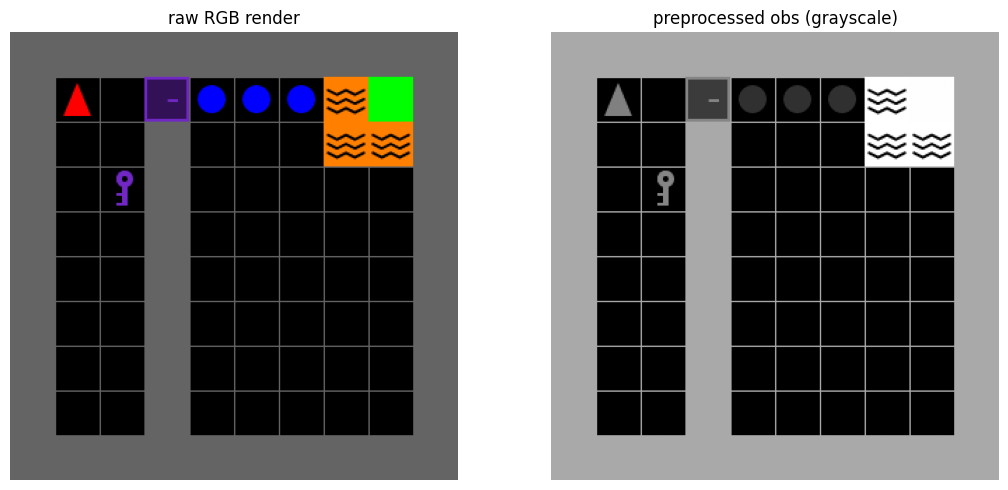

In [13]:
# Compose the example wrappers and inspect the result. Order matters.
demo = ComplexEnv(max_steps=400)
demo = EventShapingWrapper(demo, base_reward_scale=10.0, door_bonus=1.0, step_penalty=0.01)
demo = ActionSubsetWrapper(demo, action_ids=(0, 1, 2, 3, 4, 5))
demo = GrayscaleWrapper(demo)

obs, info = demo.reset(seed=42)
print(f"wrapped obs shape / dtype : {obs.shape}  {obs.dtype}")
print(f"observation_space         : {demo.observation_space}")
print(f"action_space              : {demo.action_space}  (subset of the 7 MiniGrid actions)")

raw = demo.unwrapped.render()                       # full-color render of the same state
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(raw); axes[0].set_title("raw RGB render"); axes[0].axis("off")
axes[1].imshow(obs.squeeze(), cmap="gray")
axes[1].set_title("preprocessed obs (grayscale)"); axes[1].axis("off")
plt.tight_layout(); plt.show()

## Environment explorer (drive an env by hand)

Step an env one action at a time with buttons, rendered inline, watching the reward, getters, and status
flags update. Point it at a **wrapped** env to see your shaped / scaled reward and preprocessed pipeline
(state read-outs come from `env.unwrapped`).

**Requires** `ipywidgets` and `env_explorer.py` in the working directory (in Colab, drag the file into
the **Files** panel). Safe to skip if a dependency is missing. Re-run after editing an env or a wrapper.

In [14]:
# Optional manual driver. Drive a *wrapped* env by hand to watch shaped reward + getters as you act.
# (Pass `ComplexEnv` instead for the bare env.) On Colab: drag env_explorer.py into Files first.
def make_explore_env():
    env = ComplexEnv(max_steps=400)
    env = EventShapingWrapper(env, base_reward_scale=10.0, door_bonus=1.0, step_penalty=0.01)
    env = ActionSubsetWrapper(env, action_ids=(0, 1, 2, 3, 4, 5))
    env = GrayscaleWrapper(env)
    return env

print("Optional env_explorer cell skipped for Run All.")
# try:
#     from env_explorer import explore_env
#     explore_env(make_explore_env, seed=None)        # or explore_env(ComplexEnv) for the raw env
# except Exception as exc:
#     print(f"[explorer] not started: {exc}")

Optional env_explorer cell skipped for Run All.


# Your Code Below

Everything below is yours — add as many cells as you need. Build your wrappers and agents here; see the PDF
for the deliverables. Good luck!

## Device

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Reproducibility & Utilities


In [ ]:
# Canonical ComplexEnv stage names, used by every stage plot/table below.
STAGE_LABELS = ["None", "Key", "Door", "Water", "Lava", "Goal"]

# ---------------------------------------------------------------------------
# Artifact persistence (ARTIFACTS / STORAGE_ROOT come from the setup cell)
# ---------------------------------------------------------------------------
# Every sub-module an agent may own. save/load walk this list and skip whatever
# a given agent does not have, so no slot is written for a module that does not
# exist (DQN has no policy, REINFORCE has a value_net only with the baseline on).
AGENT_MODULES = ("q_net", "target_net", "policy", "value_net", "network")


def _agent_state(agent):
    return {a: getattr(agent, a).state_dict()
            for a in AGENT_MODULES if getattr(agent, a, None) is not None}


def save_agent(agent, name):
    path = os.path.join(ARTIFACTS, "checkpoints", f"{name}.pt")
    torch.save(_agent_state(agent), path)
    return path


def load_agent(agent, name, map_location=None):
    """Inverse of save_agent: restore weights into an already-constructed agent."""
    path = os.path.join(ARTIFACTS, "checkpoints", f"{name}.pt")
    state = torch.load(path, map_location=map_location or device)
    for attr in AGENT_MODULES:
        module = getattr(agent, attr, None)
        if module is not None and attr in state:
            module.load_state_dict(state[attr])
    return agent


def save_figure(fig, name):
    if fig is None:                       # e.g. plot_stage_progress with no stage data
        return None
    path = os.path.join(ARTIFACTS, "plots", f"{name}.png")
    fig.savefig(path, dpi=120, bbox_inches="tight")
    return path


# ---------------------------------------------------------------------------
# Seeding — call once at the top of each training run
# ---------------------------------------------------------------------------
def set_seed(seed=42):
    """Seed Python, NumPy, and PyTorch for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def episode_seed(seed, episode_idx, phase="train"):
    """Deterministic per-episode seed for env.reset().

    The phase offsets keep train / eval / greedy-probe / video seed spaces
    disjoint, so evaluation layouts are never layouts the agent trained on.
    """
    phase_offset = {"train": 0, "eval": 10_000_000, "video": 20_000_000,
                    "probe": 30_000_000, "eval_torch": 40_000_000}.get(phase, 0)
    return int(seed) + phase_offset + int(episode_idx)


# ---------------------------------------------------------------------------
# Training logger — stores per-episode metrics
# ---------------------------------------------------------------------------
class TrainingLogger:
    """Per-episode metric store for training runs.

    Per episode it records the undiscounted shaped and sparse returns, the
    *discounted* returns G_0 = sum_t gamma^t r_{t+1} for both signals, the
    episode length, the success flag, the cumulative environment-step count and
    (ComplexEnv) the furthest stage reached.

    The discounted shaped return has to be accumulated online by the training
    loop (per-step rewards are not stored). The discounted sparse return does
    not: the sparse reward fires only on the terminal goal step, so
    G_0^sparse = success * gamma^(steps-1) exactly, which is why it can also be
    reconstructed for runs logged before this field existed (see load_logger).
    """

    def __init__(self, gamma=0.99):
        self.gamma = float(gamma)
        self.rewards = []               # undiscounted shaped return
        self.sparse_rewards = []        # undiscounted true env return
        self.disc_rewards = []          # discounted shaped return (NaN if not tracked)
        self.disc_sparse_rewards = []   # discounted true env return
        self.steps = []
        self.successes = []
        self.cumulative_steps = []
        self.total_steps = 0
        self.stages = []                # ComplexEnv: max stage reached per episode
        self.probe_episodes = []        # greedy (eps=0) probe: episode index
        self.probe_successes = []       # greedy probe: success rate at that episode

    def log(self, reward, steps, success, info=None, sparse_reward=0.0,
            disc_reward=None, disc_sparse_reward=None):
        self.rewards.append(float(reward))
        self.sparse_rewards.append(float(sparse_reward))
        self.steps.append(int(steps))
        self.successes.append(float(success))
        self.total_steps += int(steps)
        self.cumulative_steps.append(self.total_steps)
        if disc_sparse_reward is None:
            disc_sparse_reward = float(success) * self.gamma ** max(0, int(steps) - 1)
        self.disc_sparse_rewards.append(float(disc_sparse_reward))
        self.disc_rewards.append(float("nan") if disc_reward is None
                                 else float(disc_reward))
        if info is not None and "stage_reached" in info:
            self.stages.append(info["stage_reached"])

    def log_greedy_probe(self, episode, success_rate):
        """Record a periodic epsilon=0 / argmax probe so the training curve and
        the reported evaluation measure the *same* policy."""
        self.probe_episodes.append(int(episode))
        self.probe_successes.append(float(success_rate))

    def get_success_rate(self, window=100):
        if not self.successes:
            return 0.0
        recent = self.successes[-window:]
        return sum(recent) / len(recent)

    def get_mean(self, attr, window=100):
        data = [v for v in getattr(self, attr, [])[-window:] if v == v]  # drop NaN
        return float(np.mean(data)) if data else 0.0


# ---------------------------------------------------------------------------

def save_logger(logger, name):
    path = os.path.join(ARTIFACTS, "logs", f"{name}.json")
    with open(path, "w") as f:
        json.dump({k: v for k, v in vars(logger).items()
                   if isinstance(v, (list, int, float))}, f)
    return path


def load_logger(name):
    path = os.path.join(ARTIFACTS, "logs", f"{name}.json")
    with open(path, "r") as f:
        data = json.load(f)

    logger = TrainingLogger()
    for k, v in data.items():
        setattr(logger, k, v)

    # Backwards compatibility with logs saved by earlier revisions of this
    # notebook: fill in / repair every derived series so a loaded log plots
    # exactly like a freshly trained one.
    n = len(logger.rewards)
    if len(logger.sparse_rewards) != n:
        logger.sparse_rewards = [0.0] * n
    if len(logger.cumulative_steps) != n:          # chunked runs used to drop this
        logger.cumulative_steps = [int(x) for x in np.cumsum(logger.steps)]
        logger.total_steps = int(logger.cumulative_steps[-1]) if n else 0
    if len(logger.disc_sparse_rewards) != n:
        g = float(getattr(logger, "gamma", 0.99) or 0.99)
        logger.disc_sparse_rewards = [
            float(s) * g ** max(0, int(st) - 1)
            for s, st in zip(logger.successes, logger.steps)
        ]
    if len(logger.disc_rewards) != n:
        logger.disc_rewards = [float("nan")] * n   # not recoverable after the fact
    return logger


def merge_logger(target, source):
    """Append a later training chunk onto `target`, keeping derived series exact.

    The previous version merged only (rewards, sparse_rewards, steps, successes,
    stages) and silently dropped cumulative_steps/total_steps, which made the
    required cumulative-environment-steps curve span the last chunk only. Both
    are now rebuilt from the merged episode lengths.
    """
    offset = len(target.rewards)
    for attr in ("rewards", "sparse_rewards", "disc_rewards",
                 "disc_sparse_rewards", "steps", "successes", "stages"):
        getattr(target, attr).extend(getattr(source, attr, []))
    for ep, sr in zip(getattr(source, "probe_episodes", []),
                      getattr(source, "probe_successes", [])):
        target.probe_episodes.append(int(ep) + offset)
        target.probe_successes.append(float(sr))
    target.cumulative_steps = [int(x) for x in np.cumsum(target.steps)]
    target.total_steps = int(target.cumulative_steps[-1]) if target.cumulative_steps else 0
    return target


# ---------------------------------------------------------------------------
# Mid-run autosave — survive a Colab disconnect
# ---------------------------------------------------------------------------
# A T4 session can drop mid-cell (idle timeout, session cap). BestCheckpointer
# persists weights only when the score *improves*, and the TrainingLogger — the
# data behind every required plot — otherwise lives in RAM until the run cell's
# final save_logger(). A disconnect at episode 3,900 of 4,000 would keep a
# checkpoint from episode ~100 and lose the entire training curve.
#
# autosave_run flushes both on a fixed cadence, overwriting the same two files:
#   artifacts/logs/<name>.json              the curve so far (final save overwrites it)
#   artifacts/checkpoints/<name>_latest.pt  the *current* weights + agent.steps
# `steps` matters for DQN: epsilon and the target sync both run off it, so a
# resume without it silently restarts exploration at eps_start = 1.0.
def autosave_run(agent, logger, name, episode):
    """Flush the training log and the current weights mid-run. Returns both paths."""
    log_path = save_logger(logger, name)
    state = _agent_state(agent)
    state["steps"] = int(getattr(agent, "steps", 0))
    state["episode"] = int(episode)
    ckpt_path = os.path.join(ARTIFACTS, "checkpoints", f"{name}_latest.pt")
    torch.save(state, ckpt_path)
    return log_path, ckpt_path


def load_latest(agent, name, map_location=None):
    """Restore an autosave written by autosave_run.

    Returns (agent, steps, episode) so a resumed run can continue the epsilon
    schedule and the episode-seed sequence instead of replaying the opening
    layouts. Unlike BestCheckpointer.load_best this gives the *current* network,
    which is what resuming needs.
    """
    path = os.path.join(ARTIFACTS, "checkpoints", f"{name}_latest.pt")
    state = torch.load(path, map_location=map_location or device)
    for attr in AGENT_MODULES:
        module = getattr(agent, attr, None)
        if module is not None and attr in state:
            module.load_state_dict(state[attr])
    steps = int(state.get("steps", 0))
    episode = int(state.get("episode", 0))
    if hasattr(agent, "steps"):
        agent.steps = steps
        agent.last_sync = steps      # keep the target-sync cadence, don't fire on resume
    return agent, steps, episode


# ---------------------------------------------------------------------------
# Model selection — one rule, applied identically to all three algorithms
# ---------------------------------------------------------------------------
class BestCheckpointer:
    """Best-so-far checkpointing keyed on rolling training performance.

    Every `every` episodes the score (rolling success rate, then mean stage, then
    mean shaped return over the last `window` episodes) is compared against the
    best seen; on improvement the agent's weights are written to
    ARTIFACTS/checkpoints/<name>_best.pt. `load_best` restores them before
    evaluation. Using the identical rule for DQN, REINFORCE and PPO is what makes
    the three-way comparison like-for-like (previously only DQN/ComplexEnv was
    evaluated at its best checkpoint while the others used final weights).
    """

    def __init__(self, name, every=100, window=100, enabled=True):
        self.name = name
        self.every = int(every)
        self.window = int(window)
        self.enabled = bool(enabled)
        self.path = os.path.join(ARTIFACTS, "checkpoints", f"{name}_best.pt")
        self.best_score = None
        self.best_episode = None

    def _score(self, logger):
        sr = logger.get_success_rate(self.window)
        stage = logger.get_mean("stages", self.window) if logger.stages else 0.0
        shaped = logger.get_mean("rewards", self.window)
        return (round(sr, 6), round(stage, 6), round(shaped, 6))

    def maybe_update(self, agent, logger, episode, force=False):
        """Call once per episode with the 1-based global episode number."""
        if not self.enabled:
            return False
        if not force and episode % self.every != 0:
            return False
        score = self._score(logger)
        if self.best_score is not None and score <= self.best_score:
            return False
        self.best_score = score
        self.best_episode = int(episode)
        state = _agent_state(agent)
        state["episode"] = int(episode)
        state["score"] = list(score)
        torch.save(state, self.path)
        return True

    def load_best(self, agent, verbose=True):
        if not os.path.exists(self.path):
            if verbose:
                print(f"[{self.name}] no best checkpoint on disk — keeping final weights.")
            return agent
        state = torch.load(self.path, map_location=device)
        for attr in AGENT_MODULES:
            module = getattr(agent, attr, None)
            if module is not None and attr in state:
                module.load_state_dict(state[attr])
        if verbose:
            sr, stage, shaped = state.get("score", (float("nan"),) * 3)
            print(f"[{self.name}] restored best checkpoint from episode "
                  f"{state.get('episode')} (SR{self.window}={sr:.3f}, "
                  f"mean stage={stage:.2f}, mean shaped={shaped:+.2f})")
        return agent


# ---------------------------------------------------------------------------
# Plotting helpers
# ---------------------------------------------------------------------------
def _rolling(data, window):
    """Simple rolling average via convolution."""
    data = list(data)
    if len(data) == 0:
        return np.array([])
    window = max(1, min(window, len(data)))
    kernel = np.ones(window) / window
    return np.convolve(data, kernel, mode="valid")


def _plot_rolling(ax, data, window, color, label=None, raw_alpha=0.25):
    data = list(data)
    if not data:
        return
    if raw_alpha:
        ax.plot(data, alpha=raw_alpha, color=color)
    r = _rolling(data, window)
    x0 = max(0, len(data) - len(r))
    ax.plot(range(x0, x0 + len(r)), r, color=color, lw=2, label=label)


def _success_conditioned_steps(logger, window=50):
    """Rolling mean episode length over *successful* episodes only.

    Once the success rate plateaus this is the curve that still shows learning:
    it answers "is the agent reaching the goal faster?", which the unconditional
    steps-per-episode curve hides (failures always run to the step cap).
    """
    idx = [i for i, s in enumerate(logger.successes) if s > 0]
    lens = [logger.steps[i] for i in idx]
    if not lens:
        return [], np.array([])
    r = _rolling(lens, window)
    return idx[len(idx) - len(r):], r


def _has_shaped_discounted(logger):
    vals = getattr(logger, "disc_rewards", [])
    return any(v == v for v in vals)      # any non-NaN


def plot_training(logger, title="Training", window=50):
    """6-panel training curves for a single run.

    Row 1: undiscounted return, discounted return (the requested
           "discounted reward vs episode"), success rate (+ greedy probes).
    Row 2: steps per episode, steps per *successful* episode, cumulative
           environment steps (the common sample-budget axis).
    """
    fig, axes = plt.subplots(2, 3, figsize=(19, 9))
    fig.suptitle(title, fontsize=16, fontweight="bold")

    # --- undiscounted return -------------------------------------------------
    ax = axes[0, 0]
    _plot_rolling(ax, logger.rewards, window, "royalblue", label="shaped")
    _plot_rolling(ax, logger.sparse_rewards, window, "darkorange",
                  label="sparse (true env)", raw_alpha=0.0)
    ax.set(xlabel="Episode", ylabel="Return", title="Undiscounted Return per Episode")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # --- discounted return ---------------------------------------------------
    ax = axes[0, 1]
    g = getattr(logger, "gamma", 0.99)
    if _has_shaped_discounted(logger):
        _plot_rolling(ax, logger.disc_rewards, window, "royalblue", label="shaped")
    _plot_rolling(ax, logger.disc_sparse_rewards, window, "darkorange",
                  label="sparse (true env)", raw_alpha=0.0)
    ax.set(xlabel="Episode", ylabel=r"$G_0=\sum_t \gamma^t r_{t+1}$",
           title=f"Discounted Return per Episode ($\\gamma$={g})")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # --- success rate --------------------------------------------------------
    ax = axes[0, 2]
    r = _rolling(logger.successes, window)
    x0 = max(0, len(logger.successes) - len(r))
    ax.plot(range(x0, x0 + len(r)), r, color="crimson", lw=2,
            label=f"rolling {window} (behaviour policy)")
    if getattr(logger, "probe_episodes", []):
        ax.plot(logger.probe_episodes, logger.probe_successes, "o--", color="black",
                ms=4, lw=1, label="greedy probe ($\\epsilon$=0)")
    ax.set(xlabel="Episode", ylabel="Success Rate", title="Success Rate")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # --- steps ---------------------------------------------------------------
    ax = axes[1, 0]
    _plot_rolling(ax, logger.steps, window, "seagreen")
    ax.set(xlabel="Episode", ylabel="Steps", title="Steps per Episode (all episodes)")
    ax.grid(True, alpha=0.3)

    # --- steps, successes only ----------------------------------------------
    ax = axes[1, 1]
    xs, ys = _success_conditioned_steps(logger, window)
    if len(ys):
        ax.plot(xs, ys, color="seagreen", lw=2)
    else:
        ax.text(0.5, 0.5, "no successful episodes", ha="center", va="center",
                transform=ax.transAxes, color="gray")
    ax.set(xlabel="Episode", ylabel="Steps",
           title="Steps per Successful Episode (goal-reaching speed)")
    ax.grid(True, alpha=0.3)

    # --- cumulative env steps ------------------------------------------------
    ax = axes[1, 2]
    ax.plot(logger.cumulative_steps, color="darkorchid", lw=2)
    ax.set(xlabel="Episode", ylabel="Cumulative Steps",
           title="Cumulative Environment Steps")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig


def plot_comparison(loggers, names, title="Algorithm Comparison", window=50):
    """Overlay the same six curves for multiple algorithms on a common axis."""
    fig, axes = plt.subplots(2, 3, figsize=(19, 9))
    fig.suptitle(title, fontsize=16, fontweight="bold")
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

    for i, (lg, name) in enumerate(zip(loggers, names)):
        c = colors[i % len(colors)]

        _plot_rolling(axes[0, 0], lg.rewards, window, c, label=name, raw_alpha=0.0)
        _plot_rolling(axes[0, 1], lg.disc_sparse_rewards, window, c, label=name,
                      raw_alpha=0.0)
        _plot_rolling(axes[0, 2], lg.successes, window, c, label=name, raw_alpha=0.0)
        _plot_rolling(axes[1, 0], lg.steps, window, c, label=name, raw_alpha=0.0)
        xs, ys = _success_conditioned_steps(lg, window)
        if len(ys):
            axes[1, 1].plot(xs, ys, color=c, lw=2, label=name)
        axes[1, 2].plot(lg.cumulative_steps, color=c, lw=2, label=name)

    titles = [
        ("Undiscounted Shaped Return", "Return"),
        ("Discounted Sparse Return $G_0$", r"$G_0^{sparse}$"),
        (f"Success Rate (rolling {window})", "Success Rate"),
        ("Steps per Episode", "Steps"),
        ("Steps per Successful Episode", "Steps"),
        ("Cumulative Environment Steps", "Cumulative Steps"),
    ]
    for ax, (t, ylab) in zip(axes.ravel(), titles):
        ax.set(xlabel="Episode", ylabel=ylab, title=t)
        ax.grid(True, alpha=0.3)
        if ax.get_legend_handles_labels()[0]:
            ax.legend(fontsize=8)
    axes[0, 2].set_ylim(-0.05, 1.05)

    plt.tight_layout()
    plt.show()
    return fig


def plot_stage_progress(logger, title="ComplexEnv Stage Progress", window=50):
    """Stage-reached scatter + distribution for ComplexEnv runs."""
    if not logger.stages:
        print("No stage data to plot.")
        return None
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=16, fontweight="bold")

    ax = axes[0]
    data = logger.stages
    ax.scatter(range(len(data)), data, alpha=0.2, s=8, c="teal")
    r = _rolling(data, window)
    x0 = max(0, len(data) - len(r))
    ax.plot(range(x0, x0 + len(r)), r, color="crimson", lw=2)
    ax.set(xlabel="Episode", ylabel="Stage", title="Max Stage per Episode")
    ax.set_yticks(range(6))
    ax.set_yticklabels(STAGE_LABELS)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    counts = [logger.stages.count(i) for i in range(6)]
    bar_colors = ["#999", "#9b59b6", "#8B4513", "#3498db", "#e67e22", "#2ecc71"]
    ax.bar(STAGE_LABELS, counts, color=bar_colors)
    ax.set(xlabel="Stage", ylabel="Episodes", title="Stage Distribution")
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()
    return fig


# Canonical stage names, used by every stage plot/table in the notebook.
STAGE_LABELS = ["None", "Key", "Door", "Water", "Lava", "Goal"]

print("Utilities loaded.")

## Wrappers: Preprocessing & Reward Shaping


In [17]:
class SparseReturnTracker(gym.Wrapper):
    """Innermost shim: expose true sparse env reward via info['sparse_reward']."""
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        info = dict(info)
        info["sparse_reward"] = float(reward)
        return obs, reward, terminated, truncated, info


class PreprocessWrapper(gym.ObservationWrapper):
    """Resize to (size x size), optional grayscale, HWC -> CHW, normalise to [0,1]."""

    def __init__(self, env, size=84, grayscale=False):
        super().__init__(env)
        self.size = size
        self.grayscale = grayscale
        c = 1 if grayscale else 3
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(c, size, size), dtype=np.float32)

    def observation(self, obs):
        if self.grayscale:
            obs = cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)
        obs = cv2.resize(obs, (self.size, self.size), interpolation=cv2.INTER_AREA)
        if obs.ndim == 2:
            obs = obs[:, :, None]
        obs = np.transpose(obs, (2, 0, 1))
        return obs.astype(np.float32) / 255.0


class SimpleShapingWrapper(gym.Wrapper):
    """Scale the sparse goal reward and add a per-step penalty."""

    def __init__(self, env, goal_scale=10.0, step_penalty=0.01):
        super().__init__(env)
        self.goal_scale = goal_scale
        self.step_penalty = step_penalty

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        shaped = self.goal_scale * float(reward) - self.step_penalty
        return obs, shaped, terminated, truncated, info


class RichShapingWrapper(gym.Wrapper):
    """Milestone-event reward shaping for ComplexEnv.

    Uses the env getters (curr vs prev) to detect events.
    One-time latched: key pickup, door open, enter right room.
    Per occurrence: water pickup (bounded by ``water_mode``), lava extinguish.
    Also: goal reward scaling, step penalty, lava-death penalty.
    Tracks max_stage reached for analysis.

    Budget discipline (see the shaping-mass audit cell below): the *discounted*
    milestone mass along a competent trajectory must stay strictly below the
    discounted goal payoff, otherwise the shaped optimum is "collect milestones,
    then idle to the step cap" rather than "reach the goal" — which is exactly
    what the previous defaults (13.5 milestone mass vs a goal of 10) produced.
    The defaults below satisfy that inequality by a factor of ~1.8.

    Only *event counts* are used for shaping. No position getter is consulted:
    remaining lava is derived from ``info["n_lava"] - extinguished_lava_count()``,
    because the environment reserves the position getters for analysis.
    """

    def __init__(self, env, goal_scale=20.0, key_bonus=0.5,
                 door_bonus=1.0, right_room_bonus=0.25,
                 water_bonus=0.2, lava_bonus=0.5,
                 step_penalty=0.01, death_penalty=2.0,
                 water_mode="first",
                 drop_water_penalty=0.2):
        super().__init__(env)
        self.goal_scale = goal_scale
        self.key_bonus = key_bonus
        self.door_bonus = door_bonus
        self.right_room_bonus = right_room_bonus
        self.water_bonus = water_bonus
        self.lava_bonus = lava_bonus
        self.step_penalty = step_penalty
        self.death_penalty = death_penalty
        self._key_picked = False
        self._door_opened = False
        self._entered_right = False
        self._ever_picked_water = False
        self._max_stage = 0
        assert water_mode in ("first", "gated", "per_pickup", "per_lava")
        self.water_mode = water_mode
        self._first_water_done = False
        self.drop_water_penalty = drop_water_penalty
        self._water_rewards_given = 0

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._key_picked = False
        self._door_opened = False
        self._entered_right = False
        self._ever_picked_water = False
        self._max_stage = 0
        self._first_water_done = False
        self._water_rewards_given = 0
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        core = self.env.unwrapped
        shaped = self.goal_scale * float(reward) - self.step_penalty

        n_lava = int(info.get("n_lava", 3))
        lava_left = (n_lava - core.extinguished_lava_count()) > 0

        # Key pickup (one-time)
        if not self._key_picked and core.is_carrying_key() and not core.prev_carrying_key():
            shaped += self.key_bonus
            self._key_picked = True

        # Door opened (one-time)
        if not self._door_opened and core.is_door_open() and not core.prev_door_open():
            shaped += self.door_bonus
            self._door_opened = True

        # Entered right room (one-time)
        if not self._entered_right and core.is_in_right_room() and not core.prev_in_right_room():
            shaped += self.right_room_bonus
            self._entered_right = True

        # Water pickup
        picked_water_now = core.is_carrying_water() and not core.prev_carrying_water()

        if picked_water_now:
            self._ever_picked_water = True
            give = False

            current_extinguished = core.extinguished_lava_count()
            max_water_rewards = n_lava

            if self.water_mode == "first":
                # Reward only the first water pickup in the episode.
                if not self._first_water_done:
                    give = True
                    self._first_water_done = True

            elif self.water_mode == "gated":
                # Old behaviour: can still be farmed by repeated pickup/drop.
                if self._door_opened and lava_left:
                    give = True

            elif self.water_mode == "per_pickup":
                # Fully permissive, mostly for ablation/debugging.
                give = True

            elif self.water_mode == "per_lava":
                # Anti-farming mode:
                # allow one water-pickup bonus for each lava-progress level.
                #
                # Before any lava is extinguished:
                #   current_extinguished = 0, water_rewards_given = 0 -> reward first water pickup.
                #
                # Repeated pickup/drop before extinguishing:
                #   current_extinguished = 0, water_rewards_given = 1 -> no reward.
                #
                # After one lava tile is extinguished:
                #   current_extinguished = 1, water_rewards_given = 1 -> reward next water pickup.
                if (
                    self._door_opened
                    and lava_left
                    and self._water_rewards_given <= current_extinguished
                    and self._water_rewards_given < max_water_rewards
                ):
                    give = True
                    self._water_rewards_given += 1

            if give:
                shaped += self.water_bonus

        # Penalise dropping water before extinguishing lava.
        # This discourages water pickup/drop loops and encourages carrying water to lava.
        # The action id is read from the env's own action enum so the check keeps
        # working if the action subset or wrapper order changes.
        dropped_water_now = (
            core.prev_carrying_water()
            and not core.is_carrying_water()
            and int(action) == int(core.actions.drop)
        )

        if dropped_water_now and lava_left:
            shaped -= self.drop_water_penalty

        # Lava extinguished (per tile)
        if core.extinguished_lava_count() > core.prev_extinguished_lava_count():
            shaped += self.lava_bonus

        # Lava death penalty
        if info.get("died_on_lava", False):
            shaped -= self.death_penalty

        # Stage tracking for analysis
        stage = 0
        if self._key_picked:
            stage = 1
        if self._door_opened:
            stage = 2
        if self._ever_picked_water:
            stage = 3
        if core.extinguished_lava_count() > 0:
            stage = 4
        if info.get("is_success", False):
            stage = 5
        self._max_stage = max(self._max_stage, stage)
        info["stage_reached"] = self._max_stage

        return obs, shaped, terminated, truncated, info


print("Wrappers loaded.")

Wrappers loaded.


## Environment Factories

Composable factory functions used everywhere: training, evaluation, and video recording.
- **SimpleRoomEnv**: grayscale (1 ch), 3 actions (left/right/forward), light shaping.
- **ComplexEnv**: colour (3 ch), 6 actions (all except `done`), rich milestone shaping.


In [18]:
def make_simple_env(max_steps=100):
    """Wrapped SimpleRoomEnv: grayscale, 3 actions, goal reward x10."""
    env = SimpleRoomEnv(max_steps=max_steps)
    env = SparseReturnTracker(env)
    env = SimpleShapingWrapper(env, goal_scale=10.0, step_penalty=0.01)
    env = ActionSubsetWrapper(env, action_ids=(0, 1, 2))  # left, right, forward
    env = PreprocessWrapper(env, size=84, grayscale=True)
    return env


# ComplexEnv shaping constants, stated once here and audited in the next cell
# against the discounted goal payoff (see M8 / "Reward Shaping Analysis").
COMPLEX_SHAPING = dict(
    goal_scale=20.0,
    key_bonus=0.5,
    door_bonus=1.0,
    right_room_bonus=0.25,
    water_bonus=0.2,
    lava_bonus=0.5,
    step_penalty=0.01,
    death_penalty=2.0,
    water_mode="first",
    drop_water_penalty=0.2,
)


def make_complex_env(max_steps=400):
    """Wrapped ComplexEnv: colour, 6 actions, rich milestone shaping."""
    env = ComplexEnv(max_steps=max_steps)
    env = SparseReturnTracker(env)
    env = RichShapingWrapper(env, **COMPLEX_SHAPING)
    env = ActionSubsetWrapper(env, action_ids=(0, 1, 2, 3, 4, 5))
    env = PreprocessWrapper(env, size=84, grayscale=False)
    return env


# Quick sanity check
tmp_env = make_complex_env()
w = tmp_env

while hasattr(w, "env"):
    if isinstance(w, RichShapingWrapper):
        print(
            "ComplexEnv shaping:",
            "water_mode =", w.water_mode,
            "water_bonus =", w.water_bonus,
            "lava_bonus =", w.lava_bonus,
            "goal_scale =", w.goal_scale,
        )
        break
    w = w.env

tmp_env.close()

# Quick sanity check
_ts = make_simple_env(); _tc = make_complex_env()
_os, _ = _ts.reset(seed=0); _oc, _ = _tc.reset(seed=0)
print(f"SimpleRoomEnv  obs: {_os.shape} {_os.dtype}  actions: {_ts.action_space}")
print(f"ComplexEnv     obs: {_oc.shape} {_oc.dtype}  actions: {_tc.action_space}")
_ts.close(); _tc.close()
del _ts, _tc, _os, _oc

ComplexEnv shaping: water_mode = first water_bonus = 0.2 lava_bonus = 0.5 goal_scale = 20.0
SimpleRoomEnv  obs: (1, 84, 84) float32  actions: Discrete(3)
ComplexEnv     obs: (3, 84, 84) float32  actions: Discrete(6)


### Shaping-budget audit — does the shaping preserve the goal as the optimum?

Event shaping is only safe if the agent cannot do better by farming milestones than
by finishing the task. The decisive comparison is not the *raw* bonus total but the
**discounted** total at decision time: milestones fire early, the goal fires ~200
steps later, and at $\gamma = 0.99$ a payoff 200 steps away is worth only
$\gamma^{200} \approx 0.13$ of its face value.

The cell below computes both sides of the inequality along an explicit competent
trajectory (the milestone timings a solving agent would hit) and asserts

$$\sum_i \gamma^{t_i} b_i \;<\; \gamma^{T_{goal}} \cdot \text{goal\_scale}$$

The earlier configuration (`goal_scale=10`, `key=1`, `door=2`, `right_room=1`,
`water=0.5`, `lava=3`/tile) fails this test by 3.6x: **+13.5** of milestone mass against
a goal worth **+10** undiscounted and **+1.34** discounted — so "collect the milestones,
then idle until the step cap" was genuinely the better shaped policy, and the trained
PPO agent found exactly that optimum (key → door → water, then 400 steps of nothing).
The audited configuration keeps every milestone as a learning signal but places the
whole ladder strictly below the goal payoff.

In [19]:
# =========================================================
# Reward-shaping mass audit (M8): discounted milestone total vs discounted goal
# =========================================================

# Milestone timings of a *competent* ComplexEnv trajectory, in env steps. These are
# read off the layout: the key is ~30 steps away, the door ~30 more, the water
# cluster sits in the right room, each lava tile costs a fetch-and-toggle round
# trip, and the goal corner is behind the lava ring.
COMPETENT_TIMELINE = {
    "key_bonus":        [30],
    "door_bonus":       [60],
    "right_room_bonus": [65],
    "water_bonus":      [90],
    "lava_bonus":       [110, 140, 170],   # one per lava tile (n_lava = 3)
}
GOAL_STEP = 200        # step at which the goal reward is collected
GAMMA = 0.99


def audit_shaping_mass(shaping=COMPLEX_SHAPING, timeline=COMPETENT_TIMELINE,
                       goal_step=GOAL_STEP, gamma=GAMMA, label="audited config",
                       strict=True):
    """Print and check the shaping budget of a ComplexEnv shaping configuration.

    Returns (discounted_milestone_mass, discounted_goal_payoff).
    """
    rows, disc_total, raw_total = [], 0.0, 0.0
    for name, times in timeline.items():
        bonus = float(shaping[name])
        for t in times:
            disc = bonus * gamma ** t
            rows.append((name, t, bonus, disc))
            disc_total += disc
            raw_total += bonus

    goal_raw = float(shaping["goal_scale"])
    goal_disc = goal_raw * gamma ** goal_step
    step_cost = float(shaping["step_penalty"]) * 400          # full step budget

    print(f"Shaping budget audit — {label} (gamma={gamma})")
    print("-" * 72)
    print(f"{'milestone':<20}{'step':>6}{'bonus':>10}{'discounted':>14}")
    for name, t, bonus, disc in rows:
        print(f"{name:<20}{t:>6}{bonus:>10.2f}{disc:>14.3f}")
    print("-" * 72)
    print(f"{'milestone total':<20}{'':>6}{raw_total:>10.2f}{disc_total:>14.3f}")
    print(f"{'goal payoff':<20}{goal_step:>6}{goal_raw:>10.2f}{goal_disc:>14.3f}")
    print(f"{'ratio milestones/goal':<27}"
          f"{raw_total / goal_raw:>9.2f}x{disc_total / goal_disc:>13.2f}x")
    print(f"\nMilestones-then-idle return (400 steps): "
          f"{raw_total - step_cost:+.2f}   "
          f"(idling is only attractive while this is positive)")
    ok = disc_total < goal_disc
    print("PASS: discounted milestone mass < discounted goal payoff." if ok else
          "FAIL: shaping mass exceeds the goal payoff — the shaped optimum may "
          "exclude reaching the goal.")
    if strict:
        assert ok, ("Shaping budget violated: discounted milestone mass "
                    f"{disc_total:.3f} >= discounted goal payoff {goal_disc:.3f}")
    return disc_total, goal_disc


# The configuration actually used for training.
audit_shaping_mass()

# For the record: the pre-fix configuration this replaces (assert relaxed so the
# cell still runs — it is shown precisely because it fails the test).
print()
audit_shaping_mass(
    shaping=dict(COMPLEX_SHAPING, goal_scale=10.0, key_bonus=1.0, door_bonus=2.0,
                 right_room_bonus=1.0, water_bonus=0.5, lava_bonus=3.0),
    label="pre-fix config (for comparison)",
    strict=False,
)

Shaping budget audit — audited config (gamma=0.99)
------------------------------------------------------------------------
milestone             step     bonus    discounted
key_bonus               30      0.50         0.370
door_bonus              60      1.00         0.547
right_room_bonus        65      0.25         0.130
water_bonus             90      0.20         0.081
lava_bonus             110      0.50         0.166
lava_bonus             140      0.50         0.122
lava_bonus             170      0.50         0.091
------------------------------------------------------------------------
milestone total                 3.45         1.507
goal payoff            200     20.00         2.680
ratio milestones/goal           0.17x         0.56x

Milestones-then-idle return (400 steps): -0.55   (idling is only attractive while this is positive)
PASS: discounted milestone mass < discounted goal payoff.

Shaping budget audit — pre-fix config (for comparison) (gamma=0.99)
-------------

(4.827796188605012, 1.3397967485796172)

## Exploratory Data Analysis -- Manual Environment Walkthrough (Optional)

> **Interactive cells -- do NOT include in "Run All".**
> The `explore_env` widget blocks the kernel waiting for button presses.
> Run these cells **individually** to step through the environment by hand,
> then move on. They are commented out by default so "Kernel -> Run All" works cleanly.

Before building any agents, we manually stepped through both environments using
the interactive `env_explorer` widget to understand:
- What the pixel observations actually look like at each stage
- How the internal state flags (`is_carrying_key`, `is_door_open`, etc.) toggle
- The exact mechanics of the 5-stage pipeline in ComplexEnv
- Which actions are needed and which can be dropped

In [20]:
# [INTERACTIVE / OPTIONAL] Uncomment and run this cell manually to explore SimpleRoomEnv.
# Do NOT run with "Run All" -- the widget blocks the kernel.

# from env_explorer import explore_env
# explore_env(lambda: make_simple_env(), seed=42)

In [21]:
# [INTERACTIVE / OPTIONAL] Uncomment and run this cell manually to explore ComplexEnv.
# Do NOT run with "Run All" -- the widget blocks the kernel.

# from env_explorer import explore_env
# explore_env(lambda: make_complex_env(), seed=42)

## Replay Buffer & Neural Networks


In [ ]:
# ---------------------------------------------------------------------------
# Replay buffer (DQN) — circular, preallocated, uint8 observations, one copy
# of each observation (next_state is looked up, not duplicated).
# ---------------------------------------------------------------------------
class ReplayBuffer:
    """Fixed-capacity circular buffer for (s, a, r, s', done) transitions.

    Memory layout: ``next_state[t]`` *is* ``state[t+1]`` for every transition that
    does not end an episode, so only the boundary next-states (one per episode:
    goal, lava death, or time limit) are stored explicitly. At capacity=100k with
    3x84x84 observations that is ~2.12 GB instead of the ~4.23 GB a two-copy
    layout needs (and ~16.9 GB if observations were kept as float32). The arrays
    are preallocated, so memory is flat from the first push instead of growing.

    uint8 round-trip: preprocessing resizes on uint8 pixels *before* normalising,
    so every observation value is exactly k/255 and ``round(255*x)`` recovers k
    exactly. ``np.round`` (rather than truncation) is what keeps that lossless if
    an upstream change ever produces genuinely float-valued observations.
    """

    def __init__(self, capacity=10_000):
        self.capacity = int(capacity)
        self.obs_shape = None
        self.states = None                                          # allocated on first push
        self.actions = np.zeros(self.capacity, dtype=np.int64)
        self.rewards = np.zeros(self.capacity, dtype=np.float32)
        self.dones = np.zeros(self.capacity, dtype=np.float32)       # true terminals only
        self.boundaries = np.zeros(self.capacity, dtype=bool)        # episode ended here
        self.boundary_next = {}                                     # idx -> stored next obs
        self.pos = 0
        self.size = 0

    @staticmethod
    def _to_storage(obs):
        return np.clip(np.round(np.asarray(obs) * 255.0), 0, 255).astype(np.uint8)

    @staticmethod
    def _to_float(arr):
        return arr.astype(np.float32) / 255.0

    def push(self, state, action, reward, next_state, done, boundary=None):
        """Store one transition.

        ``done`` is the Bellman terminal flag (termination only — never a time
        limit). ``boundary`` says whether the episode ended here for *any* reason
        (termination or truncation); it defaults to ``done`` but the training loop
        passes ``terminated or truncated`` so truncated next-states are kept too.
        """
        state = np.asarray(state)
        if self.states is None:
            self.obs_shape = state.shape
            self.states = np.zeros((self.capacity, *self.obs_shape), dtype=np.uint8)
        if boundary is None:
            boundary = bool(done)

        idx = self.pos
        self.boundary_next.pop(idx, None)          # slot is being overwritten
        self.states[idx] = self._to_storage(state)
        self.actions[idx] = int(action)
        self.rewards[idx] = float(reward)
        self.dones[idx] = float(done)
        self.boundaries[idx] = bool(boundary)
        if boundary:
            self.boundary_next[idx] = self._to_storage(np.asarray(next_state))

        self.pos = (idx + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def _sample_indices(self, batch_size):
        """Uniform indices, excluding the newest transition unless its next-state
        was stored explicitly (for the newest non-boundary slot, ``state[pos]``
        has not been written yet / is stale)."""
        newest = (self.pos - 1) % self.capacity
        exclude = self.size > 1 and not self.boundaries[newest]
        if not exclude:
            return np.random.randint(0, self.size, size=batch_size)
        out = np.empty(batch_size, dtype=np.int64)
        filled = 0
        while filled < batch_size:
            cand = np.random.randint(0, self.size, size=batch_size - filled)
            cand = cand[cand != newest]
            out[filled:filled + len(cand)] = cand
            filled += len(cand)
        return out

    def sample(self, batch_size):
        idx = self._sample_indices(batch_size)
        s = self.states[idx]
        s2 = self.states[(idx + 1) % self.capacity].copy()
        for j in np.nonzero(self.boundaries[idx])[0]:
            s2[j] = self.boundary_next[int(idx[j])]
        return (self._to_float(s),
                self.actions[idx],
                self.rewards[idx],
                self._to_float(s2),
                self.dones[idx])

    def __len__(self):
        return self.size


# ---------------------------------------------------------------------------
# Rollout buffer (PPO) — stores one rollout then is cleared
# ---------------------------------------------------------------------------
class RolloutBuffer:
    """Stores a single PPO rollout; cleared after each update.

    ``terminated`` and ``truncated`` are kept separately: the first zeroes the
    bootstrap in the TD residual, the second only cuts the GAE trace while still
    bootstrapping through V(s_T) (the time limit is a data-collection artifact,
    not environment dynamics). ``boundary_values`` holds V(s_T) for the truncated
    steps, computed once per episode end by the training loop.
    """

    def __init__(self):
        self.clear()

    def add(self, state, action, log_prob, reward, value,
            terminated=0.0, truncated=0.0, boundary_value=0.0):
        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.values.append(value)
        self.terminateds.append(float(terminated))
        self.truncateds.append(float(truncated))
        self.boundary_values.append(float(boundary_value))

    def clear(self):
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.values = []
        self.terminateds = []
        self.truncateds = []
        self.boundary_values = []

    def __len__(self):
        return len(self.states)


# ---------------------------------------------------------------------------
# Weight initialisation (used by the PPO networks)
# ---------------------------------------------------------------------------
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    """Orthogonal initialisation, the PPO reference default.

    Trunk layers use gain sqrt(2) (the ReLU-preserving gain); the policy head uses
    gain 0.01 so initial logits are ~0, i.e. the initial policy is near-uniform and
    initial entropy is ~ln|A| by construction rather than by luck; the value head
    uses gain 1.0.
    """
    nn.init.orthogonal_(layer.weight, std)
    nn.init.constant_(layer.bias, bias_const)
    return layer


# ---------------------------------------------------------------------------
# CNN feature extractor (Nature-DQN style)
# ---------------------------------------------------------------------------
class CNNFeatureExtractor(nn.Module):
    """3 conv layers -> flatten -> FC 512.  Works for any in_channels."""

    def __init__(self, in_channels, feature_dim=512, orthogonal=False):
        super().__init__()
        init = layer_init if orthogonal else (lambda layer, **kw: layer)
        self.conv = nn.Sequential(
            init(nn.Conv2d(in_channels, 32, 8, stride=4)), nn.ReLU(),
            init(nn.Conv2d(32, 64, 4, stride=2)), nn.ReLU(),
            init(nn.Conv2d(64, 64, 3, stride=1)), nn.ReLU(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, 84, 84)
            self._conv_out = int(self.conv(dummy).flatten(1).size(1))
        self.fc = nn.Sequential(init(nn.Linear(self._conv_out, feature_dim)), nn.ReLU())
        self.feature_dim = feature_dim

    def forward(self, x):
        # flatten(1), not view(x.size(0), -1): on a T4 cuDNN picks a different
        # conv algorithm for large batches and can return a non-contiguous
        # output, which .view() rejects ("view size is not compatible with
        # input tensor's size and stride"). REINFORCE/ComplexEnv hits it first
        # with its 400x3x84x84 batched recompute; flatten copies when it must.
        return self.fc(self.conv(x).flatten(1))


# ---------------------------------------------------------------------------
# DQN network — CNN + linear Q-head
# ---------------------------------------------------------------------------
class DQNNetwork(nn.Module):
    def __init__(self, in_channels, n_actions, feature_dim=512):
        super().__init__()
        self.features = CNNFeatureExtractor(in_channels, feature_dim)
        self.q_head = nn.Linear(feature_dim, n_actions)

    def forward(self, x):
        return self.q_head(self.features(x))


# ---------------------------------------------------------------------------
# Policy network (REINFORCE) — CNN + logits head
# ---------------------------------------------------------------------------
class PolicyNetwork(nn.Module):
    def __init__(self, in_channels, n_actions, feature_dim=512):
        super().__init__()
        self.features = CNNFeatureExtractor(in_channels, feature_dim)
        self.head = nn.Linear(feature_dim, n_actions)

    def forward(self, x):
        return self.head(self.features(x))   # logits


# ---------------------------------------------------------------------------
# Value network — state-value baseline V(s) for REINFORCE (see the ablation cell)
# ---------------------------------------------------------------------------
class ValueNetwork(nn.Module):
    """State-value baseline for REINFORCE: V(s).

    Any state-only baseline leaves the policy gradient unbiased, because
    E[grad log pi(a|s) b(s)] = b(s) * grad sum_a pi(a|s) = b(s) * grad 1 = 0,
    and b(s) ~ V(s) is near variance-optimal.
    """

    def __init__(self, in_channels, feature_dim=512):
        super().__init__()
        self.features = CNNFeatureExtractor(in_channels, feature_dim)
        self.value_head = nn.Linear(feature_dim, 1)

    def forward(self, x):
        return self.value_head(self.features(x)).squeeze(-1)


# ---------------------------------------------------------------------------
# Actor-Critic network (PPO) — shared CNN, separate heads, orthogonal init
# ---------------------------------------------------------------------------
class ActorCriticNetwork(nn.Module):
    def __init__(self, in_channels, n_actions, feature_dim=512):
        super().__init__()
        self.features = CNNFeatureExtractor(in_channels, feature_dim, orthogonal=True)
        self.actor = layer_init(nn.Linear(feature_dim, n_actions), std=0.01)
        self.critic = layer_init(nn.Linear(feature_dim, 1), std=1.0)

    def forward(self, x):
        feats = self.features(x)
        return self.actor(feats), self.critic(feats)

    def get_action_and_value(self, x, action=None):
        feats = self.features(x)
        logits = self.actor(feats)
        dist = torch.distributions.Categorical(logits=logits)
        if action is None:
            action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), self.critic(feats)


print("Buffers and networks loaded.")

## DQN Agent

Value-based method with:
- Q-network + periodic target-network sync, on an **environment-step clock**
  (`maybe_sync_target`) so the sync period is independent of `train_freq`
- Linear epsilon-greedy decay, with a schedule length never longer than the run
  and periodic greedy ($\epsilon = 0$) probes during training
- Huber (smooth-L1) loss, gradient clipping
- Bellman targets that bootstrap through time-limit truncations
  ($d$ carries terminations only)

In [23]:
class DQNAgent:
    """Deep Q-Network agent with target network and epsilon-greedy exploration."""

    def __init__(self, in_channels, n_actions, *,
                 lr=1e-4, gamma=0.99,
                 eps_start=1.0, eps_end=0.05, eps_decay_steps=50_000,
                 buffer_size=10_000, batch_size=32, target_update=1000,
                 train_freq=1, device="cpu"):
        self.n_actions = n_actions
        self.gamma = gamma
        self.eps_start = eps_start
        self.eps_end = eps_end
        self.eps_decay_steps = eps_decay_steps
        self.batch_size = batch_size
        self.target_update = target_update
        self.train_freq = train_freq
        self.device = device

        self.q_net = DQNNetwork(in_channels, n_actions).to(device)
        self.target_net = DQNNetwork(in_channels, n_actions).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_size)
        self.steps = 0        # total env steps (drives epsilon and target sync)
        self.last_sync = 0    # env-step count at the last target-network sync
        self.n_syncs = 0

    def get_epsilon(self):
        frac = min(self.steps / self.eps_decay_steps, 1.0)
        return self.eps_start + frac * (self.eps_end - self.eps_start)

    def select_action(self, state, training=True):
        if training and random.random() < self.get_epsilon():
            return random.randrange(self.n_actions)
        with torch.no_grad():
            t = torch.as_tensor(state, dtype=torch.float32,
                                device=self.device).unsqueeze(0)
            return int(self.q_net(t).argmax(1).item())

    def maybe_sync_target(self):
        """Copy online weights into the target net every `target_update` ENV steps.

        The check used to live inside update(), which only runs every `train_freq`
        steps, so the effective period was lcm(target_update, train_freq): the
        sanity config (target_update=10, train_freq=4) synced every 20 steps —
        half the configured rate — and the shipped configs only worked because
        500 and 1000 happen to be divisible by 4. Counting against `self.steps`
        directly decouples the two knobs. Called once per env step by the
        training loop.
        """
        if self.steps - self.last_sync >= self.target_update:
            self.target_net.load_state_dict(self.q_net.state_dict())
            self.last_sync = self.steps
            self.n_syncs += 1
            return True
        return False

    def update(self):
        if len(self.buffer) < self.batch_size:
            return None
        s, a, r, s2, d = self.buffer.sample(self.batch_size)
        s  = torch.as_tensor(s,  dtype=torch.float32, device=self.device)
        a  = torch.as_tensor(a,  dtype=torch.long,    device=self.device)
        r  = torch.as_tensor(r,  dtype=torch.float32, device=self.device)
        s2 = torch.as_tensor(s2, dtype=torch.float32, device=self.device)
        d  = torch.as_tensor(d,  dtype=torch.float32, device=self.device)

        q = self.q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            q_next = self.target_net(s2).max(1)[0]
            # d carries terminations only, so a time-limit cut still bootstraps.
            target = r + self.gamma * q_next * (1.0 - d)

        loss = F.smooth_l1_loss(q, target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q_net.parameters(), 10.0)
        self.optimizer.step()

        return loss.item()


print("DQN agent loaded.")

DQN agent loaded.


## REINFORCE Agent

Policy-gradient method with:
- Episode-level Monte Carlo returns
- A **running-statistics baseline** across episodes (`baseline="running"`), with
  per-episode whitening (`"episode"`) and a learned $V(s)$ baseline (`"value"`)
  available for the ablation
- Entropy regularisation for exploration, on the **same scale** as the policy term
  (both averaged over the episode's steps, so `entropy_coef` means what it says)
- Observations stored and log-probabilities recomputed in one batched pass, so
  memory does not grow with episode length

Loss actually optimised, for an episode of length $T$:

$$L = -\frac{1}{T}\sum_{t=1}^{T}\log \pi(a_t \mid s_t)\,A_t \; - \; c_H \cdot \frac{1}{T}\sum_{t=1}^{T} H\big(\pi(\cdot \mid s_t)\big)$$

with $A_t = (G_t - \mu)/(\sigma + \varepsilon)$ under running statistics
$\mu, \sigma$. Truncated episodes keep finite-horizon returns (bias bounded by
$\gamma^{T-t}\lVert V\rVert_\infty$) unless the learned baseline is enabled, in
which case the tail is bootstrapped with $V(s_T)$.

In [24]:
class REINFORCEAgent:
    """REINFORCE with Monte-Carlo returns, a selectable baseline, and entropy bonus.

    Objective, per episode of length T (both terms averaged over the same T steps):

        L = -mean_t[ log pi(a_t|s_t) * A_t ]  -  entropy_coef * mean_t[ H(pi(.|s_t)) ]

    The policy term used to be a SUM over steps while the entropy term was a MEAN,
    so the effective entropy weight was ~coef/T, i.e. 1e-5..1e-4 of the policy
    gradient: the advertised exploration bonus was numerically inert. Both terms
    are now means, and `entropy_coef` has its nominal weight.

    Baselines (`baseline=`):
      "running"  (default) A_t = (G_t - mu) / (sigma + 1e-8) with mu, sigma
                 exponential moving statistics of returns *across* episodes. A
                 state-independent constant is a legitimate baseline. Per-episode
                 whitening is not: mu depends on that episode's own actions, and on
                 a zero-information episode (every reward = -step_penalty) it
                 manufactures full-magnitude gradients out of pure discounting
                 geometry, rewarding late actions and punishing early ones for no
                 reason. Running statistics give such an episode a uniformly
                 negative advantage instead, which is the correct signal.
      "episode"  the previous per-episode whitening, kept for the ablation.
      "value"    learned V(s) baseline, A_t = G_t - V(s_t), V fit by MSE to G_t.
                 Unbiased for any state-only baseline, since
                 E[grad log pi(a|s) b(s)] = b(s) grad sum_a pi(a|s) = 0.
      "none"     raw returns.

    Memory: observations and actions are stored, and log-probs/entropies are
    recomputed in a single batched forward pass in update(). The previous version
    kept one live autograd graph per environment step (400 concurrent graphs on
    ComplexEnv); memory is now flat in episode length.

    Truncation: plain MC returns cannot bootstrap, so a time-limit cut leaves a
    finite-horizon bias (bounded by gamma^(T-t) * ||V||_inf per step). With
    `baseline="value"` the tail is bootstrapped with V(s_T) instead; without it the
    bias is accepted and stated.
    """

    def __init__(self, in_channels, n_actions, *,
                 lr=3e-4, gamma=0.99,
                 entropy_coef=0.01,
                 baseline="running",
                 value_lr=None,
                 baseline_momentum=0.02,
                 max_grad_norm=1.0,
                 device="cpu"):
        assert baseline in ("running", "episode", "value", "none")
        self.gamma = gamma
        self.entropy_coef = entropy_coef
        self.baseline = baseline
        self.baseline_momentum = baseline_momentum
        self.max_grad_norm = max_grad_norm
        self.device = device
        self.n_actions = n_actions

        self.policy = PolicyNetwork(in_channels, n_actions).to(device)
        self.optimizer = torch.optim.Adam(self.policy.parameters(), lr=lr)

        self.value_net = None
        self.value_optimizer = None
        if baseline == "value":
            self.value_net = ValueNetwork(in_channels).to(device)
            self.value_optimizer = torch.optim.Adam(
                self.value_net.parameters(), lr=value_lr or lr)

        self._states = []
        self._actions = []
        self.rewards = []
        self._ret_mean = 0.0
        self._ret_sq = 1.0
        self._ret_seen = 0
        self.last_diagnostics = {}

    # -- helpers -------------------------------------------------------------
    def _tensor(self, obs):
        return torch.as_tensor(np.asarray(obs), dtype=torch.float32,
                               device=self.device).unsqueeze(0)

    def _update_return_stats(self, returns):
        m = float(np.mean(returns))
        sq = float(np.mean(np.square(returns)))
        if self._ret_seen == 0:
            self._ret_mean, self._ret_sq = m, sq
        else:
            a = self.baseline_momentum
            self._ret_mean += a * (m - self._ret_mean)
            self._ret_sq += a * (sq - self._ret_sq)
        self._ret_seen += 1

    def _ret_std(self):
        return float(max(self._ret_sq - self._ret_mean ** 2, 1e-8) ** 0.5)

    # -- interaction ---------------------------------------------------------
    def select_action(self, state, training=True):
        with torch.no_grad():
            logits = self.policy(self._tensor(state))
            if not training:
                return int(logits.argmax(1).item())
            dist = torch.distributions.Categorical(logits=logits)
            action = int(dist.sample().item())

        self._states.append(np.asarray(state, dtype=np.float32))
        self._actions.append(action)
        return action

    # -- learning ------------------------------------------------------------
    def update(self, bootstrap_obs=None):
        """One policy-gradient step on the finished episode.

        bootstrap_obs: the final observation when the episode was cut by the time
        limit. Used only when a learned value baseline is available.
        """
        if len(self.rewards) == 0:
            return None

        G = 0.0
        if bootstrap_obs is not None and self.value_net is not None:
            with torch.no_grad():
                G = float(self.value_net(self._tensor(bootstrap_obs)).item())

        returns = []
        for r in reversed(self.rewards):
            G = float(r) + self.gamma * G
            returns.insert(0, G)

        returns_t = torch.as_tensor(returns, dtype=torch.float32, device=self.device)
        states = torch.as_tensor(np.stack(self._states), dtype=torch.float32,
                                 device=self.device)
        actions = torch.as_tensor(self._actions, dtype=torch.long, device=self.device)

        logits = self.policy(states)
        dist = torch.distributions.Categorical(logits=logits)
        log_probs = dist.log_prob(actions)
        entropies = dist.entropy()

        value_loss_val = float("nan")
        if self.baseline == "value":
            values = self.value_net(states)
            advantages = returns_t - values.detach()
            value_loss = F.mse_loss(values, returns_t)
            self.value_optimizer.zero_grad()
            value_loss.backward()
            nn.utils.clip_grad_norm_(self.value_net.parameters(), self.max_grad_norm)
            self.value_optimizer.step()
            value_loss_val = float(value_loss.item())
        elif self.baseline == "running":
            self._update_return_stats(returns)
            advantages = (returns_t - self._ret_mean) / (self._ret_std() + 1e-8)
        elif self.baseline == "episode":
            advantages = returns_t
            if len(returns_t) > 1:
                advantages = (returns_t - returns_t.mean()) / (returns_t.std() + 1e-8)
        else:
            advantages = returns_t

        policy_loss = -(log_probs * advantages).mean()
        entropy_loss = -entropies.mean()
        loss = policy_loss + self.entropy_coef * entropy_loss

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy.parameters(), self.max_grad_norm)
        self.optimizer.step()

        self.last_diagnostics = {
            "policy_loss": float(policy_loss.item()),
            "entropy": float(entropies.mean().item()),
            "value_loss": value_loss_val,
            "mean_return": float(np.mean(returns)),
        }

        self._states.clear()
        self._actions.clear()
        self.rewards.clear()

        return float(loss.item())


print("REINFORCE agent loaded.")

REINFORCE agent loaded.


## PPO Agent

Proximal Policy Optimisation with:
- Shared CNN backbone, separate actor + critic heads, **orthogonal initialisation**
  (trunk gain $\sqrt2$, policy head gain $0.01$ so the initial policy is
  near-uniform with entropy $\approx \ln|\mathcal{A}|$, value head gain $1$)
- GAE($\lambda$) for advantage estimation, with **time limits handled as
  truncations, not terminations**: $\delta_T = r_T + \gamma V(s_{T+1}) - V(s_T)$ at
  a time limit, $\delta_T = r_T - V(s_T)$ only at a true terminal, and the trace cut
  at both (Pardo et al., 2018)
- Clipped surrogate objective ($\epsilon = 0.2$) over **shuffled minibatches**,
  advantages normalised per minibatch
- KL early stopping using the low-variance estimator
  $\widehat{KL} = (r - 1) - \log r$, checked **before** the optimiser step
- Linear learning-rate annealing over training
- Per-update telemetry (approx-KL, clip fraction, entropy, explained variance)
  printed with the periodic progress line

**Value-loss clipping is deliberately omitted.** The evidence in the PPO
implementation literature (Engstrom et al., 2020) is that it does not reliably
help and can hurt; the returns here are already on a bounded scale, so there is
nothing it needs to protect.

In [25]:
class PPOAgent:
    """PPO-Clip with GAE, shuffled minibatches, entropy bonus and KL early-stop.

    Three departures from the previous version, all of them standard practice
    (Schulman et al., 2017; Engstrom et al., 2020; Huang et al., 2022):

    1. **Time limits are not terminals.** The TD residual bootstraps through a
       truncation, delta_T = r_T + gamma*V(s_T+1) - V(s_T), and only the GAE trace
       is cut there; a true termination (goal / lava) still uses V = 0. Treating
       truncation as termination told the critic the world ends with value 0 at
       max_steps, so the same pixel state seen at t=10 and t=390 carried different
       targets — an irreducible noise floor in the value regression, and therefore
       in every advantage (Pardo et al., 2018). On ComplexEnv, where essentially
       every episode truncates, that was 100% of episode boundaries.
    2. **Shuffled minibatches.** n_epochs passes over the rollout in
       n_minibatches shuffled chunks with per-minibatch advantage normalisation,
       instead of a handful of full-batch steps.
    3. **KL early-stop before the step.** approx_kl uses Schulman's low-variance
       unbiased estimator k3 = (r-1) - log r and is checked *before*
       optimizer.step(), so no update is applied past the threshold. The previous
       version broke out only after the step had already landed.

    Value-loss clipping is deliberately omitted: the evidence (Engstrom et al.,
    2020) is that it does not help and can hurt, and with GAE returns already
    normalised in scale there is nothing it needs to protect here.
    """

    def __init__(self, in_channels, n_actions, *,
                 lr=3e-4, gamma=0.99, gae_lambda=0.95,
                 clip_ratio=0.2, value_coef=0.5,
                 entropy_coef=0.01, max_grad_norm=0.5,
                 n_epochs=4, n_steps=128, n_minibatches=4,
                 target_kl=None, anneal_lr=True,
                 device="cpu"):
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.clip_ratio = clip_ratio
        self.value_coef = value_coef
        self.entropy_coef = entropy_coef
        self.max_grad_norm = max_grad_norm
        self.n_epochs = n_epochs
        self.n_steps = n_steps
        self.n_minibatches = max(1, int(n_minibatches))
        self.target_kl = target_kl
        self.anneal_lr = anneal_lr
        self.lr0 = lr
        self.device = device
        self.n_actions = n_actions

        self.network = ActorCriticNetwork(in_channels, n_actions).to(device)
        self.optimizer = torch.optim.Adam(self.network.parameters(), lr=lr)
        self.buffer = RolloutBuffer()
        self.last_diagnostics = {}

    def select_action(self, state, training=True):
        t = torch.as_tensor(state, dtype=torch.float32,
                            device=self.device).unsqueeze(0)
        with torch.no_grad():
            if not training:
                logits, _ = self.network(t)
                return int(logits.argmax(1).item())
            action, lp, _, val = self.network.get_action_and_value(t)
            return int(action.item()), float(lp.item()), float(val.item())

    def get_value(self, state):
        """V(s) for a single observation — used for truncation bootstrapping."""
        t = torch.as_tensor(state, dtype=torch.float32,
                            device=self.device).unsqueeze(0)
        with torch.no_grad():
            _, v = self.network(t)
        return float(v.item())

    def set_lr_fraction(self, frac):
        """Linear learning-rate anneal: lr <- lr0 * frac (1 at start, 0 at end)."""
        if not self.anneal_lr:
            return
        lr = self.lr0 * float(np.clip(frac, 0.0, 1.0))
        for group in self.optimizer.param_groups:
            group["lr"] = lr

    def compute_gae(self, next_value):
        rewards = self.buffer.rewards
        values = self.buffer.values
        terminateds = self.buffer.terminateds
        truncateds = self.buffer.truncateds
        boundary_values = self.buffer.boundary_values

        T = len(rewards)
        adv = [0.0] * T
        gae = 0.0
        for t in reversed(range(T)):
            if terminateds[t]:
                next_v, trace = 0.0, 0.0          # true terminal: no future value
            elif truncateds[t]:
                next_v, trace = boundary_values[t], 0.0   # time limit: bootstrap, cut trace
            elif t == T - 1:
                next_v, trace = next_value, 1.0   # rollout cut mid-episode
            else:
                next_v, trace = values[t + 1], 1.0
            delta = rewards[t] + self.gamma * next_v - values[t]
            gae = delta + self.gamma * self.gae_lambda * trace * gae
            adv[t] = gae

        adv_t = torch.as_tensor(adv, dtype=torch.float32, device=self.device)
        val_t = torch.as_tensor(values, dtype=torch.float32, device=self.device)
        return adv_t, adv_t + val_t

    def update(self, next_value):
        advantages, returns = self.compute_gae(next_value)

        states = torch.as_tensor(
            np.array(self.buffer.states), dtype=torch.float32, device=self.device)
        actions = torch.as_tensor(
            self.buffer.actions, dtype=torch.long, device=self.device)
        old_lp = torch.as_tensor(
            self.buffer.log_probs, dtype=torch.float32, device=self.device)
        old_values = torch.as_tensor(
            self.buffer.values, dtype=torch.float32, device=self.device)

        batch_size = states.size(0)
        minibatch_size = max(1, batch_size // self.n_minibatches)

        total_loss, n_updates = 0.0, 0
        kls, clip_fracs, entropies = [], [], []
        stop_early = False

        for _ in range(self.n_epochs):
            perm = torch.randperm(batch_size, device=self.device)
            for start in range(0, batch_size, minibatch_size):
                mb = perm[start:start + minibatch_size]

                _, new_lp, entropy, new_val = self.network.get_action_and_value(
                    states[mb], actions[mb])
                new_val = new_val.squeeze(-1)

                logratio = new_lp - old_lp[mb]
                ratio = logratio.exp()

                with torch.no_grad():
                    approx_kl = float(((ratio - 1.0) - logratio).mean().item())
                    clip_fracs.append(float(
                        ((ratio - 1.0).abs() > self.clip_ratio).float().mean().item()))
                    entropies.append(float(entropy.mean().item()))

                # Early-stop BEFORE applying this step, not after.
                if self.target_kl is not None and approx_kl > self.target_kl:
                    stop_early = True
                    break
                kls.append(approx_kl)

                mb_adv = advantages[mb]
                mb_adv = (mb_adv - mb_adv.mean()) / (mb_adv.std() + 1e-8)

                surr1 = ratio * mb_adv
                surr2 = torch.clamp(ratio, 1 - self.clip_ratio,
                                    1 + self.clip_ratio) * mb_adv

                policy_loss = -torch.min(surr1, surr2).mean()
                value_loss = F.mse_loss(new_val, returns[mb])
                entropy_loss = -entropy.mean()

                loss = (policy_loss
                        + self.value_coef * value_loss
                        + self.entropy_coef * entropy_loss)

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.network.parameters(), self.max_grad_norm)
                self.optimizer.step()

                total_loss += float(loss.item())
                n_updates += 1

            if stop_early:
                break

        # Critic quality on this rollout, measured with the pre-update values.
        with torch.no_grad():
            var_y = float(returns.var().item())
            ev = float("nan") if var_y == 0 else float(
                1.0 - ((returns - old_values).var() / var_y).item())

        self.last_diagnostics = {
            "gradient_steps": n_updates,
            "approx_kl": float(np.mean(kls)) if kls else 0.0,
            "clip_frac": float(np.mean(clip_fracs)) if clip_fracs else 0.0,
            "entropy": float(np.mean(entropies)) if entropies else 0.0,
            "explained_variance": ev,
            "early_stopped": stop_early,
        }

        self.buffer.clear()
        return total_loss / max(1, n_updates)


print("PPO agent loaded.")

PPO agent loaded.


## Network Architecture Details

All three algorithms share the same **Nature-DQN-style CNN backbone** (`CNNFeatureExtractor`)
for feature extraction from pixel observations, with algorithm-specific heads on top.

### Shared CNN Backbone (`CNNFeatureExtractor`)

| Layer | Type | Filters / Units | Kernel | Stride | Activation |
|-------|------|-----------------|--------|--------|------------|
| 1 | Conv2d | 32 | 8x8 | 4 | ReLU |
| 2 | Conv2d | 64 | 4x4 | 2 | ReLU |
| 3 | Conv2d | 64 | 3x3 | 1 | ReLU |
| 4 | Flatten | -- | -- | -- | -- |
| 5 | Linear | 512 | -- | -- | ReLU |

- **Input shape (SimpleRoomEnv):** `(1, 84, 84)` -- grayscale, 1 channel
- **Input shape (ComplexEnv):** `(3, 84, 84)` -- colour, 3 channels

The CNN output is a 512-dimensional feature vector shared across all heads.

### DQN: `DQNNetwork`
- **Backbone:** `CNNFeatureExtractor` (512-d features), PyTorch default initialisation
- **Q-head:** `Linear(512, n_actions)` -- outputs Q-values for each action
- **No separate target head;** a full copy of the network serves as the target network, synced every K environment steps.

### REINFORCE: `PolicyNetwork` (+ optional `ValueNetwork`)
- **Backbone:** `CNNFeatureExtractor` (512-d features)
- **Policy head:** `Linear(512, n_actions)` producing logits for `Categorical(logits=...)`
- **Baseline:** running return statistics by default (no value head). With
  `baseline="value"` a separate `ValueNetwork` (own backbone + scalar head) is
  trained by MSE on the Monte-Carlo returns -- this is the ablation reported below.

### PPO: `ActorCriticNetwork`
- **Backbone:** `CNNFeatureExtractor` (512-d features) -- **shared** between actor and critic
- **Actor head:** `Linear(512, n_actions)` -- logits fed to `Categorical` distribution
- **Critic head:** `Linear(512, 1)` -- scalar state-value estimate
- **Initialisation:** orthogonal, trunk gain `sqrt(2)`, actor gain `0.01`, critic gain `1.0`.
  The small actor gain makes the initial logits near-zero, so the initial policy is
  near-uniform and initial entropy is `~ln|A|` by construction.
- **Design choice:** sharing the CNN backbone between actor and critic is more parameter-efficient and provides useful gradient signal from both objectives to the shared feature layers. This is standard practice in PPO (Schulman et al., 2017).

### Why This Architecture?
- The **Nature-DQN CNN** (Mnih et al., 2015) is proven for learning from pixel observations in grid-like environments.
- **84x84 input** is the standard resolution that balances detail with computational cost.
- **512-d feature layer** provides enough capacity for the relatively simple MiniGrid state space without overfitting.
- **Shared backbone for PPO** lets the critic's value loss regularise the feature extractor, improving sample efficiency.

### Preprocessing: Do We Stack Frames? **No — and here is why**

Frame stacking exists to restore the Markov property when a single frame hides
state (velocity in Atari, occluded objects, partial observability). Neither
environment here needs it, because **every latent task variable is a
deterministic function of the current frame**:

| Latent variable | How a single frame determines it |
|---|---|
| Agent position / orientation | The agent triangle is rendered with its facing |
| Door open / closed / locked | The door tile is rendered differently in each state |
| Lava extinguished so far | `n_lava - (visible lava tiles)`, with `n_lava = 3` always |
| Goal / key / water positions | Drawn directly whenever the object is on the grid |
| Carrying the key | A key is *only ever* on the floor or in the agent's hand, so "no key visible" ⟺ carried |
| Carrying a water ball | Counting: `placed = visible + consumed + carried`, where `consumed = n_lava - visible lava` and `placed` is fixed by the layout (itself visible) — so `carried ∈ {0, 1}` is determined |

Both envs use `render(highlight=False)` of the **whole grid** (not the agent's
7x7 view), so nothing is occluded: the pixel process is Markov, and stacking `k`
frames would multiply the input channels — and the first conv layer's parameters
and the replay buffer's memory — by `k` for zero information gain.

Two honest caveats, stated because they are the interesting part:
1. *Decodable in principle* is not *decoded in practice*. The 10x10 grid is
   rendered at 32 px per tile (320x320) and then resized to 84x84, so one tile is
   ~8x8 pixels and the network has to learn the counting relation above to read
   "am I carrying water". If it fails, the failure is one of **resolution and
   capacity**, not of temporal context — stacking more copies of an unresolvable
   pixel adds nothing. The right lever there is resolution or a cropped/zoomed
   observation, which is why stacking was declined rather than tuned.
2. Grayscale is applied **only on SimpleRoomEnv** (where the sole object is the
   goal). ComplexEnv keeps RGB, because there colour *is* the object identity:
   key, ball, door, lava and goal are distinguished by hue, and collapsing them
   to luminance would genuinely destroy state.

### Memory: `uint8` Replay Buffer, One Copy per Observation
Storing 100,000 transitions of 84x84x3 images as `float32` would need ~16.9 GB.
Two changes bring that down to ~2.12 GB:
1. **`uint8` storage** (1 byte per pixel instead of 4) -- a 75% saving, with the
   round-trip `round(255*x)/255` exact because preprocessing resizes on uint8
   pixels *before* normalising.
2. **No duplicated next-states.** `next_state[t]` *is* `state[t+1]` for every
   transition that does not end an episode, so only boundary next-states (one per
   episode) are stored explicitly -- halving what a naive
   `(state, next_state)` layout costs. The arrays are preallocated, so memory is
   flat rather than growing with a Python list of tuples.

### Numerical Stability: Logits vs Softmax Probabilities
During the implementation of our policy-gradient agents, we corrected a numerical stability flaw in how action distributions were sampled. Originally, the `PolicyNetwork` returned raw probabilities using `F.softmax`, which were then fed into `torch.distributions.Categorical(probs=...)`. While mathematically correct, passing very small probability values into `Categorical` can lead to underflow and unstable `log_prob` computations. We refactored the policy networks to output raw unnormalised **logits** and pass them to `Categorical(logits=...)`. This handles the log-sum-exp trick internally, providing significantly better numerical stability, particularly when policies become highly confident. Every diagnostic in the notebook (including the policy-confidence probe) uses the `logits=` path.

## Training & Evaluation Functions


In [ ]:
# ---------------------------------------------------------------------------
# Shared training helpers
# ---------------------------------------------------------------------------
def greedy_probe(env_factory, agent, n_episodes=5, seed=42, episode_offset=0):
    """Success rate of the *greedy* policy on held-out probe seeds.

    Training success is measured under the behaviour policy (epsilon-greedy for
    DQN, a sampled stochastic policy for REINFORCE/PPO) while the reported results
    are greedy. Probing periodically makes the training curve and the evaluation
    measure the same policy, which is what separates learning progress from
    exploration luck (e.g. a training SR100 of 0.33 at eps=0.15 alongside 0%
    greedy evaluation).
    """
    env = env_factory()
    successes = []
    for ep in range(n_episodes):
        obs, info = env.reset(seed=episode_seed(seed, episode_offset + ep, "probe"))
        terminated = truncated = False
        while not (terminated or truncated):
            action = agent.select_action(obs, training=False)
            obs, _, terminated, truncated, info = env.step(action)
        successes.append(float(info.get("is_success", terminated)))
    env.close()
    return float(np.mean(successes)) if successes else 0.0


class EarlyStopper:
    """Stop training when neither success rate nor stage progress improves.

    Stated criterion, applied identically wherever it is enabled: every episode,
    score = (rolling success rate over `window`, rolling mean stage). Training
    stops once `patience` consecutive episodes pass without the score improving by
    at least `min_delta`. This makes an unequal episode budget a measured decision
    with a reported stopping episode, rather than an undocumented one.
    """

    def __init__(self, patience=None, window=100, min_delta=0.01):
        self.patience = patience
        self.window = window
        self.min_delta = min_delta
        self.best = None
        self.since = 0
        self.stopped_at = None

    def __call__(self, logger, episode):
        if not self.patience:
            return False
        score = (logger.get_success_rate(self.window)
                 + 0.01 * (logger.get_mean("stages", self.window) if logger.stages else 0.0))
        if self.best is None or score > self.best + self.min_delta:
            self.best, self.since = score, 0
        else:
            self.since += 1
        if self.since >= self.patience:
            self.stopped_at = episode
            return True
        return False


def _record_mid_training_video(env_factory, agent, fname, global_ep):
    reward, info = record_agent_video(env_factory, agent, fname, seed=99)
    print(f"  >> mid-training video at ep {global_ep}: {os.path.basename(fname)} "
          f"(R={reward:+.2f}, success={bool(info.get('is_success', False))})")


# ---------------------------------------------------------------------------
# Training loops
# ---------------------------------------------------------------------------
def train_dqn(
    env_factory,
    n_episodes,
    device=device,
    video_at=None,
    seed=42,
    base_seed=None,
    existing_agent=None,
    checkpointer=None,
    probe_every=None,
    probe_episodes=5,
    episode_offset=0,
    log_every=100,
    autosave_name=None,
    autosave_every=250,
    **agent_kw,
):
    """Train (or continue training) a DQN agent on the given env factory.

    Parameters
    ----------
    env_factory : callable
        Returns a fresh wrapped environment.
    n_episodes : int
        Number of episodes to run in this call.
    video_at : dict[int, str] | None
        {episode_number: filename} mid-training snapshots; episode numbers are
        relative to THIS call.
    seed / base_seed : int
        `seed` seeds the agent's RNG use; per-episode env reset seeds come from
        `base_seed` when given, else `seed`.
    existing_agent : DQNAgent | None
        Continue training this agent (net, target net, replay buffer, optimizer,
        step counter) instead of building a fresh one.
    checkpointer : BestCheckpointer | None
        Best-so-far model selection (identical rule for all three algorithms).
    probe_every / probe_episodes : int | None, int
        Run `probe_episodes` greedy (eps=0) episodes every `probe_every` episodes
        and log the result next to the behaviour-policy success rate.
    episode_offset : int
        Added to printed / checkpointed episode numbers when resuming, so logs are
        globally numbered instead of restarting at 1 in every chunk.
    autosave_name / autosave_every : str | None, int
        Flush the logger and the current weights to
        artifacts/logs/<name>.json and artifacts/checkpoints/<name>_latest.pt
        every `autosave_every` episodes, so a Colab disconnect costs at most that
        many episodes of curve data. Use the same name the run cell passes to its
        final save_logger(), so the autosave and the final save overwrite one file.
    **agent_kw
        Passed to DQNAgent(...) only when building a fresh agent.
    """
    env = env_factory()

    if existing_agent is None:
        in_ch = env.observation_space.shape[0]
        n_act = env.action_space.n
        agent = DQNAgent(in_ch, n_act, device=device, **agent_kw)
    else:
        agent = existing_agent

    logger = TrainingLogger(gamma=agent.gamma)
    reset_seed_base = seed if base_seed is None else base_seed

    for ep in range(n_episodes):
        obs, info = env.reset(seed=episode_seed(reset_seed_base, ep, "train"))
        ep_r, ep_sparse, ep_disc, ep_disc_sparse, ep_s = 0.0, 0.0, 0.0, 0.0, 0
        discount = 1.0

        while True:
            action = agent.select_action(obs)
            next_obs, reward, terminated, truncated, info = env.step(action)

            # A time limit is not a terminal state: only `terminated` zeroes the
            # bootstrap in the Bellman target. `boundary` tells the buffer the
            # episode ended here so it stores this next-state explicitly.
            agent.buffer.push(obs, action, reward, next_obs,
                              float(terminated),
                              boundary=bool(terminated or truncated))
            agent.steps += 1

            if agent.steps % agent.train_freq == 0:
                agent.update()
            agent.maybe_sync_target()   # env-step clock, independent of train_freq

            obs = next_obs
            sparse_r = float(info.get("sparse_reward", 0.0))
            ep_r += reward
            ep_sparse += sparse_r
            ep_disc += discount * reward
            ep_disc_sparse += discount * sparse_r
            discount *= agent.gamma
            ep_s += 1

            if terminated or truncated:
                break

        success = info.get("is_success", terminated)
        logger.log(ep_r, ep_s, success, info, sparse_reward=ep_sparse,
                   disc_reward=ep_disc, disc_sparse_reward=ep_disc_sparse)
        global_ep = episode_offset + ep + 1

        if autosave_name and global_ep % autosave_every == 0:
            autosave_run(agent, logger, autosave_name, global_ep)

        if checkpointer is not None and checkpointer.maybe_update(
                agent, logger, global_ep, force=(ep + 1 == n_episodes)):
            print(f"  [best] DQN ep {global_ep}: SR100={logger.get_success_rate(100):.3f}"
                  f" -> {os.path.basename(checkpointer.path)}")

        if probe_every and global_ep % probe_every == 0:
            probe_sr = greedy_probe(env_factory, agent, probe_episodes,
                                    seed=seed, episode_offset=global_ep)
            logger.log_greedy_probe(len(logger.rewards) - 1, probe_sr)

        if video_at and (ep + 1) in video_at:
            _record_mid_training_video(env_factory, agent, video_at[ep + 1], global_ep)

        if global_ep % log_every == 0:
            print(f"  DQN ep {global_ep}/{episode_offset + n_episodes}  "
                  f"R={ep_r:+.2f}  G0={ep_disc:+.2f}  steps={ep_s}  "
                  f"eps={agent.get_epsilon():.3f}  "
                  f"SR100={logger.get_success_rate(100):.3f}")

    env.close()
    return agent, logger


def train_reinforce(
    env_factory,
    n_episodes,
    device=device,
    video_at=None,
    seed=42,
    checkpointer=None,
    probe_every=None,
    probe_episodes=5,
    early_stop_patience=None,
    log_every=100,
    autosave_name=None,
    autosave_every=250,
    **agent_kw,
):
    """Train a REINFORCE agent; returns (agent, logger).

    `early_stop_patience` enables the documented stopping rule in EarlyStopper.
    `autosave_name` / `autosave_every` behave exactly as in train_dqn (the saved
    state simply carries no `steps`, since REINFORCE has no step-based schedule).
    """
    env = env_factory()
    in_ch = env.observation_space.shape[0]
    n_act = env.action_space.n
    agent = REINFORCEAgent(in_ch, n_act, device=device, **agent_kw)
    logger = TrainingLogger(gamma=agent.gamma)
    stopper = EarlyStopper(early_stop_patience)

    for ep in range(n_episodes):
        obs, info = env.reset(seed=episode_seed(seed, ep, "train"))
        ep_r, ep_sparse, ep_disc, ep_disc_sparse, ep_s = 0.0, 0.0, 0.0, 0.0, 0
        discount = 1.0

        while True:
            action = agent.select_action(obs)
            next_obs, reward, terminated, truncated, info = env.step(action)
            agent.rewards.append(reward)
            obs = next_obs
            sparse_r = float(info.get("sparse_reward", 0.0))
            ep_r += reward
            ep_sparse += sparse_r
            ep_disc += discount * reward
            ep_disc_sparse += discount * sparse_r
            discount *= agent.gamma
            ep_s += 1
            if terminated or truncated:
                break

        # Bootstrap the truncated tail only when a learned baseline exists;
        # otherwise the finite-horizon bias is accepted and documented.
        agent.update(bootstrap_obs=obs if (truncated and not terminated) else None)

        success = info.get("is_success", terminated)
        logger.log(ep_r, ep_s, success, info, sparse_reward=ep_sparse,
                   disc_reward=ep_disc, disc_sparse_reward=ep_disc_sparse)
        global_ep = ep + 1

        if autosave_name and global_ep % autosave_every == 0:
            autosave_run(agent, logger, autosave_name, global_ep)

        if checkpointer is not None and checkpointer.maybe_update(
                agent, logger, global_ep, force=(ep + 1 == n_episodes)):
            print(f"  [best] REINFORCE ep {global_ep}: "
                  f"SR100={logger.get_success_rate(100):.3f}")

        if probe_every and global_ep % probe_every == 0:
            probe_sr = greedy_probe(env_factory, agent, probe_episodes,
                                    seed=seed, episode_offset=global_ep)
            logger.log_greedy_probe(len(logger.rewards) - 1, probe_sr)

        if video_at and global_ep in video_at:
            _record_mid_training_video(env_factory, agent, video_at[global_ep], global_ep)

        if global_ep % log_every == 0:
            print(f"  REINFORCE ep {global_ep}/{n_episodes}  R={ep_r:+.2f}  "
                  f"G0={ep_disc:+.2f}  steps={ep_s}  "
                  f"SR100={logger.get_success_rate(100):.3f}")

        if stopper(logger, global_ep):
            print(f"  [early stop] no improvement for {early_stop_patience} episodes "
                  f"-> stopping at episode {global_ep}/{n_episodes}")
            if checkpointer is not None:
                checkpointer.maybe_update(agent, logger, global_ep, force=True)
            break

    env.close()
    return agent, logger


def train_ppo(
    env_factory,
    n_episodes,
    device=device,
    video_at=None,
    seed=42,
    checkpointer=None,
    probe_every=None,
    probe_episodes=5,
    log_every=100,
    autosave_name=None,
    autosave_every=250,
    **agent_kw,
):
    """Train a PPO agent (step-based rollouts with episode counting).

    On an episode boundary the loop records whether it was a termination or a
    truncation and, for truncations, V(s_T) — so GAE can bootstrap through the
    time limit instead of treating it as the end of the world.
    """
    env = env_factory()
    in_ch = env.observation_space.shape[0]
    n_act = env.action_space.n
    agent = PPOAgent(in_ch, n_act, device=device, **agent_kw)
    logger = TrainingLogger(gamma=agent.gamma)

    obs, info = env.reset(seed=episode_seed(seed, 0, "train"))
    ep_r, ep_sparse, ep_disc, ep_disc_sparse, ep_s = 0.0, 0.0, 0.0, 0.0, 0
    ep_count = 0
    discount = 1.0

    while ep_count < n_episodes:
        for _ in range(agent.n_steps):
            action, log_prob, value = agent.select_action(obs)
            next_obs, reward, terminated, truncated, info = env.step(action)

            time_limit = bool(truncated and not terminated)
            boundary_value = agent.get_value(next_obs) if time_limit else 0.0
            agent.buffer.add(obs, action, log_prob, reward, value,
                             terminated=float(terminated),
                             truncated=float(time_limit),
                             boundary_value=boundary_value)

            obs = next_obs
            sparse_r = float(info.get("sparse_reward", 0.0))
            ep_r += reward
            ep_sparse += sparse_r
            ep_disc += discount * reward
            ep_disc_sparse += discount * sparse_r
            discount *= agent.gamma
            ep_s += 1

            if terminated or truncated:
                success = info.get("is_success", terminated)
                logger.log(ep_r, ep_s, success, info, sparse_reward=ep_sparse,
                           disc_reward=ep_disc, disc_sparse_reward=ep_disc_sparse)
                ep_count += 1

                if autosave_name and ep_count % autosave_every == 0:
                    autosave_run(agent, logger, autosave_name, ep_count)

                if checkpointer is not None and checkpointer.maybe_update(
                        agent, logger, ep_count, force=(ep_count == n_episodes)):
                    print(f"  [best] PPO ep {ep_count}: "
                          f"SR100={logger.get_success_rate(100):.3f}")

                if ep_count % log_every == 0:
                    d = agent.last_diagnostics
                    print(f"  PPO ep {ep_count}/{n_episodes}  "
                          f"shaped={ep_r:+.2f}  sparse={ep_sparse:+.2f}  "
                          f"G0={ep_disc:+.2f}  steps={ep_s}  "
                          f"SR100={logger.get_success_rate(100):.3f}  "
                          f"KL={d.get('approx_kl', float('nan')):.4f}  "
                          f"clip={d.get('clip_frac', float('nan')):.2f}  "
                          f"H={d.get('entropy', float('nan')):.3f}  "
                          f"EV={d.get('explained_variance', float('nan')):.2f}")

                if probe_every and ep_count % probe_every == 0:
                    probe_sr = greedy_probe(env_factory, agent, probe_episodes,
                                            seed=seed, episode_offset=ep_count)
                    logger.log_greedy_probe(len(logger.rewards) - 1, probe_sr)

                if video_at and ep_count in video_at:
                    _record_mid_training_video(env_factory, agent,
                                               video_at[ep_count], ep_count)

                ep_r, ep_sparse, ep_disc, ep_disc_sparse, ep_s = 0.0, 0.0, 0.0, 0.0, 0
                discount = 1.0
                obs, info = env.reset(seed=episode_seed(seed, ep_count, "train"))
                if ep_count >= n_episodes:
                    break

        if len(agent.buffer) > 0:
            agent.set_lr_fraction(1.0 - ep_count / max(1, n_episodes))
            agent.update(agent.get_value(obs))

    env.close()
    return agent, logger


# ============================================================
# Evaluation: greedy vs sampled policy modes
# ============================================================

def select_eval_action(agent, obs, device=device, mode="greedy"):
    """Select an action for evaluation.

    mode:
      - "greedy": deterministic argmax
      - "sample": stochastic sample from the policy distribution

    For DQN both modes use argmax, because DQN has no stochastic policy.
    """
    t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

    with torch.no_grad():
        # DQN
        if hasattr(agent, "q_net"):
            q = agent.q_net(t)
            return int(q.argmax(1).item())

        # REINFORCE
        if getattr(agent, "policy", None) is not None:
            logits = agent.policy(t)
        # PPO
        elif getattr(agent, "network", None) is not None:
            logits, _ = agent.network(t)
        else:
            raise ValueError("Unknown agent type")

        if mode == "sample":
            dist = torch.distributions.Categorical(logits=logits)
            return int(dist.sample().item())
        return int(logits.argmax(1).item())


def evaluate_agent_mode(env_factory, agent, n_episodes=50, seed=42, mode="greedy"):
    """Evaluate an agent with either greedy or sampled action selection.

    One environment is built per evaluation run and re-seeded per episode (the
    same idiom the training loops use), instead of constructing and closing a
    fresh env for each of the 50-200 episodes.

    Sampled evaluation is reproducible across reruns because the torch RNG is
    reseeded per episode from the evaluation seed and the episode index.
    """
    results = {
        "rewards": [],
        "sparse_rewards": [],
        "steps": [],
        "successes": [],
        "stages": [],
        "lava_deaths": [],
        "extinguished": [],
        "infos": [],
    }

    env = env_factory()
    for ep in range(n_episodes):
        obs, info = env.reset(seed=episode_seed(seed, ep, "eval"))

        if mode == "sample":
            eval_torch_seed = episode_seed(seed, ep, "eval_torch")
            torch.manual_seed(eval_torch_seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(eval_torch_seed)

        total_reward = 0.0
        total_sparse = 0.0
        ep_steps = 0

        while True:
            action = select_eval_action(agent, obs, device=device, mode=mode)
            obs, reward, terminated, truncated, info = env.step(action)

            total_reward += reward
            total_sparse += float(info.get("sparse_reward", 0.0))
            ep_steps += 1

            if terminated or truncated:
                break

        results["rewards"].append(total_reward)
        results["sparse_rewards"].append(total_sparse)
        results["steps"].append(ep_steps)
        results["successes"].append(float(info.get("is_success", terminated)))
        results["stages"].append(int(info.get("stage_reached", 0)))
        results["lava_deaths"].append(int(bool(info.get("died_on_lava", False))))
        results["extinguished"].append(int(info.get("extinguished_lava_count", 0)))
        results["infos"].append(info)

    env.close()
    return results


def record_agent_video(env_factory, agent, filename, max_steps=500,
                       fps=10, seed=42):
    """Record a greedy rollout to mp4; returns (reward, info)."""
    env = env_factory()
    obs, info = env.reset(seed=episode_seed(seed, 0, "video"))
    frames = [env.render()]
    total_r = 0.0
    for _ in range(max_steps):
        action = agent.select_action(obs, training=False)
        obs, reward, terminated, truncated, info = env.step(action)
        frames.append(env.render())
        total_r += reward
        if terminated or truncated:
            break
    imageio.mimsave(filename, frames, fps=fps)
    env.close()
    return total_r, info


print("Training & evaluation functions loaded.")

In [ ]:
# =========================================================
# Sanity checks & unit tests for the training machinery
# Every assertion below targets a bug that was actually present in an earlier
# revision of this notebook, so the tests double as regression tests.
# =========================================================

# --- Check 1: fresh training runs and returns a usable agent ---------------
tmp_agent, tmp_log = train_dqn(
    make_simple_env,
    n_episodes=10,
    seed=42,
    lr=1e-4,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.10,
    eps_decay_steps=100,
    buffer_size=100,
    batch_size=4,
    target_update=10,
    train_freq=4,
    log_every=1000,
)
print("[check 1] rewards logged:", len(tmp_log.rewards))
print("[check 1] agent has q_net:", hasattr(tmp_agent, "q_net"))
assert len(tmp_log.rewards) == len(tmp_log.cumulative_steps) == 10
assert tmp_log.cumulative_steps[-1] == sum(tmp_log.steps)

# --- Check 2: resume works via existing_agent ------------------------------
tmp_agent2, tmp_log2 = train_dqn(
    make_simple_env,
    n_episodes=5,
    seed=42,
    existing_agent=tmp_agent,
    episode_offset=10,
    log_every=1000,
)
print("[check 2] extra rewards logged:", len(tmp_log2.rewards))
print("[check 2] agent object reused:", tmp_agent2 is tmp_agent)

# Merging the resumed chunk must keep the cumulative-steps axis exact (the old
# _merge_logger dropped cumulative_steps/total_steps, so the required
# cumulative-environment-steps curve covered only the final chunk of the run).
merged_steps = list(tmp_log.steps) + list(tmp_log2.steps)
merge_logger(tmp_log, tmp_log2)
assert len(tmp_log.rewards) == 15
assert tmp_log.cumulative_steps == [int(x) for x in np.cumsum(merged_steps)]
assert tmp_log.total_steps == sum(merged_steps)
print("[check 2] merged 10+5 episodes; cumulative axis spans the whole run:",
      tmp_log.cumulative_steps[-1], "==", sum(merged_steps))

# --- Check 3: reset determinism when seeded --------------------------------
env_probe = make_simple_env()
obs1, _ = env_probe.reset(seed=episode_seed(42, 0, "train"))
obs2, _ = env_probe.reset(seed=episode_seed(42, 0, "train"))
print("[check 3] deterministic reset:", np.array_equal(obs1, obs2))
assert np.array_equal(obs1, obs2)
env_probe.close()

# --- Check 4: target sync runs on the env-step clock, not train_freq's -----
# (M4) target_update=10 with train_freq=4 must sync every 10 env steps, not 20.
probe_agent = DQNAgent(1, 3, target_update=10, train_freq=4, device="cpu")
for _ in range(100):
    probe_agent.steps += 1
    probe_agent.maybe_sync_target()
print(f"[check 4] syncs in 100 env steps with target_update=10, train_freq=4: "
      f"{probe_agent.n_syncs} (expected 10)")
assert probe_agent.n_syncs == 10

# --- Check 5: replay buffer next-state linkage ------------------------------
# Observations encode their own step index, so a sampled transition can be
# checked against the reference sequence. Covers the "next_state[t] is
# state[t+1]" shortcut, the explicitly stored boundary next-states, and the
# uint8 round-trip.
buf = ReplayBuffer(capacity=16)
ref = {}
step_idx = 0
for episode in range(6):
    for t in range(5):
        s = np.full((1, 2, 2), step_idx / 255.0, dtype=np.float32)
        s2 = np.full((1, 2, 2), (step_idx + 1) / 255.0, dtype=np.float32)
        boundary = (t == 4)
        buf.push(s, step_idx % 3, float(step_idx), s2,
                 float(boundary and t == 4), boundary=boundary)
        ref[step_idx] = (step_idx + 1, step_idx % 3, float(step_idx))
        step_idx += 1

for _ in range(200):
    bs, ba, br, bs2, bd = buf.sample(8)
    for i in range(8):
        got_s = int(round(float(bs[i].flat[0]) * 255))
        got_s2 = int(round(float(bs2[i].flat[0]) * 255))
        exp_s2, exp_a, exp_r = ref[got_s]
        assert got_s2 == exp_s2, f"next_state mismatch at {got_s}: {got_s2} != {exp_s2}"
        assert int(ba[i]) == exp_a and float(br[i]) == exp_r
print(f"[check 5] replay buffer: 1600 sampled transitions verified "
      f"(len={len(buf)}, boundary next-states stored={len(buf.boundary_next)})")

roundtrip = ReplayBuffer._to_float(ReplayBuffer._to_storage(np.arange(256) / 255.0))
assert np.array_equal((roundtrip * 255).round().astype(np.int64), np.arange(256))
print("[check 5] uint8 round-trip exact for all 256 pixel values")

# --- Check 6: GAE treats truncation and termination differently -------------
# (M1) Hand-computed targets on a 3-step rollout.
gae_agent = PPOAgent(1, 3, gamma=0.9, gae_lambda=0.5, device="cpu")


def _gae_case(terminated, truncated, boundary_value):
    gae_agent.buffer.clear()
    # two ordinary steps, then a boundary step
    gae_agent.buffer.add(np.zeros((1, 84, 84), np.float32), 0, 0.0, 1.0, 2.0)
    gae_agent.buffer.add(np.zeros((1, 84, 84), np.float32), 0, 0.0, 1.0, 3.0)
    gae_agent.buffer.add(np.zeros((1, 84, 84), np.float32), 0, 0.0, 1.0, 4.0,
                         terminated=terminated, truncated=truncated,
                         boundary_value=boundary_value)
    adv, ret = gae_agent.compute_gae(next_value=7.0)
    gae_agent.buffer.clear()
    return [float(a) for a in adv], [float(r) for r in ret]


g, lam = 0.9, 0.5
# terminated: delta_2 = 1 + g*0 - 4 = -3
d2_term = 1 + g * 0.0 - 4.0
# truncated with V(s_T) = 10: delta_2 = 1 + g*10 - 4
d2_trunc = 1 + g * 10.0 - 4.0
d1 = 1 + g * 4.0 - 3.0
d0 = 1 + g * 3.0 - 2.0

adv_term, _ = _gae_case(terminated=1.0, truncated=0.0, boundary_value=0.0)
adv_trunc, _ = _gae_case(terminated=0.0, truncated=1.0, boundary_value=10.0)

exp_term = [d0 + g * lam * (d1 + g * lam * d2_term), d1 + g * lam * d2_term, d2_term]
exp_trunc = [d0 + g * lam * (d1 + g * lam * d2_trunc), d1 + g * lam * d2_trunc, d2_trunc]

print(f"[check 6] terminated advantages {np.round(adv_term, 4)} "
      f"== {np.round(exp_term, 4)}")
print(f"[check 6] truncated  advantages {np.round(adv_trunc, 4)} "
      f"== {np.round(exp_trunc, 4)}")
assert np.allclose(adv_term, exp_term, atol=1e-5)
assert np.allclose(adv_trunc, exp_trunc, atol=1e-5)
assert adv_term[2] != adv_trunc[2], "truncation must bootstrap, termination must not"

# --- Check 7: REINFORCE loss does not scale with episode length -------------
# (M2) With mean-reduced terms, an episode of 100 identical steps must produce
# the same policy loss as one of 10 — with the old SUM it was 10x larger, which
# is why the entropy bonus was effectively coef/T.
def _reinforce_policy_loss(n_steps):
    set_seed(0)
    agent = REINFORCEAgent(1, 3, gamma=0.0, baseline="none",
                           entropy_coef=0.01, device="cpu")
    obs = np.zeros((1, 84, 84), dtype=np.float32)
    agent._states = [obs] * n_steps
    agent._actions = [1] * n_steps
    agent.rewards = [-1.0] * n_steps
    agent.update()
    return agent.last_diagnostics["policy_loss"]


l10, l100 = _reinforce_policy_loss(10), _reinforce_policy_loss(100)
print(f"[check 7] policy loss T=10: {l10:.6f}   T=100: {l100:.6f}   "
      f"ratio {l100 / l10:.3f} (expected ~1.0)")
assert abs(l100 / l10 - 1.0) < 1e-3

# --- Check 8: legacy logs are repaired on load ------------------------------
# (C2/C8) Older saved logs have no discounted returns, and chunk-merged logs had
# a cumulative_steps array covering only the last chunk.
legacy = TrainingLogger(gamma=0.99)
for i in range(5):
    legacy.log(1.0, 10 + i, i % 2 == 0)
legacy.cumulative_steps = [10]          # simulate the old merge bug
legacy.disc_rewards = []
legacy.disc_sparse_rewards = []
save_logger(legacy, "_unit_test_legacy")
repaired = load_logger("_unit_test_legacy")
assert repaired.cumulative_steps == [int(x) for x in np.cumsum(repaired.steps)]
assert len(repaired.disc_sparse_rewards) == 5
assert abs(repaired.disc_sparse_rewards[0] - 0.99 ** 9) < 1e-9
print("[check 8] legacy log repaired: cumulative_steps rebuilt, "
      f"G0_sparse reconstructed ({repaired.disc_sparse_rewards[0]:.4f} = 0.99^9)")
os.remove(os.path.join(ARTIFACTS, "logs", "_unit_test_legacy.json"))

# --- Check 9: autosave round-trip restores weights AND the step counter -----
# (Colab resilience) A resume that loses agent.steps silently restarts epsilon at
# eps_start = 1.0 on a half-trained network, so the counter is part of the contract.
autosave_log = TrainingLogger(gamma=0.99)
for i in range(7):
    autosave_log.log(1.0, 12, i % 2 == 0)

trained = DQNAgent(1, 3, eps_start=1.0, eps_end=0.05, eps_decay_steps=1000,
                   device="cpu")
trained.steps = 400
autosave_run(trained, autosave_log, "_unit_test_autosave", episode=7)

restored = DQNAgent(1, 3, eps_start=1.0, eps_end=0.05, eps_decay_steps=1000,
                    device="cpu")
assert abs(restored.get_epsilon() - 1.0) < 1e-9          # fresh agent explores fully
restored, steps, episode = load_latest(restored, "_unit_test_autosave")
assert (steps, episode) == (400, 7)
assert abs(restored.get_epsilon() - trained.get_epsilon()) < 1e-9
assert restored.last_sync == 400                          # target-sync cadence kept
assert torch.equal(restored.q_net.q_head.weight, trained.q_net.q_head.weight)
assert len(load_logger("_unit_test_autosave").rewards) == 7
print(f"[check 9] autosave round-trip: weights identical, steps={steps} and "
      f"episode={episode} restored, eps={restored.get_epsilon():.3f} (not 1.000), "
      "log 7 episodes")
for _f in (os.path.join(ARTIFACTS, "logs", "_unit_test_autosave.json"),
           os.path.join(ARTIFACTS, "checkpoints", "_unit_test_autosave_latest.pt")):
    os.remove(_f)

del trained, restored, autosave_log

del tmp_agent, tmp_agent2, tmp_log, tmp_log2, probe_agent, gae_agent, buf
print("\nAll sanity checks passed.")

# Best Settings — Training and Inference (required, dedicated cell)

The cell below is the single source of truth for **every** hyperparameter used in
this notebook: the training cells pass `**BEST_SETTINGS[...]` rather than repeating
numbers, so what is stated here is what was run. It also states the inference
settings (action selection at evaluation time), the model-selection rule and the
seeding protocol.

In [ ]:
# =========================================================
# BEST SETTINGS — training + inference (single source of truth)
# =========================================================

# --- Training budgets (episodes). ComplexEnv budgets are equal across the three
# --- algorithms; REINFORCE additionally carries a documented early-stop rule.
EPISODE_BUDGET = {
    "dqn_simple": 1200, "reinforce_simple": 3000, "ppo_simple": 1500,
    "dqn_complex": 4000, "reinforce_complex": 4000, "ppo_complex": 4000,
}

# --- Per-(algorithm, env) training hyperparameters -------------------------
BEST_SETTINGS = {
    # ---------------- SimpleRoomEnv (3 actions, grayscale) ----------------
    "dqn_simple": dict(
        lr=1e-4, gamma=0.99,
        eps_start=1.0, eps_end=0.05, eps_decay_steps=25_000,   # <= run length
        buffer_size=30_000, batch_size=64,
        target_update=500, train_freq=4,
    ),
    "reinforce_simple": dict(
        lr=3e-4, gamma=0.99,
        entropy_coef=0.01,          # meaningful now that both loss terms are means
        baseline="running",
    ),
    "ppo_simple": dict(
        lr=2.5e-4, gamma=0.99, gae_lambda=0.95,
        clip_ratio=0.2, value_coef=0.5, entropy_coef=0.01,
        n_epochs=4, n_steps=256, n_minibatches=4,
        target_kl=0.015, anneal_lr=True,
    ),
    # ---------------- ComplexEnv (6 actions, RGB) -------------------------
    "dqn_complex": dict(
        lr=1e-4, gamma=0.99,
        eps_start=1.0, eps_end=0.05, eps_decay_steps=600_000,
        buffer_size=100_000, batch_size=64,
        target_update=1000, train_freq=2,
    ),
    "reinforce_complex": dict(
        lr=3e-4, gamma=0.99, entropy_coef=0.02, baseline="running",
    ),
    "ppo_complex": dict(
        lr=2.5e-4, gamma=0.99, gae_lambda=0.95,
        clip_ratio=0.2, value_coef=0.5, entropy_coef=0.015,
        n_epochs=4, n_steps=1024, n_minibatches=4,
        target_kl=0.015, anneal_lr=True,
    ),
}

# --- Inference settings ----------------------------------------------------
INFERENCE_SETTINGS = dict(
    dqn="greedy argmax over Q(s, .); no exploration noise (eps = 0)",
    reinforce="greedy argmax over policy logits; sampled mode also reported",
    ppo="greedy argmax over policy logits; sampled mode also reported",
    n_eval_episodes={"SimpleRoomEnv": 200, "ComplexEnv": 50},
    env_seeds="fresh eval seed space (episode_seed(..., 'eval')), disjoint from training",
    torch_rng="reseeded per episode in sampled mode so sampled eval is reproducible",
)

# --- Model selection + probing (identical rule for all three algorithms) ---
MODEL_SELECTION = dict(
    rule="best-so-far checkpoint by rolling SR100, tie-broken by mean stage then "
         "mean shaped return; evaluated every 100 episodes (BestCheckpointer)",
    applies_to="DQN, REINFORCE and PPO, on both environments",
    greedy_probe="5 greedy (eps=0) episodes every 250 episodes, logged separately "
                 "from the behaviour-policy success rate",
)

# --- Seeding protocol ------------------------------------------------------
SEED_PROTOCOL = dict(
    master_seed=42,
    set_seed="Python / NumPy / torch (+ cuDNN deterministic) at the top of every run",
    per_episode="env.reset(seed=episode_seed(42, episode_idx, phase))",
    phases="train=+0, eval=+10M, video=+20M, probe=+30M, eval_torch=+40M (disjoint)",
)

PROBE_EVERY = 250
PROBE_EPISODES = 5
REINFORCE_EARLY_STOP_PATIENCE = 800    # documented rule, see EarlyStopper

# --- Colab resilience ------------------------------------------------------
# A free-tier T4 session can drop mid-cell, so every run autosaves its logger and
# current weights on this cadence. The run cell's final save_logger overwrites the
# same file, so a completed run is indistinguishable from an uninterrupted one.
AUTOSAVE_EVERY = 250
RESILIENCE = dict(
    autosave_every=f"{AUTOSAVE_EVERY} episodes",
    autosaves="artifacts/logs/<run>.json (curves) + "
              "artifacts/checkpoints/<run>_latest.pt (current weights + agent.steps)",
    best_checkpoint="artifacts/checkpoints/<run>_best.pt, written only on improvement",
    worst_case_loss=f"up to {AUTOSAVE_EVERY} episodes of curve data on a disconnect",
    resume="DQN only (see the recovery cell): _latest weights + steps + "
           "base_seed continuation; on-policy runs restart instead of splicing",
)

# --- Mid-training video snapshots -----------------------------------------
# One clip per run, at roughly half its budget. Both the episode and the filename
# come from here, so the labels in the video cell can never drift out of step with
# the budgets the way hardcoded "ep 750/2000" labels did.
MID_VIDEO_EPISODE = {
    "dqn_simple": 600, "reinforce_simple": 1500, "ppo_simple": 750,
    "dqn_complex": 2000, "reinforce_complex": 2000, "ppo_complex": 2000,
}
assert all(MID_VIDEO_EPISODE[k] <= EPISODE_BUDGET[k] for k in EPISODE_BUDGET), \
    "a mid-training video episode exceeds its run's budget — it would never record"


def mid_video_arg(run_name):
    """{episode: path} for the single mid-training snapshot of `run_name`."""
    ep = MID_VIDEO_EPISODE[run_name]
    return {ep: video_path(f"{run_name}_mid{ep}.mp4")}


def _fmt(d, indent=2):
    pad = " " * indent
    return "\n".join(f"{pad}{k:<18} {v}" for k, v in d.items())


print("=" * 78)
print("BEST TRAINING SETTINGS")
print("=" * 78)
for name, cfg in BEST_SETTINGS.items():
    print(f"\n{name}  ({EPISODE_BUDGET[name]} episodes)")
    print(_fmt(cfg))

print("\n" + "=" * 78)
print("BEST INFERENCE SETTINGS")
print("=" * 78)
print(_fmt(INFERENCE_SETTINGS))

print("\n" + "=" * 78)
print("MODEL SELECTION & PROBING")
print("=" * 78)
print(_fmt(MODEL_SELECTION))
print(f"  {'probe_every':<18} {PROBE_EVERY} episodes x {PROBE_EPISODES} greedy episodes")
print(f"  {'early stop':<18} REINFORCE only, patience="
      f"{REINFORCE_EARLY_STOP_PATIENCE} episodes")

print("\n" + "=" * 78)
print("COLAB RESILIENCE (autosave / recovery)")
print("=" * 78)
print(_fmt(RESILIENCE))
print(f"  {'mid-training video':<18} "
      + ", ".join(f"{k}@{v}" for k, v in MID_VIDEO_EPISODE.items()))

print("\n" + "=" * 78)
print("SEEDING PROTOCOL")
print("=" * 78)
print(_fmt(SEED_PROTOCOL))

print("\n" + "=" * 78)
print("ENVIRONMENT / PREPROCESSING")
print("=" * 78)
print("  SimpleRoomEnv    max_steps=100, grayscale 1x84x84, actions (left, right, "
      "forward), shaping: goal x10, step penalty 0.01")
print("  ComplexEnv       max_steps=400, RGB 3x84x84, actions (left, right, forward, "
      "pickup, drop, toggle)")
print("  ComplexEnv shaping " + ", ".join(f"{k}={v}" for k, v in COMPLEX_SHAPING.items()))
print("  Frame stacking   none (single frame is Markov here — see the architecture "
      "section for the argument)")
print("=" * 78)

# Reload from Checkpoints (optional — skip training entirely)

Every training cell writes its logger (`artifacts/logs/*.json`), its final and
best-so-far weights (`artifacts/checkpoints/*.pt`), its figures
(`artifacts/plots/*.png`) and its videos (`videos/*.mp4`) to `STORAGE_ROOT` as it
goes. This section is the inverse operation: it rebuilds every agent and logger
from those artifacts, so the notebook can be run **top-to-bottom in minutes
without training anything** — which is the intended way to review it.

**How to use it:** set `LOAD_FROM_ARTIFACTS = True` in the cell below and run it.
It reconstructs `dqn_simple_agent`, `reinforce_simple_agent`, `ppo_simple_agent`,
`dqn_complex_agent`, `reinforce_complex_agent`, `ppo_complex_agent` and their six
loggers, using exactly the architectures implied by `BEST_SETTINGS`. Then skip the
training cells and run the plotting / evaluation / video cells directly. Left at
`False`, this cell does nothing and training proceeds normally.

`show_saved_figures("training")` renders the saved figures straight from `artifacts/plots/` if you would rather not re-plot at all.

Which weights are loaded is stated explicitly: `prefer_best=True` (the default)
loads the best-so-far checkpoint — the same model-selection rule used for the
reported results — and falls back to the final weights when no best checkpoint
exists on disk.

For a run that was **interrupted** rather than completed, use the recovery section
immediately below: it loads the mid-run autosave (`_latest`), reports what is
recoverable, and can resume DQN training from where it stopped.

In [ ]:
reinforce_simple_agent, _ = load_run("reinforce_simple")
ppo_simple_agent, _ = load_run("ppo_simple")

In [ ]:
import torch
import numpy as np

def logit_variance_diagnostic(agent, env_factory, n_states=100, seed=1000):
    env = env_factory()
    obs_batch = []
    for k in range(n_states):
        obs, _ = env.reset(seed=seed + k)   # different start/facing/goal each time
        obs_batch.append(obs)
    env.close()

    states = torch.as_tensor(np.stack(obs_batch), dtype=torch.float32, device=device)
    with torch.no_grad():
        if hasattr(agent, "policy"):        # REINFORCE
            logits = agent.policy(states)
        elif hasattr(agent, "network"):      # PPO
            logits, _ = agent.network(states)
        elif hasattr(agent, "q_net"):        # DQN, for completeness
            logits = agent.q_net(states)

    logits = logits.cpu().numpy()
    argmax_actions = logits.argmax(axis=1)

    print(f"per-action mean logit:      {logits.mean(axis=0).round(3)}")
    print(f"per-action cross-state std: {logits.std(axis=0).round(4)}")
    print(f"per-action logit range:     {(logits.max(0)-logits.min(0)).round(4)}")
    print(f"distinct argmax actions:    {sorted(set(argmax_actions.tolist()))}")
    print(f"argmax distribution:        "
          f"{ {a: int((argmax_actions==a).sum()) for a in range(logits.shape[1])} }")
    print(f"max |logit diff|, two arbitrary states: "
          f"{np.abs(logits[0]-logits[1]).max():.6f}")
    return logits, argmax_actions

logit_variance_diagnostic(reinforce_simple_agent, make_simple_env)
logit_variance_diagnostic(ppo_simple_agent, make_simple_env)

In [29]:
# =========================================================
# Reload agents + loggers from saved artifacts (no training)
# =========================================================
LOAD_FROM_ARTIFACTS = False      # set True to skip the training cells entirely

RUN_SPECS = {
    # name              (algorithm,   env factory,        settings key)
    "dqn_simple":       ("dqn",       "simple",  "dqn_simple"),
    "reinforce_simple": ("reinforce", "simple",  "reinforce_simple"),
    "ppo_simple":       ("ppo",       "simple",  "ppo_simple"),
    "dqn_complex":      ("dqn",       "complex", "dqn_complex"),
    "reinforce_complex": ("reinforce", "complex", "reinforce_complex"),
    "ppo_complex":      ("ppo",       "complex", "ppo_complex"),
}

ENV_FACTORIES = {"simple": make_simple_env, "complex": make_complex_env}

# Only the constructor arguments the network shapes depend on are needed to
# rebuild an agent for inference; the rest of BEST_SETTINGS is training-only.
_AGENT_CTOR_KEYS = {
    "dqn": ("gamma",),
    "reinforce": ("gamma", "baseline"),
    "ppo": ("gamma", "gae_lambda"),
}


def build_agent(algorithm, env_factory, settings_key, device=device):
    """Construct an untrained agent with the architecture used for `settings_key`."""
    env = env_factory()
    in_ch = env.observation_space.shape[0]
    n_act = env.action_space.n
    env.close()
    cfg = {k: v for k, v in BEST_SETTINGS[settings_key].items()
           if k in _AGENT_CTOR_KEYS[algorithm]}
    cls = {"dqn": DQNAgent, "reinforce": REINFORCEAgent, "ppo": PPOAgent}[algorithm]
    return cls(in_ch, n_act, device=device, **cfg)


def load_run(name, prefer_best=True, verbose=True):
    """Rebuild (agent, logger) for one run from artifacts on disk."""
    algorithm, env_key, settings_key = RUN_SPECS[name]
    agent = build_agent(algorithm, ENV_FACTORIES[env_key], settings_key)

    ckpt_dir = os.path.join(ARTIFACTS, "checkpoints")
    candidates = ([f"{name}_best", name, f"{name}_final"] if prefer_best
                  else [name, f"{name}_final", f"{name}_best"])
    loaded_from = None
    for stem in candidates:
        if os.path.exists(os.path.join(ckpt_dir, f"{stem}.pt")):
            load_agent(agent, stem)
            loaded_from = stem
            break

    logger = None
    if os.path.exists(os.path.join(ARTIFACTS, "logs", f"{name}.json")):
        logger = load_logger(name)

    if verbose:
        eps = "-" if logger is None else f"{len(logger.rewards)} episodes"
        print(f"  {name:<18} weights={loaded_from or 'MISSING':<22} log={eps}")
    return agent, logger


def show_saved_figures(pattern=""):
    """Display every saved figure whose filename contains `pattern`."""
    from IPython.display import Image
    plot_dir = os.path.join(ARTIFACTS, "plots")
    names = sorted(f for f in os.listdir(plot_dir)
                   if f.endswith(".png") and pattern in f)
    if not names:
        print(f"No saved figures matching {pattern!r} in {plot_dir}")
    for f in names:
        print(f)
        display(Image(filename=os.path.join(plot_dir, f)))


if LOAD_FROM_ARTIFACTS:
    print("Reloading agents and loggers from artifacts "
          f"({os.path.join(ARTIFACTS, 'checkpoints')}):")
    dqn_simple_agent, dqn_simple_log = load_run("dqn_simple")
    reinforce_simple_agent, reinforce_simple_log = load_run("reinforce_simple")
    ppo_simple_agent, ppo_simple_log = load_run("ppo_simple")
    dqn_complex_agent, dqn_complex_log = load_run("dqn_complex")
    reinforce_complex_agent, reinforce_complex_log = load_run("reinforce_complex")
    ppo_complex_agent, ppo_complex_log = load_run("ppo_complex")
    n_figs = len([f for f in os.listdir(os.path.join(ARTIFACTS, "plots"))
                  if f.endswith(".png")])
    print(f"\nDone. {n_figs} saved figures are available — call "
          "show_saved_figures() to display them without re-plotting, or skip "
          "the training cells and continue from the comparison / evaluation / "
          "video cells.")
else:
    print("LOAD_FROM_ARTIFACTS = False -> training cells below will run normally.")
    print("Set it to True to rebuild every agent and logger from saved artifacts "
          "instead (no training).")

LOAD_FROM_ARTIFACTS = False -> training cells below will run normally.
Set it to True to rebuild every agent and logger from saved artifacts instead (no training).


# Recovery after a Colab disconnect

Free-tier T4 sessions drop mid-cell (idle timeout, session caps), and the
ComplexEnv runs are multi-hour. Every training call therefore autosaves on a fixed
cadence (`AUTOSAVE_EVERY = 250` episodes), writing two files per run:

| File | Contents | Written |
|---|---|---|
| `artifacts/logs/<run>.json` | the training curve so far — every series behind the required plots | every 250 episodes, and again by the run cell's final `save_logger` |
| `artifacts/checkpoints/<run>_latest.pt` | the **current** weights + `agent.steps` + episode number | every 250 episodes |
| `artifacts/checkpoints/<run>_best.pt` | the best-so-far weights (model selection) | only when the rolling score improves |

`_best` and `_latest` answer different questions and both are needed. `_best` is
what the reported results are evaluated on; `_latest` is what *resuming* needs —
during the long flat-zero phase of a ComplexEnv run the score does not improve, so
`BestCheckpointer` may last have written around episode 100 while training is at
1,500. Persisting `agent.steps` matters just as much: epsilon and the target sync
both run off it, so a resume without it would silently restart exploration at
`eps_start = 1.0` on a half-trained network.

**A disconnect therefore costs at most 250 episodes of curve data**, and nothing
else. To inspect a partial run in a fresh session, run the setup / utilities /
reload cells and then:

```python
log = load_logger("dqn_complex")                 # curve up to the last autosave
agent, _ = load_run("dqn_complex")               # best-so-far weights
fig = plot_training(log, title="DQN -- ComplexEnv (partial, recovered)")
```

**To resume DQN training** from where it stopped, set `RESUME_RUN = "dqn_complex"`
in the cell below. It restores `_latest` (weights + step count), continues the
episode-seed sequence with `base_seed = 42 + start_ep` so the resumed chunk draws
fresh layouts instead of replaying the opening ones, and splices the logs with
`merge_logger` — which keeps the cumulative-environment-steps axis exact.

Two honest caveats, both worth one sentence in the report if a reported run was
resumed: the replay buffer is not persisted (2.1 GB — deliberately not written to
Drive every 250 episodes), so a resumed DQN refills it from the current policy over
its first ~60 episodes, and the Adam optimiser state restarts fresh. Both are
warm-restart transients rather than correctness problems, but a resumed run is not
bit-identical to an uninterrupted one.

For the two **on-policy** runs there is no resume path: without a replay buffer the
splice would mix trajectories from a policy the agent has already moved away from,
and REINFORCE/PPO episodes are cheap enough to restart. Their autosaves still give
you the partial curve and the current weights for inspection.

In [ ]:
# =========================================================
# Resume an interrupted run from its autosave (no-op unless RESUME_RUN is set)
# =========================================================
RESUME_RUN = None          # e.g. "dqn_complex" to continue that run; None = do nothing


def autosave_status():
    """What is recoverable right now, per run."""
    rows = []
    for run in RUN_SPECS:
        log_path = os.path.join(ARTIFACTS, "logs", f"{run}.json")
        latest = os.path.join(ARTIFACTS, "checkpoints", f"{run}_latest.pt")
        best = os.path.join(ARTIFACTS, "checkpoints", f"{run}_best.pt")
        episodes = len(load_logger(run).rewards) if os.path.exists(log_path) else 0
        ep_latest = "-"
        if os.path.exists(latest):
            ep_latest = int(torch.load(latest, map_location="cpu").get("episode", 0))
        rows.append((run, episodes, EPISODE_BUDGET[run], ep_latest,
                     os.path.exists(best)))
    print(f"{'run':<18}{'logged eps':>11}{'budget':>8}{'_latest ep':>12}{'_best':>7}")
    print("-" * 56)
    for run, eps, budget, ep_latest, has_best in rows:
        print(f"{run:<18}{eps:>11}{budget:>8}{str(ep_latest):>12}{str(has_best):>7}")
    return rows


def resume_dqn(run_name, env_factory=None, checkpointer=None):
    """Continue an interrupted DQN run from its `_latest` autosave.

    Restores weights and `agent.steps` (so epsilon and the target sync continue
    rather than restarting), runs the remaining episodes with a continued
    episode-seed sequence, then splices the recovered log with the new chunk.
    Returns (agent, merged_log, resumed_from_episode).
    """
    algorithm, env_key, settings_key = RUN_SPECS[run_name]
    assert algorithm == "dqn", (
        f"{run_name} is {algorithm}: only DQN resumes (no persisted rollout state "
        "for the on-policy runs — restart those instead)")
    env_factory = env_factory or ENV_FACTORIES[env_key]

    log = load_logger(run_name)
    agent = build_agent("dqn", env_factory, settings_key)
    agent, steps, start_ep = load_latest(agent, run_name)
    # The log may hold a few episodes past the last weight autosave; trust the
    # weights' episode counter and drop the orphaned tail so the splice is exact.
    for attr in ("rewards", "sparse_rewards", "disc_rewards", "disc_sparse_rewards",
                 "steps", "successes", "stages", "cumulative_steps"):
        series = getattr(log, attr, [])
        del series[start_ep:]
    kept = [(e, s) for e, s in zip(log.probe_episodes, log.probe_successes)
            if e < start_ep]
    log.probe_episodes = [e for e, _ in kept]
    log.probe_successes = [s for _, s in kept]
    log.cumulative_steps = [int(x) for x in np.cumsum(log.steps)]
    log.total_steps = int(log.cumulative_steps[-1]) if log.cumulative_steps else 0

    remaining = EPISODE_BUDGET[run_name] - start_ep
    print(f"[resume] {run_name}: restored episode {start_ep} "
          f"(agent.steps={steps:,}, eps={agent.get_epsilon():.3f}); "
          f"{remaining} episodes remaining")
    if remaining <= 0:
        print("[resume] budget already spent — nothing to do.")
        return agent, log, start_ep

    video_arg = {k - start_ep: v for k, v in mid_video_arg(run_name).items()
                 if k > start_ep}
    agent, chunk = train_dqn(
        env_factory,
        n_episodes=remaining,
        seed=42,
        base_seed=42 + start_ep,       # continue the episode-seed sequence
        existing_agent=agent,
        episode_offset=start_ep,
        checkpointer=checkpointer or BestCheckpointer(run_name),
        probe_every=PROBE_EVERY,
        probe_episodes=PROBE_EPISODES,
        autosave_name=run_name,
        autosave_every=AUTOSAVE_EVERY,
        video_at=video_arg or None,
    )
    merge_logger(log, chunk)
    save_logger(log, run_name)
    print(f"[resume] {run_name}: log now {len(log.rewards)} episodes, "
          f"{log.total_steps:,} env steps (spliced at episode {start_ep})")
    return agent, log, start_ep


if RESUME_RUN:
    resumed_agent, resumed_log, resumed_from = resume_dqn(RESUME_RUN)
    save_agent(resumed_agent, f"{RESUME_RUN}_final")
    BestCheckpointer(RESUME_RUN).load_best(resumed_agent)
    save_agent(resumed_agent, RESUME_RUN)
    fig = plot_training(resumed_log, title=f"{RESUME_RUN} (resumed)")
    save_figure(fig, f"{RESUME_RUN}_training")
    print(f"\nReport note: this run was resumed at episode {resumed_from} "
          "-- state that, plus the warm-restart caveats above (replay buffer and "
          "optimiser state restart fresh).")
else:
    print("RESUME_RUN = None -> nothing resumed. Recoverable state on disk:\n")
    try:
        autosave_status()
    except Exception as exc:
        print(f"  (no artifacts to report yet: {exc})")

# Training -- SimpleRoomEnv

Sanity check on the empty 10x10 room. Per the lecturer's clarification this
environment does **not** have to be solved to convergence — what has to be visible
is a learning process (return, discounted return, episode length and success rate
vs episode). It is still treated as the diagnostic it was designed to be: DQN and
PPO are expected to clear it quickly, so a greedy success rate well below ~0.9 for
either of them is read as a bug signal in preprocessing, network, hyperparameters
or training loop rather than as a result. REINFORCE is exempt from convergence; its
learning curve is reported as is.

- **Observation:** grayscale (1, 84, 84)
- **Actions:** left / right / forward (Discrete(3))
- **Shaping:** goal x10, step penalty 0.01
- **Model selection:** best-so-far checkpoint by rolling SR100, identical rule for
  all three algorithms (`BestCheckpointer`)
- **Greedy probes:** 5 argmax episodes every 250 episodes, plotted on the
  success-rate panel next to the behaviour-policy curve

### DQN on SimpleRoomEnv


In [ ]:
set_seed(42)
print("Training DQN on SimpleRoomEnv ...")
t0 = time.time()

dqn_simple_ckpt = BestCheckpointer("dqn_simple")
dqn_simple_agent, dqn_simple_log = train_dqn(
    make_simple_env,
    n_episodes=EPISODE_BUDGET["dqn_simple"],
    seed=42,
    video_at=mid_video_arg("dqn_simple"),
    checkpointer=dqn_simple_ckpt,
    probe_every=PROBE_EVERY,
    probe_episodes=PROBE_EPISODES,
    autosave_name="dqn_simple",
    autosave_every=AUTOSAVE_EVERY,
    **BEST_SETTINGS["dqn_simple"],
)
print(f"Done in {time.time()-t0:.0f}s -- final SR100="
      f"{dqn_simple_log.get_success_rate(100):.3f}  "
      f"(final eps={dqn_simple_agent.get_epsilon():.3f}, "
      f"target syncs={dqn_simple_agent.n_syncs})")

# --- persist results BEFORE plotting/eval ---
save_logger(dqn_simple_log, "dqn_simple")
save_agent(dqn_simple_agent, "dqn_simple_final")

# --- select the reported model: best-so-far checkpoint (same rule everywhere) ---
dqn_simple_ckpt.load_best(dqn_simple_agent)
save_agent(dqn_simple_agent, "dqn_simple")

# --- then plot / evaluate ---
fig = plot_training(dqn_simple_log, title="DQN -- SimpleRoomEnv")
save_figure(fig, "dqn_simple_training")

### REINFORCE on SimpleRoomEnv


In [ ]:
set_seed(42)
print("Training REINFORCE on SimpleRoomEnv ...")
t0 = time.time()

reinforce_simple_ckpt = BestCheckpointer("reinforce_simple")
reinforce_simple_agent, reinforce_simple_log = train_reinforce(
    make_simple_env,
    n_episodes=EPISODE_BUDGET["reinforce_simple"],
    seed=42,
    video_at=mid_video_arg("reinforce_simple"),
    checkpointer=reinforce_simple_ckpt,
    probe_every=PROBE_EVERY,
    probe_episodes=PROBE_EPISODES,
    autosave_name="reinforce_simple",
    autosave_every=AUTOSAVE_EVERY,
    **BEST_SETTINGS["reinforce_simple"],
)
print(f"Done in {time.time()-t0:.0f}s -- final SR100="
      f"{reinforce_simple_log.get_success_rate(100):.3f}")

# --- persist results BEFORE plotting/eval ---
save_logger(reinforce_simple_log, "reinforce_simple")
save_agent(reinforce_simple_agent, "reinforce_simple_final")

reinforce_simple_ckpt.load_best(reinforce_simple_agent)
save_agent(reinforce_simple_agent, "reinforce_simple")

# --- then plot / evaluate ---
fig = plot_training(reinforce_simple_log, title="REINFORCE -- SimpleRoomEnv")
save_figure(fig, "reinforce_simple_training")

### PPO on SimpleRoomEnv


In [ ]:
set_seed(42)
print("Training PPO on SimpleRoomEnv ...")
t0 = time.time()

ppo_simple_ckpt = BestCheckpointer("ppo_simple")
ppo_simple_agent, ppo_simple_log = train_ppo(
    make_simple_env,
    n_episodes=EPISODE_BUDGET["ppo_simple"],
    seed=42,
    video_at=mid_video_arg("ppo_simple"),
    checkpointer=ppo_simple_ckpt,
    probe_every=PROBE_EVERY,
    probe_episodes=PROBE_EPISODES,
    autosave_name="ppo_simple",
    autosave_every=AUTOSAVE_EVERY,
    **BEST_SETTINGS["ppo_simple"],
)
print(f"Done in {time.time()-t0:.0f}s -- final SR100="
      f"{ppo_simple_log.get_success_rate(100):.3f}  "
      f"(last update: {ppo_simple_agent.last_diagnostics})")

# --- persist results BEFORE plotting/eval ---
save_logger(ppo_simple_log, "ppo_simple")
save_agent(ppo_simple_agent, "ppo_simple_final")

ppo_simple_ckpt.load_best(ppo_simple_agent)
save_agent(ppo_simple_agent, "ppo_simple")

# --- then plot / evaluate ---
fig = plot_training(ppo_simple_log, title="PPO -- SimpleRoomEnv")
save_figure(fig, "ppo_simple_training")

### SimpleRoomEnv -- Algorithm Comparison


In [ ]:
fig = plot_comparison(
    [dqn_simple_log, reinforce_simple_log, ppo_simple_log],
    ["DQN", "REINFORCE", "PPO"],
    title="SimpleRoomEnv -- Algorithm Comparison",
)
save_figure(fig, "simple_comparison")


### SimpleRoomEnv Evaluation — Greedy vs Sampled Policy Modes

In [ ]:
# ============================================================
# SimpleRoomEnv evaluation: greedy + sampled policy modes
# ============================================================

simple_eval_results = {}

simple_eval_specs = [
    ("DQN", "greedy", dqn_simple_agent, make_simple_env),
    ("REINFORCE", "greedy", reinforce_simple_agent, make_simple_env),
    ("REINFORCE", "sample", reinforce_simple_agent, make_simple_env),
    ("PPO", "greedy", ppo_simple_agent, make_simple_env),
    ("PPO", "sample", ppo_simple_agent, make_simple_env),
]

N_EVAL_SIMPLE = INFERENCE_SETTINGS["n_eval_episodes"]["SimpleRoomEnv"]
print(f"SimpleRoomEnv evaluation: {N_EVAL_SIMPLE} episodes per algorithm/mode")

for algo, mode, agent, factory in simple_eval_specs:
    print(f"Evaluating {algo} / SimpleRoomEnv / {mode} ...", end=" ")
    res = evaluate_agent_mode(factory, agent, n_episodes=N_EVAL_SIMPLE, mode=mode)
    simple_eval_results[(algo, mode)] = res

    print(
        f"SR={np.mean(res['successes']):.2f}  "
        f"sparse={np.mean(res['sparse_rewards']):.2f}  "
        f"shaped={np.mean(res['rewards']):.2f}  "
        f"steps={np.mean(res['steps']):.1f}"
    )

print("\n" + "=" * 95)
print(f"SimpleRoomEnv summary (n_episodes={N_EVAL_SIMPLE} per algorithm/mode)")
print("=" * 95)
print(f"{'Algorithm':<12} {'Mode':<8} {'Env':<14} "
      f"{'Sparse':>10} {'Shaped':>10} {'Steps':>8} {'Success %':>10}")
print("-" * 95)

for (algo, mode), res in simple_eval_results.items():
    print(
        f"{algo:<12} {mode:<8} {'SimpleRoom':<14} "
        f"{np.mean(res['sparse_rewards']):>+10.3f} "
        f"{np.mean(res['rewards']):>+10.2f} "
        f"{np.mean(res['steps']):>8.1f} "
        f"{100 * np.mean(res['successes']):>9.1f}%"
    )

print("=" * 95)

simple_eval_dump = {
    f"{algo}_{mode}": {kk: vv for kk, vv in res.items() if kk != "infos"}
    for (algo, mode), res in simple_eval_results.items()
}

with open(os.path.join(ARTIFACTS, "logs", "simple_eval_results_modes.json"), "w") as f:
    json.dump(simple_eval_dump, f, indent=2)

print("Saved simple_eval_results_modes.json")

In [ ]:
# ============================================================
# Policy confidence diagnostic
# ============================================================

def policy_confidence(agent, env_factory, n_episodes=10, seed=42):
    """Print mean max action probability and entropy for a policy agent.

    Built from logits via Categorical(logits=...) — the same numerically stable
    path the agents use, rather than passing softmax probabilities back in.
    """
    max_probs = []
    entropies = []

    env = env_factory()
    for ep in range(n_episodes):
        obs, info = env.reset(seed=episode_seed(seed, ep, "eval"))

        while True:
            t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

            with torch.no_grad():
                if getattr(agent, "policy", None) is not None:
                    logits = agent.policy(t)
                elif getattr(agent, "network", None) is not None:
                    logits, _ = agent.network(t)
                else:
                    raise ValueError("policy_confidence is only for policy agents")

                dist = torch.distributions.Categorical(logits=logits)
                max_probs.append(float(logits.softmax(-1).max().item()))
                entropies.append(float(dist.entropy().item()))
                action = int(logits.argmax(1).item())

            obs, reward, terminated, truncated, info = env.step(action)
            if terminated or truncated:
                break

    env.close()

    print(f"Mean max prob: {np.mean(max_probs):.3f}")
    print(f"Mean entropy : {np.mean(entropies):.3f}  "
          f"(uniform over {agent.n_actions} actions = {np.log(agent.n_actions):.3f})")

In [ ]:
print("REINFORCE confidence:")
policy_confidence(reinforce_simple_agent, make_simple_env)

print("\nPPO confidence:")
policy_confidence(ppo_simple_agent, make_simple_env)

In [ ]:
# ============================================================
# SimpleRoomEnv mode-aware inference chart
# ============================================================

labels = ["DQN greedy", "REINFORCE greedy", "REINFORCE sample", "PPO greedy", "PPO sample"]
keys = [
    ("DQN", "greedy"),
    ("REINFORCE", "greedy"),
    ("REINFORCE", "sample"),
    ("PPO", "greedy"),
    ("PPO", "sample"),
]

success_vals = [100*np.mean(simple_eval_results[k]["successes"]) for k in keys]
step_vals = [np.mean(simple_eval_results[k]["steps"]) for k in keys]
sparse_vals = [np.mean(simple_eval_results[k]["sparse_rewards"]) for k in keys]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("SimpleRoomEnv Evaluation: Greedy vs Sampled", fontsize=16, fontweight="bold")

axes[0].bar(labels, success_vals)
axes[0].set(ylabel="Success %", title="Success Rate")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].bar(labels, step_vals)
axes[1].set(ylabel="Average Steps", title="Average Steps")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(True, alpha=0.3, axis="y")

axes[2].bar(labels, sparse_vals)
axes[2].set(ylabel="Average Sparse Return", title="Sparse Return")
axes[2].tick_params(axis="x", rotation=30)
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
save_figure(fig, "simple_eval_greedy_vs_sample")
plt.show()

### Ablation — what baseline should REINFORCE use?

The Discussion previously claimed a value-baseline ablation that did not exist in
the notebook. This is that ablation, run for real, on a matched budget and seed.
Three variants of the same agent, differing only in how the advantage is formed:

| Variant | Advantage $A_t$ | Why it is in the comparison |
|---|---|---|
| `episode` | $(G_t - \mu_{ep}) / (\sigma_{ep} + \varepsilon)$ | The original implementation. Not a valid baseline: $\mu_{ep}$ depends on that episode's own actions, and on an all-failure episode (every reward $= -0.01$) it produces a full-magnitude gradient purely from discounting geometry. |
| `running` | $(G_t - \mu) / (\sigma + \varepsilon)$, EMA across episodes | A state-independent constant *is* a valid baseline; a zero-information episode now gets a uniformly negative advantage instead of an arbitrary within-episode ranking. This is the default used for the reported runs. |
| `value` | $G_t - \hat V(s_t)$, $\hat V$ trained by MSE on $G_t$ | The textbook variance reduction. Unbiased for any state-only baseline, since $\mathbb{E}[\nabla \log \pi(a\mid s)\, b(s)] = b(s) \nabla \sum_a \pi(a \mid s) = 0$, and $b^*(s) \approx V^\pi(s)$ is near variance-optimal. |

Budget is deliberately short (`ABLATION_EPISODES`) — this is a comparison between
variants under identical conditions, not an attempt to solve the task. The numbers
printed by the cell are what the Discussion refers to; nothing is asserted about the
outcome ahead of the run.

In [ ]:
# ============================================================
# REINFORCE baseline ablation (SimpleRoomEnv, matched budget + seed)
# ============================================================
RUN_BASELINE_ABLATION = True
ABLATION_EPISODES = 800
ABLATION_EVAL_EPISODES = 50

ablation_logs, ablation_rows = {}, []

if RUN_BASELINE_ABLATION:
    for variant in ("episode", "running", "value"):
        set_seed(42)                        # identical init and env seeds per variant
        print(f"\n--- REINFORCE baseline='{variant}' "
              f"({ABLATION_EPISODES} episodes) ---")
        t0 = time.time()
        cfg = dict(BEST_SETTINGS["reinforce_simple"])
        cfg["baseline"] = variant
        agent, log = train_reinforce(
            make_simple_env, n_episodes=ABLATION_EPISODES, seed=42,
            log_every=200, **cfg,
        )
        ablation_logs[variant] = log

        greedy = evaluate_agent_mode(make_simple_env, agent,
                                     n_episodes=ABLATION_EVAL_EPISODES, mode="greedy")
        sampled = evaluate_agent_mode(make_simple_env, agent,
                                      n_episodes=ABLATION_EVAL_EPISODES, mode="sample")
        ablation_rows.append({
            "variant": variant,
            "train_SR100": log.get_success_rate(100),
            "greedy_SR": float(np.mean(greedy["successes"])),
            "sampled_SR": float(np.mean(sampled["successes"])),
            "mean_G0_sparse": float(np.mean(log.disc_sparse_rewards[-100:])),
            "entropy": agent.last_diagnostics.get("entropy", float("nan")),
            "seconds": time.time() - t0,
        })
        save_logger(log, f"reinforce_simple_ablation_{variant}")
        save_agent(agent, f"reinforce_simple_ablation_{variant}")
        del agent

    print("\n" + "=" * 96)
    print(f"REINFORCE baseline ablation — SimpleRoomEnv, {ABLATION_EPISODES} episodes, "
          f"eval n={ABLATION_EVAL_EPISODES}")
    print("=" * 96)
    print(f"{'baseline':<12}{'train SR100':>13}{'greedy SR':>11}{'sampled SR':>12}"
          f"{'mean G0 sparse':>16}{'final entropy':>15}{'seconds':>9}")
    print("-" * 96)
    for r in ablation_rows:
        print(f"{r['variant']:<12}{r['train_SR100']:>13.3f}{r['greedy_SR']:>11.3f}"
              f"{r['sampled_SR']:>12.3f}{r['mean_G0_sparse']:>16.4f}"
              f"{r['entropy']:>15.3f}{r['seconds']:>9.0f}")
    print("=" * 96)
    print("'episode' = the original per-episode whitening; 'running' = the default used "
          "for the reported runs; 'value' = learned V(s) baseline.")

    with open(os.path.join(ARTIFACTS, "logs", "reinforce_baseline_ablation.json"), "w") as f:
        json.dump(ablation_rows, f, indent=2)

    fig = plot_comparison(
        [ablation_logs[v] for v in ("episode", "running", "value")],
        ["baseline=episode (original)", "baseline=running (used)", "baseline=value"],
        title=f"REINFORCE Baseline Ablation -- SimpleRoomEnv ({ABLATION_EPISODES} episodes)",
    )
    save_figure(fig, "reinforce_baseline_ablation")
else:
    print("RUN_BASELINE_ABLATION = False -> ablation skipped "
          "(set True to reproduce the table referenced in the Discussion).")

# Training -- ComplexEnv

The hard task: key -> door -> water -> lava -> goal.  Partial progress is expected
and analysed via the 5-stage breakdown.

- **Observation:** colour (3, 84, 84)
- **Actions:** left / right / forward / pickup / drop / toggle (Discrete(6))
- **Shaping:** milestone bonuses (audited against the discounted goal payoff above),
  step penalty 0.01, lava-death penalty 2.0
- **Budget:** 4000 episodes for all three algorithms. REINFORCE additionally carries
  the documented early-stop rule (`EarlyStopper`, patience 1000 episodes) so an
  unequal budget, if it happens, is a measured stop with a reported episode rather
  than an arbitrary cap.
- **Model selection:** best-so-far checkpoint by rolling SR100 for all three
  algorithms, plus greedy ($\epsilon = 0$) probes every 250 episodes so training
  and evaluation measure the same policy.

### DQN on ComplexEnv


In [ ]:
# =========================================================
# DQN on ComplexEnv, with best-so-far checkpointing and greedy probes
# =========================================================
set_seed(42)
print("Training DQN on ComplexEnv ...")
t0 = time.time()

# Best-so-far checkpointing now happens inside the training loop (BestCheckpointer),
# so this run is a single call: no 200-episode chunking, no per-chunk seed bases,
# and episode numbers in the log are global.
dqn_complex_ckpt = BestCheckpointer("dqn_complex")
dqn_complex_agent, dqn_complex_log = train_dqn(
    make_complex_env,
    n_episodes=EPISODE_BUDGET["dqn_complex"],
    seed=42,
    video_at=mid_video_arg("dqn_complex"),
    checkpointer=dqn_complex_ckpt,
    probe_every=PROBE_EVERY,
    probe_episodes=PROBE_EPISODES,
    autosave_name="dqn_complex",
    autosave_every=AUTOSAVE_EVERY,
    **BEST_SETTINGS["dqn_complex"],
)
print(f"Done in {time.time()-t0:.0f}s -- final SR100="
      f"{dqn_complex_log.get_success_rate(100):.3f}  "
      f"(final eps={dqn_complex_agent.get_epsilon():.3f}, "
      f"env steps={dqn_complex_log.total_steps:,}, "
      f"target syncs={dqn_complex_agent.n_syncs})")

# --- persist results BEFORE plotting/eval ---
save_logger(dqn_complex_log, "dqn_complex")
save_agent(dqn_complex_agent, "dqn_complex_final")

# --- select the reported model: best-so-far checkpoint ---
dqn_complex_ckpt.load_best(dqn_complex_agent)
save_agent(dqn_complex_agent, "dqn_complex")

# --- plots ---
fig = plot_training(dqn_complex_log, title="DQN -- ComplexEnv")
save_figure(fig, "dqn_complex_training")

fig = plot_stage_progress(dqn_complex_log, title="DQN -- ComplexEnv Stage Progress")
save_figure(fig, "dqn_complex_stage_progress")

### REINFORCE on ComplexEnv


In [ ]:
set_seed(42)
print("Training REINFORCE on ComplexEnv ...")
t0 = time.time()

reinforce_complex_ckpt = BestCheckpointer("reinforce_complex")
reinforce_complex_agent, reinforce_complex_log = train_reinforce(
    make_complex_env,
    n_episodes=EPISODE_BUDGET["reinforce_complex"],
    seed=42,
    video_at=mid_video_arg("reinforce_complex"),
    checkpointer=reinforce_complex_ckpt,
    probe_every=PROBE_EVERY,
    probe_episodes=PROBE_EPISODES,
    autosave_name="reinforce_complex",
    autosave_every=AUTOSAVE_EVERY,
    early_stop_patience=REINFORCE_EARLY_STOP_PATIENCE,
    **BEST_SETTINGS["reinforce_complex"],
)
print(f"Done in {time.time()-t0:.0f}s -- "
      f"episodes run={len(reinforce_complex_log.rewards)}"
      f"/{EPISODE_BUDGET['reinforce_complex']}  "
      f"final SR100={reinforce_complex_log.get_success_rate(100):.3f}  "
      f"env steps={reinforce_complex_log.total_steps:,}")

# --- persist results BEFORE plotting/eval ---
save_logger(reinforce_complex_log, "reinforce_complex")
save_agent(reinforce_complex_agent, "reinforce_complex_final")

reinforce_complex_ckpt.load_best(reinforce_complex_agent)
save_agent(reinforce_complex_agent, "reinforce_complex")

# --- then plot / evaluate ---
fig = plot_training(reinforce_complex_log, title="REINFORCE -- ComplexEnv")
save_figure(fig, "reinforce_complex_training")

fig = plot_stage_progress(reinforce_complex_log,
                         title="REINFORCE -- ComplexEnv Stage Progress")
save_figure(fig, "reinforce_complex_stage_progress")

### PPO on ComplexEnv


In [ ]:
set_seed(42)
print("Training PPO on ComplexEnv ...")
t0 = time.time()

ppo_complex_ckpt = BestCheckpointer("ppo_complex")
ppo_complex_agent, ppo_complex_log = train_ppo(
    make_complex_env,
    n_episodes=EPISODE_BUDGET["ppo_complex"],
    seed=42,
    video_at=mid_video_arg("ppo_complex"),
    checkpointer=ppo_complex_ckpt,
    probe_every=PROBE_EVERY,
    probe_episodes=PROBE_EPISODES,
    autosave_name="ppo_complex",
    autosave_every=AUTOSAVE_EVERY,
    **BEST_SETTINGS["ppo_complex"],
)
print(f"Done in {time.time()-t0:.0f}s -- final SR100="
      f"{ppo_complex_log.get_success_rate(100):.3f}  "
      f"env steps={ppo_complex_log.total_steps:,}  "
      f"(last update: {ppo_complex_agent.last_diagnostics})")

# --- persist results BEFORE plotting/eval ---
save_logger(ppo_complex_log, "ppo_complex")
save_agent(ppo_complex_agent, "ppo_complex_final")

ppo_complex_ckpt.load_best(ppo_complex_agent)
save_agent(ppo_complex_agent, "ppo_complex")

# --- then plot / evaluate ---
fig = plot_training(ppo_complex_log, title="PPO -- ComplexEnv")
save_figure(fig, "ppo_complex_training")

fig = plot_stage_progress(ppo_complex_log, title="PPO -- ComplexEnv Stage Progress")
save_figure(fig, "ppo_complex_stage_progress")

### ComplexEnv -- Algorithm Comparison


In [ ]:
fig = plot_comparison(
    [dqn_complex_log, reinforce_complex_log, ppo_complex_log],
    ["DQN", "REINFORCE", "PPO"],
    title="ComplexEnv -- Algorithm Comparison",
)
save_figure(fig, "complex_comparison")

# Stage comparison bar chart
fig, ax = plt.subplots(figsize=(10, 5))
width = 0.25
x = np.arange(6)
for i, (lg, name) in enumerate(zip(
    [dqn_complex_log, reinforce_complex_log, ppo_complex_log],
    ["DQN", "REINFORCE", "PPO"])):
    counts = [lg.stages.count(s) for s in range(6)] if lg.stages else [0] * 6
    ax.bar(x + i * width, counts, width, label=name)
ax.set_xticks(x + width)
ax.set_xticklabels(STAGE_LABELS)
ax.set(xlabel="Max Stage Reached", ylabel="Episodes",
       title="ComplexEnv -- Stage Distribution by Algorithm (training)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
save_figure(fig, "complex_training_stage_bar")
plt.show()

# Episode counts differ if REINFORCE early-stopped: state the budgets explicitly so
# the bar heights are read against the right denominators.
for lg, name in [(dqn_complex_log, "DQN"), (reinforce_complex_log, "REINFORCE"),
                 (ppo_complex_log, "PPO")]:
    print(f"{name:<10} {len(lg.rewards):>5} episodes, {lg.total_steps:>9,} env steps")

In [ ]:
# Sanity check before evaluation: confirm which weights are about to be evaluated.
print("DQN q_net first-layer weight sum:",
      dqn_complex_agent.q_net.features.conv[0].weight.abs().sum().item())

# The same best-so-far rule is applied to all three algorithms. (When the notebook
# was run with LOAD_FROM_ARTIFACTS=True the checkpointers do not exist in this
# session — the weights were loaded straight from the saved best checkpoints.)
for label, var in (("DQN", "dqn_complex_ckpt"),
                   ("REINFORCE", "reinforce_complex_ckpt"),
                   ("PPO", "ppo_complex_ckpt")):
    ckpt = globals().get(var)
    if ckpt is None:
        print(f"{label:<10} loaded from artifacts (no checkpointer in this session)")
    else:
        print(f"{label:<10} best episode {ckpt.best_episode}, "
              f"score (SR100, mean stage, mean shaped) = {ckpt.best_score}")

### ComplexEnv Evaluation — Greedy vs Sampled Policy Modes

In [ ]:
# ============================================================
# ComplexEnv evaluation: greedy + sampled policy modes
# ============================================================

complex_eval_results = {}

complex_eval_specs = [
    ("DQN", "greedy", dqn_complex_agent, make_complex_env),
    ("REINFORCE", "greedy", reinforce_complex_agent, make_complex_env),
    ("REINFORCE", "sample", reinforce_complex_agent, make_complex_env),
    ("PPO", "greedy", ppo_complex_agent, make_complex_env),
    ("PPO", "sample", ppo_complex_agent, make_complex_env),
]

N_EVAL_COMPLEX = INFERENCE_SETTINGS["n_eval_episodes"]["ComplexEnv"]
print(f"ComplexEnv evaluation: {N_EVAL_COMPLEX} episodes per algorithm/mode")

for algo, mode, agent, factory in complex_eval_specs:
    print(f"Evaluating {algo} / ComplexEnv / {mode} ...", end=" ")
    res = evaluate_agent_mode(factory, agent, n_episodes=N_EVAL_COMPLEX, mode=mode)
    complex_eval_results[(algo, mode)] = res

    print(
        f"SR={np.mean(res['successes']):.2f}  "
        f"sparse={np.mean(res['sparse_rewards']):.2f}  "
        f"shaped={np.mean(res['rewards']):.2f}  "
        f"steps={np.mean(res['steps']):.1f}  "
        f"mean_stage={np.mean(res['stages']):.2f}  "
        f"max_stage={max(res['stages']) if res['stages'] else 0}  "
        f"lava_death={100 * np.mean(res['lava_deaths']):.1f}%  "
        f"ext={np.mean(res['extinguished']):.2f}"
    )

print("\n" + "=" * 110)
print(f"ComplexEnv summary (n_episodes={N_EVAL_COMPLEX} per algorithm/mode)")
print("=" * 110)
print(f"{'Algorithm':<12} {'Mode':<8} {'Env':<10} "
      f"{'Sparse':>10} {'Shaped':>10} {'Steps':>8} {'Success %':>10} "
      f"{'MeanStage':>10} {'MaxStage':>9} {'LavaDeath %':>12} {'Avg Ext.':>10}")
print("-" * 110)

for (algo, mode), res in complex_eval_results.items():
    print(
        f"{algo:<12} {mode:<8} {'Complex':<10} "
        f"{np.mean(res['sparse_rewards']):>+10.3f} "
        f"{np.mean(res['rewards']):>+10.2f} "
        f"{np.mean(res['steps']):>8.1f} "
        f"{100 * np.mean(res['successes']):>9.1f}% "
        f"{np.mean(res['stages']):>10.2f} "
        f"{max(res['stages']) if res['stages'] else 0:>9} "
        f"{100 * np.mean(res['lava_deaths']):>11.1f}% "
        f"{np.mean(res['extinguished']):>10.2f}"
    )

print("=" * 110)
print("MaxStage is the single best episode of the run; MeanStage is the honest "
      "central tendency (full distribution in the breakdown below).")

complex_eval_dump = {
    f"{algo}_{mode}": {kk: vv for kk, vv in res.items() if kk != "infos"}
    for (algo, mode), res in complex_eval_results.items()
}

with open(os.path.join(ARTIFACTS, "logs", "complex_eval_results_modes.json"), "w") as f:
    json.dump(complex_eval_dump, f, indent=2)

print("Saved complex_eval_results_modes.json")

In [ ]:
# ============================================================
# ComplexEnv -- Evaluation Stage Breakdown
# ============================================================

print("\n" + "=" * 100)
print(f"ComplexEnv -- Evaluation Stage Breakdown ({N_EVAL_COMPLEX} episodes)")
print("-" * 100)

for key in [
    ("DQN", "greedy"),
    ("REINFORCE", "greedy"),
    ("REINFORCE", "sample"),
    ("PPO", "greedy"),
    ("PPO", "sample"),
]:
    algo, mode = key
    res = complex_eval_results[key]

    if "stages" in res and len(res["stages"]) > 0:
        stages = [int(s) for s in res["stages"]]
    else:
        stages = [int(info.get("stage_reached", 0)) for info in res["infos"]]

    counts = {s: stages.count(s) for s in range(6)}
    dist_str = "  ".join(f"{STAGE_LABELS[s]}:{counts[s]}" for s in range(6))
    print(f"  {algo:<12} {mode:<8} {dist_str}    "
          f"(mean {np.mean(stages):.2f}, median {np.median(stages):.1f})")

print("=" * 100)

In [ ]:
# ============================================================
# ComplexEnv -- Evaluation Stage Distribution Grouped Bar Chart
# ============================================================

eval_stage_keys = [
    ("DQN", "greedy"),
    ("REINFORCE", "greedy"),
    ("REINFORCE", "sample"),
    ("PPO", "greedy"),
    ("PPO", "sample"),
]

eval_stage_names = [
    "DQN greedy",
    "REINFORCE greedy",
    "REINFORCE sample",
    "PPO greedy",
    "PPO sample",
]

stage_counts = []

for key in eval_stage_keys:
    res = complex_eval_results[key]

    if "stages" in res and len(res["stages"]) > 0:
        stages = [int(s) for s in res["stages"]]
    else:
        stages = [int(info.get("stage_reached", 0)) for info in res["infos"]]

    counts = [stages.count(s) for s in range(6)]
    stage_counts.append(counts)

stage_counts = np.array(stage_counts)

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(STAGE_LABELS))
width = 0.15

for i, name in enumerate(eval_stage_names):
    ax.bar(
        x + (i - 2) * width,
        stage_counts[i],
        width,
        label=name,
    )

ax.set_xticks(x)
ax.set_xticklabels(STAGE_LABELS)
ax.set(
    xlabel="Max Stage Reached",
    ylabel="Evaluation Episodes",
    title="ComplexEnv -- Evaluation Stage Distribution by Algorithm and Mode",
)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
save_figure(fig, "complex_eval_stage_bar_modes")
plt.show()

### Results tables — generated from this run's evaluation results

The tables below are rendered from `simple_eval_results` / `complex_eval_results`,
so they cannot drift out of step with the run that produced them. Two reporting
choices worth stating:

- **Stage progress is reported as mean and median, not just the maximum.**
  "MaxStage" is a single best episode out of 50; quoting it next to means
  overstates typical behaviour. The full distribution is in the breakdown above.
- **A discounted-return column is included.** Because the true environment reward
  fires only on the terminal goal step, the discounted sparse return of an episode
  is exactly $G_0 = \text{success}\cdot\gamma^{\,\text{steps}-1}$, which is
  computable from the logged episode length and outcome.

In [ ]:
# ============================================================
# Auto-generated results tables (Markdown, straight from the eval dicts)
# ============================================================
EVAL_GAMMA = 0.99


def _disc_sparse(res, gamma=EVAL_GAMMA):
    """G0 of the true env reward per episode: success * gamma^(steps-1)."""
    return float(np.mean([s * gamma ** max(0, st - 1)
                          for s, st in zip(res["successes"], res["steps"])]))


def _stage_stats(res):
    st = np.asarray(res["stages"], dtype=float)
    if st.size == 0:
        return 0.0, 0.0, 0
    return float(st.mean()), float(np.median(st)), int(st.max())


def _md_table(header, rows):
    align = "|" + "|".join(["---"] + ["---:"] * (len(header) - 1)) + "|"
    out = ["| " + " | ".join(header) + " |", align]
    out += ["| " + " | ".join(r) + " |" for r in rows]
    return "\n".join(out)


def simple_results_markdown(results, n_eval):
    rows = []
    for (algo, mode), res in results.items():
        rows.append([
            algo, mode,
            f"{100 * np.mean(res['successes']):.1f}",
            f"{np.mean(res['sparse_rewards']):+.3f}",
            f"{_disc_sparse(res):+.4f}",
            f"{np.mean(res['rewards']):+.2f}",
            f"{np.mean(res['steps']):.1f}",
        ])
    header = ["Algorithm", "Mode", "Success %", "Avg sparse",
              "Avg $G_0$ sparse", "Avg shaped", "Avg steps"]
    return (f"**SimpleRoomEnv — evaluation, n={n_eval} episodes per algorithm/mode**\n\n"
            + _md_table(header, rows))


def complex_results_markdown(results, n_eval):
    rows = []
    for (algo, mode), res in results.items():
        mean_st, med_st, max_st = _stage_stats(res)
        rows.append([
            algo, mode,
            f"{100 * np.mean(res['successes']):.1f}",
            f"{np.mean(res['sparse_rewards']):+.3f}",
            f"{_disc_sparse(res):+.4f}",
            f"{np.mean(res['rewards']):+.2f}",
            f"{np.mean(res['steps']):.1f}",
            f"{mean_st:.2f}",
            f"{med_st:.1f}",
            f"{max_st} ({STAGE_LABELS[max_st]})",
            f"{100 * np.mean(res['lava_deaths']):.1f}",
            f"{np.mean(res['extinguished']):.2f}",
        ])
    header = ["Algorithm", "Mode", "Success %", "Avg sparse", "Avg $G_0$ sparse",
              "Avg shaped", "Avg steps", "Mean stage", "Median stage",
              "Max stage", "Lava death %", "Avg ext."]
    note = (f"**ComplexEnv — evaluation, n={n_eval} episodes per algorithm/mode.** "
            f"One episode = {100 / n_eval:.0f} percentage points, so single-episode "
            f"events (Avg ext. = {1 / n_eval:.2f}) are anecdotes, not rates.\n\n")
    return note + _md_table(header, rows)


display(Markdown(simple_results_markdown(simple_eval_results, 200)))
display(Markdown(complex_results_markdown(complex_eval_results, 50)))

# Training-budget summary — the common axis the cumulative-steps curves plot.
budget_rows = []
for name, log in [("DQN", dqn_complex_log), ("REINFORCE", reinforce_complex_log),
                  ("PPO", ppo_complex_log)]:
    budget_rows.append([name, f"{len(log.rewards)}", f"{log.total_steps:,}",
                        f"{np.mean(log.steps):.0f}"])
display(Markdown("**ComplexEnv training budgets actually used**\n\n"
                 + _md_table(["Algorithm", "Episodes", "Env steps", "Mean steps/ep"],
                             budget_rows)))

# Video Clips

Short clips of each agent at **two points in training**:

1. **Mid-training** — recorded inline during the actual training run, at the episode
   printed in each clip's label: episode 750/2000 (DQN), 1500/3000 (REINFORCE) and
   1250/2500 (PPO) on SimpleRoomEnv, and episode 2000/4000 for all three on
   ComplexEnv. These are snapshots of the *same* agent that continued training to
   produce the final policy, so the pair captures the training trajectory honestly.
2. **After convergence** — greedy evaluation of the selected (best-checkpoint)
   agent.

All six mid-training clips are recorded by the training cells above and displayed
below; the filenames in the display cell are the filenames the training cells write.

### Detailed Failure-Mode Tracking
While the maximum stage reached provides a good high-level view of an agent's progress through ComplexEnv, it doesn't fully capture specific failure modes (e.g. is the agent dying to lava, or just running out of time?). To provide deeper insight into agent behaviour during inference, `evaluate_agent_mode` and the final evaluation table explicitly track **Lava-Death Rate (%)** and the **Average Extinguished Tiles**. This exposes whether an agent fails because it avoids lava entirely or because it attempts to cross it and dies, giving a much clearer picture of its learned policy than the stage breakdown alone.

In [ ]:
# Display mid-training videos (recorded inline during training above).
# The labels below state the episode each clip was recorded at; the filenames are
# exactly the ones the training cells write via video_at={...}.
print("=" * 60)
print("MID-TRAINING SNAPSHOTS (recorded during actual training)")
print("=" * 60)

RUN_LABELS = [
    ("dqn_simple", "DQN -- SimpleRoomEnv"),
    ("reinforce_simple", "REINFORCE -- SimpleRoomEnv"),
    ("ppo_simple", "PPO -- SimpleRoomEnv"),
    ("dqn_complex", "DQN -- ComplexEnv"),
    ("reinforce_complex", "REINFORCE -- ComplexEnv"),
    ("ppo_complex", "PPO -- ComplexEnv"),
]

# Filenames and labels both come from MID_VIDEO_EPISODE / EPISODE_BUDGET, so they
# cannot drift out of step with the budgets actually trained.
mid_videos = [
    (f"{run}_mid{MID_VIDEO_EPISODE[run]}.mp4",
     f"{label} (ep {MID_VIDEO_EPISODE[run]}/{EPISODE_BUDGET[run]})")
    for run, label in RUN_LABELS
]
missing = []
for vname, label in mid_videos:
    fname = video_path(vname)
    if os.path.exists(fname):
        print(f"\n{label}")
        display(embed_mp4(fname))
    else:
        missing.append(label)
        print(f"  {label}: NOT FOUND at {fname}")

if missing:
    print(f"\n{len(missing)} of {len(mid_videos)} mid-training clips missing — "
          "re-run the corresponding training cell (or the REINFORCE-ComplexEnv run "
          "stopped early, before its snapshot episode).")

# --- Fully converged videos ---
print()
print("=" * 60)
print("CONVERGED VIDEOS (selected checkpoint, greedy evaluation)")
print("Note: These videos use a single fixed seed (99) for comparability.")
print("A single episode may not reflect the agent's average evaluation performance.")
print("=" * 60)

for name, agent, factory, label in [
    ("dqn_simple",       dqn_simple_agent,       make_simple_env,  "DQN -- SimpleRoomEnv"),
    ("reinforce_simple", reinforce_simple_agent, make_simple_env,  "REINFORCE -- SimpleRoomEnv"),
    ("ppo_simple",       ppo_simple_agent,       make_simple_env,  "PPO -- SimpleRoomEnv"),
    ("dqn_complex",       dqn_complex_agent,       make_complex_env, "DQN -- ComplexEnv"),
    ("reinforce_complex", reinforce_complex_agent, make_complex_env, "REINFORCE -- ComplexEnv"),
    ("ppo_complex",       ppo_complex_agent,       make_complex_env, "PPO -- ComplexEnv"),
]:
    fname = video_path(f"{name}_eval.mp4")
    r, info = record_agent_video(factory, agent, fname, seed=99)
    success = info.get("is_success", "N/A")
    print(f"\n{label}: reward={r:+.2f}  success={success}")
    display(embed_mp4(fname))

## Discussion

## MDP Characterisation

Both environments are **episodic**, **fully observable** (the full grid is rendered in the image), and have **discrete action spaces**. From the agent's perspective, however, the observation is a high-dimensional image — the agent must infer latent task state (what it carries, whether the door is open, which lava tiles remain) purely from pixel colours, with no symbolic state available. That every latent variable *is* recoverable from one frame is the argument in the architecture section, and it is why no frame stacking is used.

**SimpleRoomEnv** has a manageable underlying state space: 8x8 = 64 interior cells x 4 facings x 4 goal corners ≈ **1,024 distinct configurations**. A Q-table would be feasible in principle, but the raw image (84 x 84 pixels per channel after preprocessing) makes tabular RL impractical and motivates function approximation.

**ComplexEnv** is vastly larger. Counting it in two factors, from the generator (`width = height = 10`, `partition_col = 3`, `n_lava = 3`, `n_water = 3`):

- **Layout multiplicity** (fixed within an episode, resampled every episode):
  16 key cells (x ∈ {1,2} × y ∈ {1..8}) × 8 door rows × 2 goal corners × 2 water corners = **512 layouts**.
- **Dynamic state within a layout:** 57 walkable cells (16 left + 40 right + the door cell) × 4 facings × 3 carry states (nothing / key / water) × 3 door states (locked, unlocked-closed, open) × 2³ = 8 lava-extinguished subsets × 2³ = 8 subsets of water balls still on the floor = **131,328**.

Product: **≈ 6.7 x 10⁷ configurations**, and this is an *upper bound* rather than a conservative estimate — the lava and water-ball subsets are correlated (each extinguish consumes one ball), so the reachable set is smaller. Either way a Q-table is completely impractical and deep function approximation is the only viable approach. (An earlier version of this estimate used 2⁴ = 16 lava subsets; the lava ring is 3 tiles in every layout — `len(lava_ring) == 3`, surfaced as `info["n_lava"]` — so the correct factor is 2³ = 8.)

**Reward sparsity and recoverable stages**: both environments deliver a sparse reward (+1 on goal, 0 otherwise). Within a ComplexEnv episode, dropping the key or spending a water ball without extinguishing lava are **recoverable mistakes** — the key remains on the grid, and other water balls stay available. Stepping onto unextinguished lava is **irrecoverable**: the episode terminates with reward 0. This asymmetry informed our shaping design: recoverable mistakes warrant only a mild penalty, while lava death warrants a strong one (−2).

---

## Corrections applied after the first full run

The results in this notebook come from a **second** run (Run B). A first run (Run A)
completed end-to-end and was then audited line by line against the specification;
the audit found five defects that materially affect the numbers, and all five are
fixed in the code above. They are listed here because the diagnosis is part of the
work, and because Run A's numbers are quoted below as the baseline the fixes are
measured against.

| # | Defect in Run A | Why it mattered | Fix |
|---|---|---|---|
| 1 | **PPO treated time-limit truncation as termination** (`done = terminated or truncated` in the GAE mask) | At every truncation the bootstrap was zeroed, telling the critic the world ends with value 0 at `max_steps`. On ComplexEnv essentially every episode truncates, so ~100% of episode boundaries injected a false terminal; the same pixel state at t=10 and t=390 then carries different targets — an irreducible noise floor in the value regression and therefore in every advantage (Pardo et al., 2018). | GAE bootstraps `γ·V(s_T)` on truncation and only cuts the trace; true terminals still use V = 0. The DQN loop was already correct; all three estimators now follow one policy, verified by a hand-computed unit test. |
| 2 | **REINFORCE mixed a per-episode SUM with a per-step MEAN** (`(logp*G).sum()` + `entropy.mean()`) | The policy term scaled with episode length T while entropy did not, so the effective entropy weight was ≈ coef/T ≈ 10⁻⁵–10⁻⁴ of the policy gradient: the advertised exploration bonus did nothing. Per-episode return whitening compounded this by manufacturing full-magnitude gradients on all-failure episodes out of pure discounting geometry. | Both terms are means over the episode's steps; the default baseline is running statistics across episodes, with per-episode whitening and a learned V(s) baseline available and **measured** in the ablation above. |
| 3 | **PPO ran full-batch updates, no minibatching, and its KL early-stop fired after the optimiser step** | Few full-batch steps per rollout is both less sample-efficient and more prone to the ratio saturation the clip is meant to manage; and one update beyond the KL threshold was always applied. | Shuffled minibatches with per-minibatch advantage normalisation, orthogonal init (policy-head gain 0.01), linear LR anneal, and the KL check (estimator `(r−1) − log r`) moved *before* the step. |
| 4 | **DQN target sync was coupled to `train_freq`** (the check lived inside `update()`) | Syncs happened only on steps divisible by both, so the effective period was `lcm(target_update, train_freq)`. The shipped configs survived by arithmetic luck; the sanity config (`target_update=10, train_freq=4`) silently synced at half the configured rate. | `maybe_sync_target()` runs on the environment-step clock, called once per env step. Regression test asserts 10 syncs in 100 steps at `target_update=10, train_freq=4`. |
| 5 | **Shaping mass exceeded the goal payoff** (+13.5 of milestones vs a goal of +10) | The shaped optimum plausibly excluded reaching the goal at all — and Run A's PPO found exactly that optimum: key → door → water, then idle to the 400-step cap, forever. | Shaping rebalanced so the *discounted* milestone total is strictly below the discounted goal payoff along a competent trajectory, asserted by the audit cell (ratio 0.56 vs Run A's 3.60). |

Three further corrections affect reporting rather than learning: the chunk-merged
DQN/ComplexEnv logger dropped `cumulative_steps`, so the required
cumulative-environment-steps curve spanned only the final 200 of 4,000 episodes
(making DQN look like it had used ~5% of PPO's sample budget when it had used
~85%); model selection was asymmetric (DQN evaluated at its best checkpoint, the
other two at final weights); and training success rates were measured under an
ε = 0.15 behaviour policy while the reported evaluation was greedy. All three are
fixed: the cumulative axis is rebuilt from the merged episode lengths, one
`BestCheckpointer` rule applies to all three algorithms, and periodic greedy probes
are plotted alongside the behaviour-policy curve.

**Run A results, for reference** (evaluation as reported then — 200 episodes on
SimpleRoomEnv, 50 on ComplexEnv):

| Algorithm | Mode | Success % | Avg Sparse | Avg Shaped | Avg Steps |
|---|---|---:|---:|---:|---:|
| DQN | greedy | 90.5 | 0.905 | +8.87 | 18.1 |
| REINFORCE | greedy | 5.0 | 0.050 | −0.45 | 95.2 |
| REINFORCE | sample | 46.0 | 0.460 | +3.86 | 74.3 |
| PPO | greedy | 5.0 | 0.050 | −0.45 | 95.2 |
| PPO | sample | 56.0 | 0.560 | +4.93 | 66.8 |

with ComplexEnv at 0% sparse success for all three algorithms (DQN reaching stage
Lava in 1 of 50 episodes, PPO-sampled reaching Water in 30 of 50). Two details in
that table are themselves diagnostic: the REINFORCE-greedy and PPO-greedy rows are
identical to printed precision across all four statistics over the same 200 seeds,
which is not plausible for two independently trained networks unless both argmax
policies had collapsed to the same near-constant behaviour (≈5% of random spawns
already face the goal line; failures truncate at 100 steps, hence ≈95 mean steps).
That collapse is the observable symptom of defects 2 and 3, which is why it is
reported as a bug rather than as a finding about greedy inference.

**Run B results are the auto-generated tables above** — they are rendered from this
run's evaluation dictionaries rather than typed in, so they cannot drift out of step
with the run that produced them.

---

## Algorithm Comparison

| Property | DQN | REINFORCE | PPO |
|---|---|---|---|
| **Family** | Value-based (off-policy) | Policy-gradient (on-policy) | Actor-Critic (on-policy) |
| **Sample efficiency** | Highest (experience replay) | Lowest (discards every transition) | Middle (rollout reused over epochs) |
| **Stability** | Target network + Huber loss | High variance (Monte Carlo returns) | Clipped surrogate bounds updates |
| **Exploration** | Explicit ε-greedy schedule + greedy probes | Stochastic policy + entropy bonus | Stochastic policy + entropy bonus |
| **Time-limit handling** | Bootstraps through truncation | Finite-horizon MC returns (bias stated; bootstrapped when the value baseline is on) | Bootstraps through truncation, trace cut |
| **Model selection** | Best-so-far by rolling SR100 | Best-so-far by rolling SR100 | Best-so-far by rolling SR100 |
| **Training budget (ComplexEnv)** | 4000 episodes | 4000 episodes (early-stop rule, patience 1000) | 4000 episodes |

Per-algorithm evaluation numbers are in the generated tables above; the comparison
figures place all three on a common environment-step axis.

### Evaluation Methodology — Greedy vs Sampled Modes

For every trained agent we report two evaluation modes:

- **Greedy**: argmax of the Q-values (DQN) or of the policy logits (REINFORCE, PPO).
  Greedy evaluation is deterministic given the trained weights and the
  environment reset seed.
- **Sampled**: for policy-gradient methods only, actions are sampled from the
  learned policy. Sampled evaluation depends on the PyTorch RNG state as well
  as the environment seed. To make sampled evaluation reproducible across
  reruns and independent of the number of PyTorch operations performed during
  training, the PyTorch RNG is reseeded per evaluation episode using a
  deterministic seed derived from the evaluation seed and the episode index.

Sampled evaluation is used for REINFORCE and PPO because those methods
optimise a stochastic policy during training. Reporting only greedy evaluation
would systematically underestimate their learned behaviour whenever the
argmax action is brittle. Reporting *only* sampled evaluation would be the
opposite error, so both are shown side by side, and a large gap between them is
treated as a diagnostic (a confident-but-wrong argmax) rather than as a result.

**Evaluation episode counts:**

- SimpleRoomEnv: `n_episodes=200` per algorithm and mode.
- ComplexEnv:    `n_episodes=50`  per algorithm and mode.

The larger SimpleRoomEnv count reduces sampled-evaluation granularity from
2 percentage points per successful episode (at 50 episodes) to 0.5 percentage
points (at 200 episodes). ComplexEnv is kept at 50 episodes given its
much higher per-episode cost — with the consequence, stated in the results table,
that any statistic worth less than 1/50 of an episode is an anecdote.

| Environment    | Evaluation modes   | n_episodes | PyTorch RNG per episode | Env reset seeded |
|----------------|--------------------|------------|-------------------------|------------------|
| SimpleRoomEnv  | greedy, sampled    | 200        | Yes (sampled only)      | Yes              |
| ComplexEnv     | greedy, sampled    | 50         | Yes (sampled only)      | Yes              |

---

## ComplexEnv Results

### Training configuration

All three algorithms get the same 4,000-episode budget and the same model-selection
rule. DQN uses a replay buffer of 100,000 transitions, batch size 64,
`train_freq=4`, target sync every 1,000 environment steps, and a linear ε decay to
**0.05** over 600,000 steps — Run A held ε at 0.15 for the whole run, which meant
its headline training success rate was measured under a 15%-random policy while the
reported evaluation was greedy. With the floor at 0.05 and greedy probes every 250
episodes, the training curve and the evaluation now describe the same policy, and
the probe curve is the honest answer to "is it learning?".

PPO uses 1,024-step rollouts with 4 shuffled minibatches over 4 epochs, entropy
coefficient 0.015, `target_kl=0.015` and an annealed learning rate. REINFORCE uses
the running baseline with entropy coefficient 0.02, plus the documented early-stop
rule; if it stops before 4,000 episodes, the stopping episode is printed by its
training cell and the cumulative-steps panel shows exactly how much of the budget
it consumed.

### Interpreting the gap between training success and greedy evaluation

This gap was the most interesting finding of Run A and it survives as a
methodological point: a rolling training success rate measured under an exploratory
behaviour policy is **not** an estimate of greedy performance, and on a
randomized-layout task it is not an estimate of held-out performance either.
Run A reported SR100 = 0.33 at episode 3,600 alongside 0% greedy success on 50
fresh layouts, and attributed the gap to three causes: 15% random actions during
training, per-episode layout randomization (so evaluation seeds are different maze
instances), and a deterministic argmax that gets stuck when it is confidently wrong.
Only the third of those is a property of the learned policy. Run B separates them by
construction — the ε floor is 0.05, the greedy probes measure the argmax policy
during training on held-out probe seeds, and best-checkpoint selection is driven by
the same metric for every algorithm — so any remaining gap is attributable rather
than mysterious.

### Reporting stage progress honestly

The stage columns report **mean and median** alongside the maximum. `MaxStage` is a
single best episode out of 50 and Run A's discussion led with it, which overstates
typical behaviour; the full distribution is printed in the stage breakdown and
plotted in the grouped bar chart. Similarly, an "Avg Ext." of 0.02 over 50 episodes
is **one lava tile extinguished, once** — consistent with a single lucky trajectory
and not evidence that the agent learned water-to-lava extinguishing. Run A's text
claimed the latter; it should not have.

---

## Reward Shaping Analysis

### The budget constraint, made explicit

Event shaping is safe only if the agent cannot do better by farming milestones than
by finishing the task, and the comparison that decides this is the **discounted**
one: milestones fire early, the goal fires ~200 steps later, and at γ = 0.99 the
goal is worth γ²⁰⁰ ≈ 0.13 of its face value at the start of an episode. The audit
cell computes both sides along an explicit competent trajectory and asserts

    sum_i γ^{t_i} · b_i  <  γ^{T_goal} · goal_scale

Run A's configuration (`goal_scale=10`, key 1, door 2, right-room 1, water 0.5,
lava 3/tile) fails this by **3.60x**: +13.5 of milestone mass against a goal worth
+10 undiscounted and +1.34 discounted. "Collect the milestones, then idle" was
genuinely the better shaped policy, and Run A's PPO converged to precisely that:
key → door → water for a net ≈ +0.1…+0.5, then 400 steps of step-penalty with
sparse return 0.00, every episode, for thousands of episodes. That is not a training
failure — it is the agent solving the problem we actually posed.

Run B's configuration (`goal_scale=20`, key 0.5, door 1.0, right-room 0.25,
water 0.2, lava 0.5/tile) passes at a ratio of **0.56**, and the total milestone
mass (+3.45) is now smaller than the 400-step penalty budget (−4.00), so
milestones-then-idle has a negative return and cannot be an optimum.

### What the shaping is for, and what it cannot fix

- `water_mode="first"` — reward the first water pickup once per episode, which
  removes the pickup/drop farming exploit that inflated Run A's shaped returns.
- The key bonus is the one milestone a replay buffer can amplify: DQN reaches
  stage Key in a large fraction of episodes in both runs.
- The lava-death penalty (−2) discourages walking into the ring; Run A's episode
  returns shifted from −4.0 toward −3.0 late in training, consistent with fewer
  lava deaths even without task success.
- **What it cannot overcome:** for the on-policy methods, milestone events are so
  rare early on that the shaped return is dominated by the step penalty alone
  (−0.01 × 400 = −4.0), which carries no directional signal. Shaping cannot
  manufacture a gradient towards an event that never occurs.

**Step penalty vs exploration trade-off**: the step penalty discourages wasted
steps but also penalises the deep backtracking stage 1 requires (navigate to key →
pick up → navigate to door → toggle → enter right room: easily 100–150 steps before
any positive reward). For long prerequisite chains, a smaller step penalty or a time
budget scaled to the chain length would allow more exploratory behaviour; the step
penalty here is kept because the shaping-budget argument above depends on it being
large enough to make idling unprofitable.

**Distinguishing sparse vs shaped returns**: the `SparseReturnTracker` wrapper sits
innermost and captures the environment's raw reward before any shaping wrapper
touches it, exposing it via `info['sparse_reward']`. Every training loop and every
evaluation table reports both metrics independently, and the training figures plot
both the undiscounted and the discounted version of each. This distinction is what
makes the water-farming diagnosis possible at all: an agent farming shaped reward
with sparse return 0.00 looks like it is learning until you plot the two separately.

---

## Key Design Choices

- **Artifact checkpointing.** All `TrainingLogger` metrics, matplotlib figures and
  model weights (final *and* best-so-far) are flushed to `artifacts/` under
  `STORAGE_ROOT` as training proceeds, so results survive a runtime disconnect.
  `STORAGE_ROOT` is resolved once (mounted Drive → Colab session storage → a local
  folder), so the notebook also runs off-Colab.
- **Autosave cadence (Colab resilience).** Every training loop autosaves its
  logger to `artifacts/logs/<run>.json` and its *current* weights plus
  `agent.steps` to `artifacts/checkpoints/<run>_latest.pt` every **250 episodes**;
  the run cell's final `save_logger` overwrites the same log file, so a completed
  run is byte-for-byte indistinguishable from an uninterrupted one. This matters
  because free-tier T4 sessions drop mid-cell and the ComplexEnv runs are
  multi-hour: without it, a disconnect at episode 3,900 of 4,000 would lose the
  entire training curve while keeping only whatever weights the best-so-far rule
  last happened to write. `_latest` is separate from `_best` on purpose — `_best`
  is what the reported results are evaluated on, `_latest` is what resuming needs,
  and the persisted step count is what keeps epsilon and the target-sync schedule
  from restarting at `eps_start = 1.0` on a half-trained network. If any reported
  run was resumed from an autosave rather than completing in one session, the
  episode it resumed from is stated with it, along with the two warm-restart
  caveats: the 2.1 GB replay buffer is not persisted (the resumed DQN refills it
  from the current policy over ~60 episodes) and the Adam optimiser state restarts
  fresh, so a resumed run is not bit-identical to an uninterrupted one.
- **Reload from Checkpoints.** The section above implements this for real:
  `LOAD_FROM_ARTIFACTS = True` rebuilds all six agents and loggers from the saved
  artifacts, so the notebook can be run top-to-bottom in minutes with no training,
  and every figure, table and video regenerates from stored state. Which weights
  are loaded is explicit (`prefer_best=True` → the best-so-far checkpoint, the same
  weights the reported results use).
- **One source of truth for hyperparameters.** The dedicated best-settings cell
  defines `BEST_SETTINGS`, `EPISODE_BUDGET`, `INFERENCE_SETTINGS`,
  `MODEL_SELECTION` and `SEED_PROTOCOL`; the training cells pass
  `**BEST_SETTINGS[...]` rather than repeating numbers, so the stated settings are
  necessarily the settings that ran.
- **Regression tests, not just sanity checks.** Every assertion in the checks cell
  targets a defect that was actually present: hand-computed GAE targets for
  truncation vs termination, target-sync frequency under `train_freq=4`,
  episode-length invariance of the REINFORCE loss, replay-buffer next-state
  linkage, and repair of legacy logs.

The agent consumes only preprocessed pixel observations:

- SimpleRoomEnv: single-channel grayscale, 84x84, float32 in [0,1].
- ComplexEnv: 3-channel RGB, 84x84, float32 in [0,1] (colour is object identity here).
- **No frame stacking** — every latent variable is a function of the current frame;
  the argument, and the two caveats that go with it, are in the architecture section.

The action space is a reduced discrete subset of MiniGrid actions:

- SimpleRoomEnv: left, right, forward.
- ComplexEnv: left, right, forward, pickup, drop, toggle.

Reward shaping reads **event counts only** (`is_carrying_*`, `is_door_open`,
`extinguished_lava_count`, and `info["n_lava"]`); no position getter is consulted
inside the reward path, so no geometry can leak into the reward. Run A used
`lava_positions()` for a "is any lava left" test — a positions getter the
environment documents as being for analysis — which is now
`info["n_lava"] − extinguished_lava_count()`.

---

## Why PPO over A2C

The assignment requires at least one actor-critic method. We implemented **PPO directly** rather than starting with A2C for three reasons:

1. **Infrastructure validation does not require A2C.** PPO on SimpleRoomEnv validates the shared CNN backbone, actor-critic heads, GAE advantage computation, and rollout-based training loop just as effectively as A2C would.

2. **The incremental complexity is small.** The differences between A2C and PPO are the clipped surrogate objective and multiple optimisation epochs per rollout — approximately 15 lines of code and no new data structures.

3. **PPO is strictly more robust.** A2C applies unconstrained policy updates, which can cause large destructive steps — exactly the failure mode observed with REINFORCE. PPO's clip ratio (ε = 0.2) explicitly bounds the policy change per update, an important safeguard on ComplexEnv's long-horizon sparse-reward setting.

The Run A caveat is worth keeping: even PPO struggled on ComplexEnv, and the
audit found that part of that struggle was implementation (truncation
bootstrapping, minibatching, KL timing) rather than algorithm choice. Sample
efficiency — where DQN's replay buffer has a structural advantage — remains the
more plausible bottleneck than A2C vs PPO.

---

## Conclusion

The experiments separate cleanly into two regimes. SimpleRoomEnv is a pipeline test:
it does not have to be solved to convergence, but a policy-gradient agent whose
greedy success rate collapses to 5% on it is reporting a bug, not a finding — which
is what Run A's identical REINFORCE/PPO greedy rows turned out to be. ComplexEnv is
the task, and there the decisive result of Run A was not any single number but the
diagnosis: with a milestone budget larger than the discounted goal payoff, the
shaped optimum excluded the goal, and PPO found that optimum exactly. Fixing the
reward budget, the truncation bootstrapping, the loss scales and the PPO update
mechanics changes what the algorithms are being asked to optimise, which is why
every number is regenerated rather than patched.

What holds across both runs is the methodological core: sparse and shaped returns
reported separately at every stage, evaluation on a fresh seed space with greedy and
sampled modes both shown, one model-selection rule for all three algorithms, all
three placed on a common environment-step axis, and stage progress reported as a
distribution rather than a best case. Those are the parts that make the comparison
mean something — and they are also what made the defects above findable.